# **~Libraries~**

In [15]:
# Standard libraries
import os
from pathlib import Path
import warnings
# Manejo de advertencias
warnings.filterwarnings('ignore')

# Requests for data fetching
import requests

# Libraries to manage data
import pandas as pd
import numpy as np

import seaborn as sns

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

# Functions
import importlib
import functions as fns
importlib.reload(fns)

<module 'functions' from 'c:\\Users\\titoa\\OneDrive\\Documents\\Nuclio\\Master Project\\functions.py'>

# **~Data Upload, Cleaning and Selection~**

### **~Data Uploaded~**

From initial dataset:
- annual_number_of_deaths_by_cause.csv
- death_rate_from_suicides_gho.csv
- gdp_per_capita_penn_world_table.csv
- global_vaccination_coverage.csv
- homicide_rate_unodc.csv
- life_expectancy.csv
- poverty_explorer.csv
- public_healthcare_spending_share_gdp.csv

From other sources:
- average-years-of-schooling-among-adults.csv -> World Bank Data
- child-mortality.csv -> IHME
- education_spending_share_gdp.csv -> World Bank Data
- population.csv -> Our World In Data


In [16]:
path = "data_who/"
dict_data = fns.load_data_directory(path)

Files founded: 12

annual_number_of_deaths_by_cause: (6840, 34)
average-years-of-schooling-among-adults: (6760, 4)
child-mortality: (16835, 4)
death_rate_from_suicides_gho: (3880, 4)
education_spending_share_gdp: (266, 69)
gdp_per_capita_penn_world_table: (10108, 4)
global_vaccination_coverage: (7897, 14)
homicide_rate_unodc: (4204, 4)
life_expectancy: (21565, 4)
population: (18944, 4)
poverty_explorer: (2602, 109)
public_healthcare_spending_share_gdp: (4014, 4)

The dictionary contains 12 files loaded successfully.


### **~Data Cleaning~**

In [17]:
#**Replace column Entity for Country, and delete the columns entity and code**
dict_data = fns.initial_cleaning(dict_data)

'education_spending_share_gdp' no tiene 'Year' ni 'year'.


In [18]:
#**Convert from long to wide
dict_data['education_spending_share_gdp'] = pd.melt(
    dict_data['education_spending_share_gdp'],
    id_vars=['Country'],  # Columna que se mantiene
    value_vars=[col for col in dict_data['education_spending_share_gdp'].columns if col != 'Country'],  # Columnas a convertir
    var_name='Year',
    value_name='% GDP on Education Expenditure'
)
dict_data['education_spending_share_gdp']['Year'] = pd.to_numeric(dict_data['education_spending_share_gdp']['Year'], errors='coerce').astype('Int64')

dict_data['education_spending_share_gdp']['% GDP on Education Expenditure'] = pd.to_numeric(dict_data['education_spending_share_gdp']['% GDP on Education Expenditure'], errors='coerce').astype('Float64')

#### For poverty we have many columns that are redundant or not of our interest, here are the selected columns for poverty:

- Country
- Year

Poverty Headcounts:
- Share below $2.15 a day -> % of population living on less than $2.15/day (PPP). The World Bank's extreme poverty line, used primarily to measure poverty in low-income countries
- Share below $3.65 a day -> % of population below $3.65/day (PPP). The poverty line for lower-middle income countries
- Share below $6.85 a day -> % of population below $6.85/day (PPP). The poverty line for upper-middle income countries
- Share below $20 a day -> % of population below $20/day (PPP). Captures moderate poverty relevant in high-income countries where lower thresholds show near-zero povertyShare below $40 a day% of population below $40/day (PPP). A near-universal threshold that differentiates poverty levels even within wealthy nations

Income Level:
- Mean income or consumption per day -> Average daily income/consumption per person (PPP $). Reflects overall economic level but is sensitive to extreme wealth pulling the average up
- Median income or consumption per day -> Daily income at the 50th percentile (PPP $). The income of the "typical" person — more robust than the mean because it's not skewed by billionaires

Inequality Measures:
- giniGini coefficient (0–1) -> The most widely used inequality measure: 0 = perfect equality, 1 = one person has all income. Captures overall distribution but is less sensitive to extremes
- palma_ratio -> Income share of the top 10% divided by income share of the bottom 40%. More sensitive than Gini to what happens at the extremes — a value of 2 means the top 10% earns twice what the bottom 40% earns
- p90_p10_ratio -> Income at the 90th percentile divided by income at the 10th percentile. Shows how many times more a rich person earns compared to a poor person, ignoring the very top and very bottom

Income Distribution:

- bottom50_share: Share of total national income going to the poorest 50% of the population. In highly unequal countries this can be as low as 10-15%
- decile1_share: Share of total income held by the poorest 10%. Captures the economic situation of the most vulnerable population
- decile10_share: Share of total income held by the richest 10%. The mirror of decile1 — together they show the extremes of the distribution

In [19]:
poverty_cols = [
    'Country',
    'Year',
    'Share below $2.15 a day',
    'Share below $3.65 a day',
    'Share below $6.85 a day',
    'Share below $20 a day',
    'Share below $40 a day',
    'Mean income or consumption per day',
    'Median income or consumption per day',
    'gini',
    'palma_ratio',
    'p90_p10_ratio',
    'bottom50_share',
    'decile1_share',
    'decile10_share'
]

dict_data['poverty_explorer'] = dict_data['poverty_explorer'][poverty_cols]

In [20]:
#Reviewing the poverty_explorer dataset there are a few regions like China (rural), China (urban), india (rural), etc. 
#Lets filtered that before normalizing country names

def clean_subnational_poverty(df, country_col='Country'):
    """
    Remove subnational entries (urban/rural/etc) when a national estimate exists.
    Keep and rename subnational if it's the only estimate available.
    """
    df = df.copy()
    suffixes = [' (urban)', ' (rural)']
    
    def get_base(name):
        for s in suffixes:
            if s in str(name):
                return str(name).replace(s, '').strip()
        return None
    
    national_names = set(df[df[country_col].apply(get_base).isna()][country_col].unique())
    
    rows_to_drop = []
    rows_to_rename = {}
    
    for idx, row in df.iterrows():
        base = get_base(row[country_col])
        if base is None:
            continue  # national entry, keep as is
        if base in national_names:
            rows_to_drop.append(idx)  # national exists, drop this
        else:
            rows_to_rename[idx] = base  # no national, rename
    
    print(f"Dropped {len(rows_to_drop)} subnational rows, renamed {len(rows_to_rename)}")
    
    df = df.drop(index=rows_to_drop)
    for idx, base in rows_to_rename.items():
        df.at[idx, country_col] = base
    
    return df.reset_index(drop=True)

dict_data['poverty_explorer'] = clean_subnational_poverty(dict_data['poverty_explorer'])

Dropped 156 subnational rows, renamed 34


## **~Country Name Normalization~**

In [21]:
dict_normalized = fns.normalize_country_names(dict_data)        
dict_normalized.keys()

dict_keys(['annual_number_of_deaths_by_cause', 'average-years-of-schooling-among-adults', 'child-mortality', 'death_rate_from_suicides_gho', 'education_spending_share_gdp', 'gdp_per_capita_penn_world_table', 'global_vaccination_coverage', 'homicide_rate_unodc', 'life_expectancy', 'population', 'poverty_explorer', 'public_healthcare_spending_share_gdp'])

## **~Countries Selection~**

In [22]:
#As Life Expectancy is our main variable, we will select the unique countries in the dataset life_expectancy
reference_countries = dict_normalized['life_expectancy']['Country'].unique().tolist()
real_countries, no_countries = fns.get_real_countries(reference_countries)
selected_countries = real_countries

print(f"\nWe have selected {len(selected_countries)} countries from 'life_expectancy' as reference")


=== Country Classification ===
Total entries: 264
Real countries: 236 -> ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire, Saint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands']
Non-countries (regions/continents): 28 -> ['Africa', 'Americas', 'Asia', 'Europe', 'High-and-upper-middle-income countries', 'High-income countries', 'Kosovo', 'Land-locked Developing Countries (LLDC)', 'Latin America and the Caribbean', 'Least developed countries', 'Less developed regions', 'Less developed regions, excluding China', 'Less developed regions, excluding least developed countries', 'Low-and-Lower-middle-income countries', 'Low-and-middle-income countries', 'Low-income countries', 'Lower-middl

## **~Filter by Selected Countries~**

In [23]:
print(f"\n=== Datasets filtered by countries ===")
filter_summary = []

for key, df in dict_normalized.items():
    initial_shape = df.shape
    df_filtered = fns.filter_by_countries(df, selected_countries)
    dict_normalized[key] = df_filtered
    
    filter_summary.append({
        'Dataset':           key,
        'Initial Rows':      initial_shape[0],
        'Initial Cols':      initial_shape[1],
        'Filtered Rows':     df_filtered.shape[0],
    })

df_filter_summary = pd.DataFrame(filter_summary).set_index('Dataset')
display(df_filter_summary)


=== Datasets filtered by countries ===
  Initial: (6840, 33) → Filtered: (6150, 33)
  Initial: (6760, 3) → Filtered: (6081, 3)
  Initial: (16835, 3) → Filtered: (15954, 3)
  Initial: (3880, 3) → Filtered: (3660, 3)
  Initial: (17290, 3) → Filtered: (13975, 3)
  Initial: (10108, 3) → Filtered: (10108, 3)
  Initial: (7897, 13) → Filtered: (7603, 13)
  Initial: (4204, 3) → Filtered: (4014, 3)
  Initial: (21565, 3) → Filtered: (19561, 3)
  Initial: (18944, 3) → Filtered: (17464, 3)
  Initial: (2446, 15) → Filtered: (2166, 15)
  Initial: (4014, 3) → Filtered: (3734, 3)


,Initial Rows,Initial Cols,Filtered Rows
Dataset,,,
annual_number_of_deaths_by_cause,6840,33,6150
average-years-of-schooling-among-adults,6760,3,6081
child-mortality,16835,3,15954
death_rate_from_suicides_gho,3880,3,3660
education_spending_share_gdp,17290,3,13975
gdp_per_capita_penn_world_table,10108,3,10108
global_vaccination_coverage,7897,13,7603
homicide_rate_unodc,4204,3,4014
life_expectancy,21565,3,19561


## **~Filter by Selected Years (2000 - 2023)~**

In [24]:
year_max = 2023
year_min = 2000

dict_normalized = fns.filter_by_years(dict_normalized, year_min, year_max)


=== Datasets filtered by years (2000 to 2023) ===
annual_number_of_deaths_by_cause: Initial: (6150, 33) → Filtered: (4100, 33)
average-years-of-schooling-among-adults: Initial: (6081, 3) → Filtered: (4538, 3)
child-mortality: Initial: (15954, 3) → Filtered: (4787, 3)
death_rate_from_suicides_gho: Initial: (3660, 3) → Filtered: (3660, 3)
education_spending_share_gdp: Initial: (13975, 3) → Filtered: (5160, 3)
gdp_per_capita_penn_world_table: Initial: (10108, 3) → Filtered: (3592, 3)
global_vaccination_coverage: Initial: (7603, 13) → Filtered: (4271, 13)
homicide_rate_unodc: Initial: (4014, 3) → Filtered: (3001, 3)
life_expectancy: Initial: (19561, 3) → Filtered: (5664, 3)
population: Initial: (17464, 3) → Filtered: (5664, 3)
poverty_explorer: Initial: (2166, 15) → Filtered: (1612, 15)
public_healthcare_spending_share_gdp: Initial: (3734, 3) → Filtered: (3734, 3)


## **~Coverage Analysis of Normalized df by datasets and countries with a threshold of 90% coverage~**

In [25]:
results_normalized = fns.analyze_coverage(dict_normalized, year_min, year_max, coverage_threshold=90)


Coverage Analysis: 2000-2023 (24 years)
Coverage threshold: 90%

annual_number_of_deaths_by_cause:
  Countries with coverage >= 90%: 0
  Countries with coverage < 90%: 204

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Afghanistan,20,4,83.3,"2020, 2021, 2022, 2023"
Albania,20,4,83.3,"2020, 2021, 2022, 2023"
Algeria,20,4,83.3,"2020, 2021, 2022, 2023"
American Samoa,20,4,83.3,"2020, 2021, 2022, 2023"
Andorra,20,4,83.3,"2020, 2021, 2022, 2023"
Angola,20,4,83.3,"2020, 2021, 2022, 2023"
Antigua and Barbuda,20,4,83.3,"2020, 2021, 2022, 2023"
Argentina,20,4,83.3,"2020, 2021, 2022, 2023"
Armenia,20,4,83.3,"2020, 2021, 2022, 2023"



average-years-of-schooling-among-adults:
  Countries with coverage >= 90%: 180
  Countries with coverage < 90%: 13

  Top 13 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Montenegro,21,3,87.5,"2000, 2001, 2002"
Palestine,20,4,83.3,"2000, 2001, 2002, 2003"
Suriname,20,4,83.3,"2000, 2001, 2002, 2003"
Burkina Faso,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Eritrea,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Guinea-Bissau,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Lebanon,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
St. Kitts and Nevis,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Vanuatu,19,5,79.2,"2000, 2001, 2002, 2003, 2004"



child-mortality:
  Countries with coverage >= 90%: 199
  Countries with coverage < 90%: 1

  Top 1 countries with lowest coverage:


...

,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Argentina,21,3,87.5,"2000, 2022, 2023"
Armenia,21,3,87.5,"2003, 2022, 2023"
Bermuda,21,3,87.5,"2018, 2022, 2023"
Brazil,21,3,87.5,"2021, 2022, 2023"
Cyprus,21,3,87.5,"2003, 2022, 2023"
Czechia,21,3,87.5,"2018, 2022, 2023"
Dominican Republic,21,3,87.5,"2015, 2022, 2023"
Finland,21,3,87.5,"2021, 2022, 2023"
Ghana,21,3,87.5,"2000, 2022, 2023"



life_expectancy:
  Countries with coverage >= 90%: 236
  Countries with coverage < 90%: 0

population:
  Countries with coverage >= 90%: 236
  Countries with coverage < 90%: 0

poverty_explorer:
  Countries with coverage >= 90%: 8
  Countries with coverage < 90%: 154

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Argentina,21,3,87.5,"2015, 2022, 2023"
Armenia,21,3,87.5,"2000, 2022, 2023"
Belarus,21,3,87.5,"2021, 2022, 2023"
Ecuador,21,3,87.5,"2001, 2002, 2023"
Estonia,21,3,87.5,"2021, 2022, 2023"
France,21,3,87.5,"2021, 2022, 2023"
Hungary,21,3,87.5,"2021, 2022, 2023"
Kyrgyzstan,21,3,87.5,"2021, 2022, 2023"
Lithuania,21,3,87.5,"2021, 2022, 2023"



public_healthcare_spending_share_gdp:
  Countries with coverage >= 90%: 0
  Countries with coverage < 90%: 190

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Algeria,20,4,83.3,"2020, 2021, 2022, 2023"
Andorra,20,4,83.3,"2020, 2021, 2022, 2023"
Angola,20,4,83.3,"2020, 2021, 2022, 2023"
Antigua and Barbuda,20,4,83.3,"2020, 2021, 2022, 2023"
Argentina,20,4,83.3,"2020, 2021, 2022, 2023"
Armenia,20,4,83.3,"2020, 2021, 2022, 2023"
Australia,20,4,83.3,"2020, 2021, 2022, 2023"
Austria,20,4,83.3,"2020, 2021, 2022, 2023"
Azerbaijan,20,4,83.3,"2020, 2021, 2022, 2023"


## **~Country Selection Strategy~**

Two approaches are evaluated for country selection:
- **Union**: All countries present in at least one dataset
- **Intersection**: Only countries present in all datasets

In [26]:
print("1. Union (>=1):", len(results_normalized['all_countries_union']))
print("   Countries:", results_normalized['all_countries_union'])
#Now let's separated the countries from union and intersection by continet
union_by_cont, union_not_found, union_df = fns.split_by_continent_americas(results_normalized['all_countries_union'])
print("   Continents:", {k: len(v) for k,v in union_by_cont.items()})

print("\n2. Intersection (all datasets):", len(results_normalized['all_countries_intersection']))
print("   Countries:", results_normalized['all_countries_intersection'])
inter_by_cont, inter_not_found, inter_df = fns.split_by_continent_americas(results_normalized['all_countries_intersection'])
print("   Continents:", {k: len(v) for k,v in inter_by_cont.items()})

1. Union (>=1): 236
   Countries: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire, Saint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo Republic', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czechia', "Côte d'Ivoire", 'DR Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Falkland Islands', 'Faroe Islands', 'Fiji', 'Finland', 'Fran

### ~**Union** - Coverage Heatmap per continent by dataset, country and years~

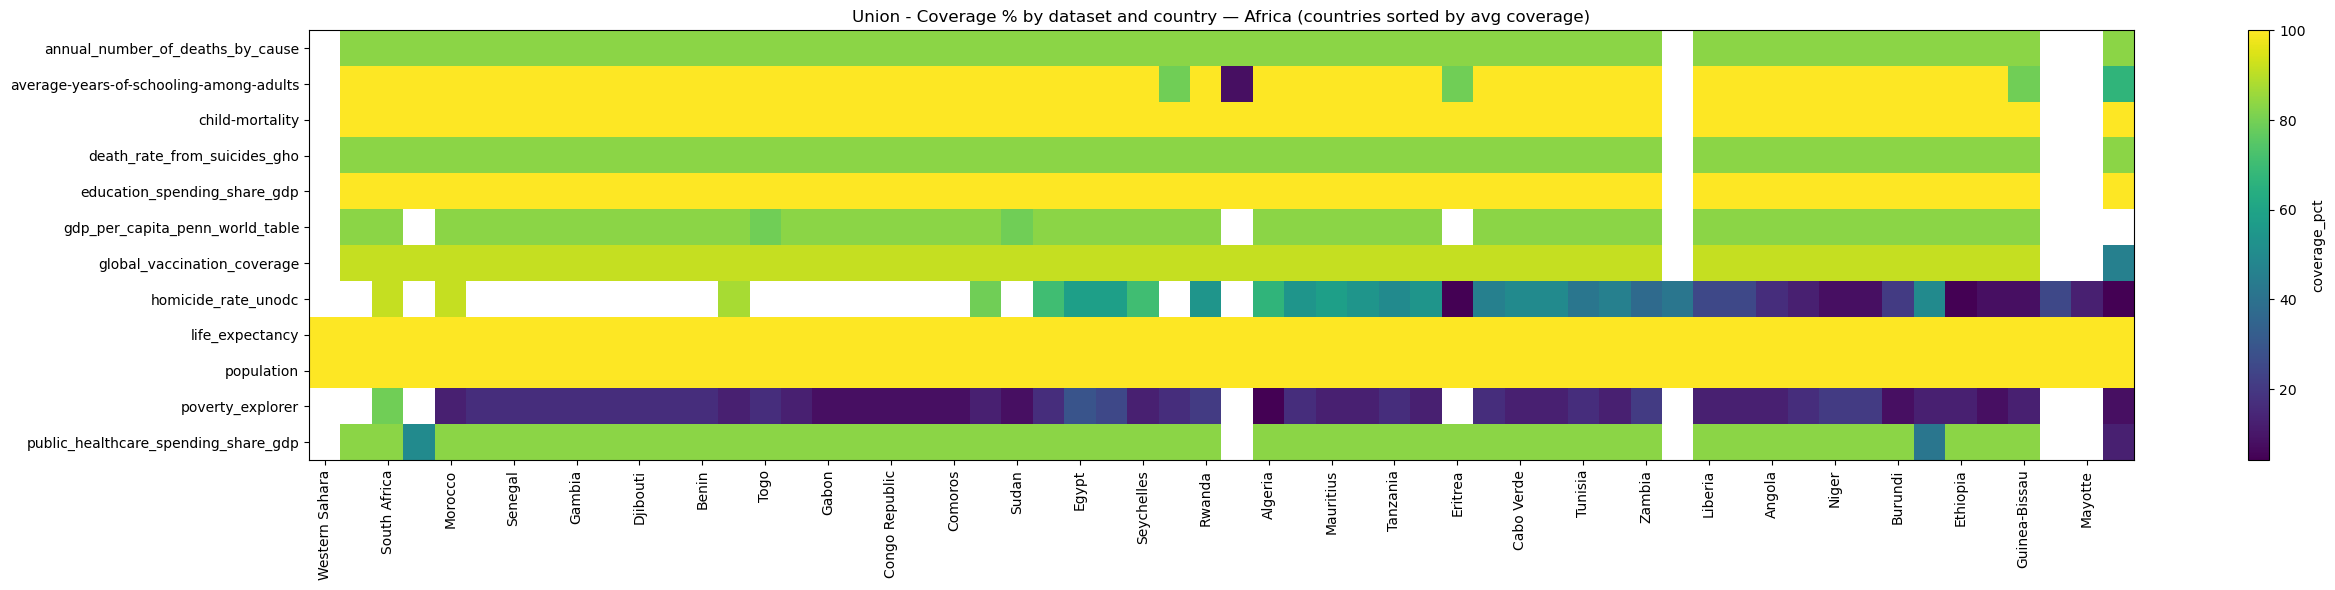

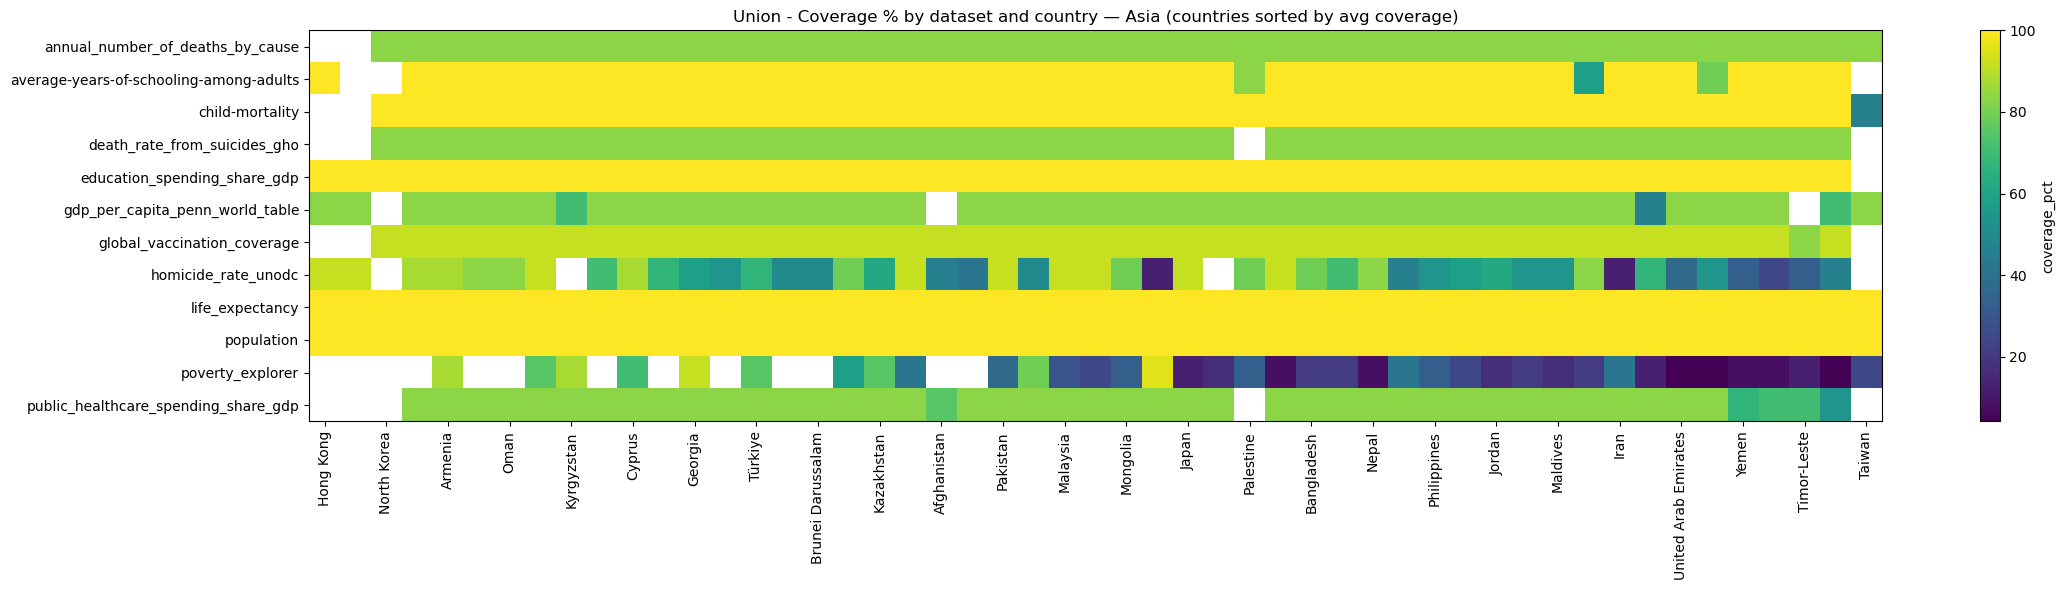

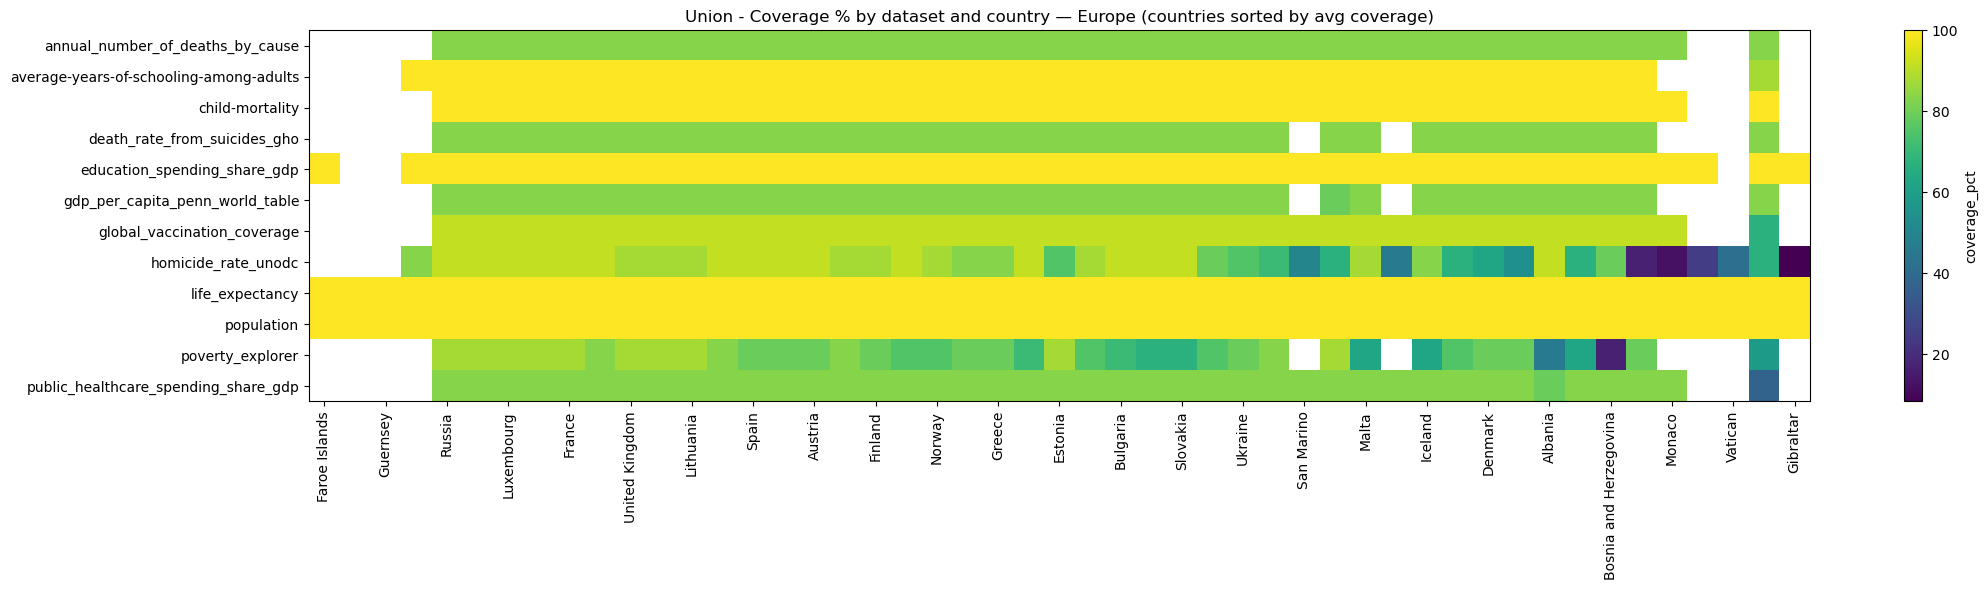

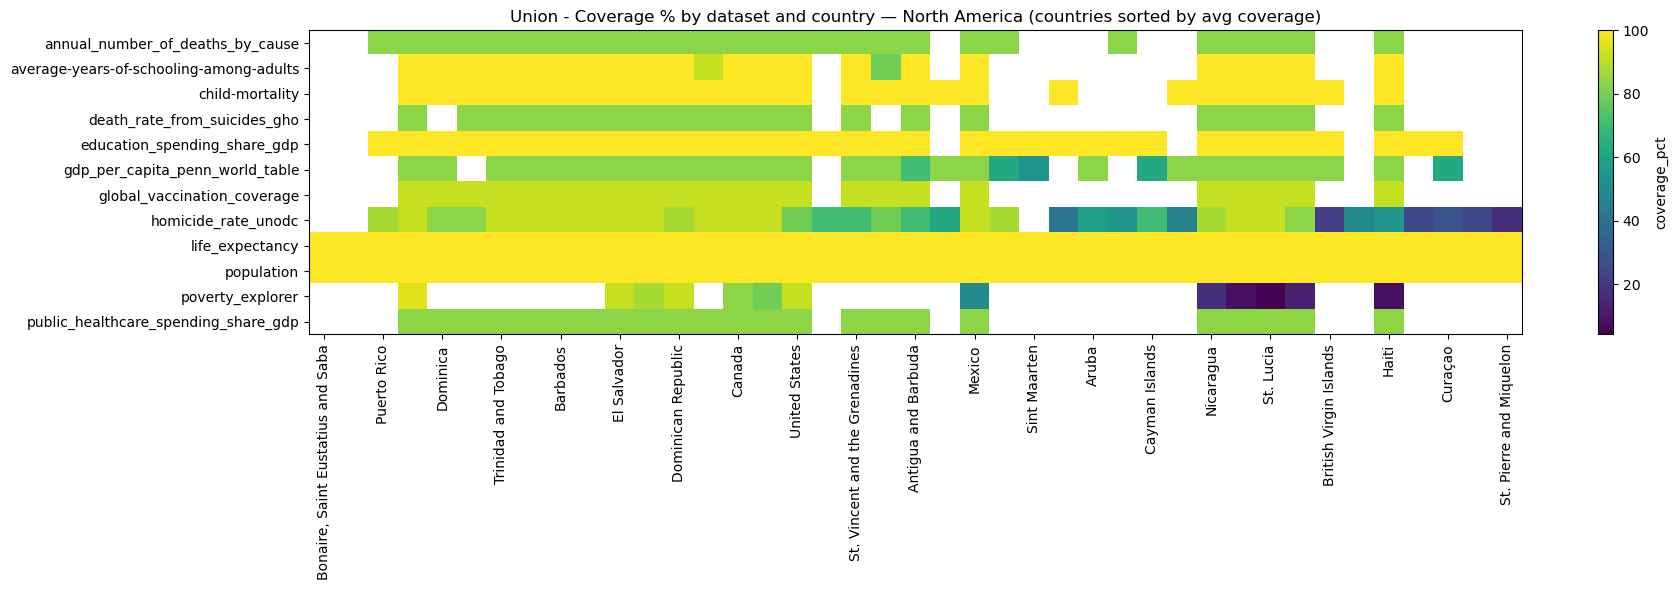

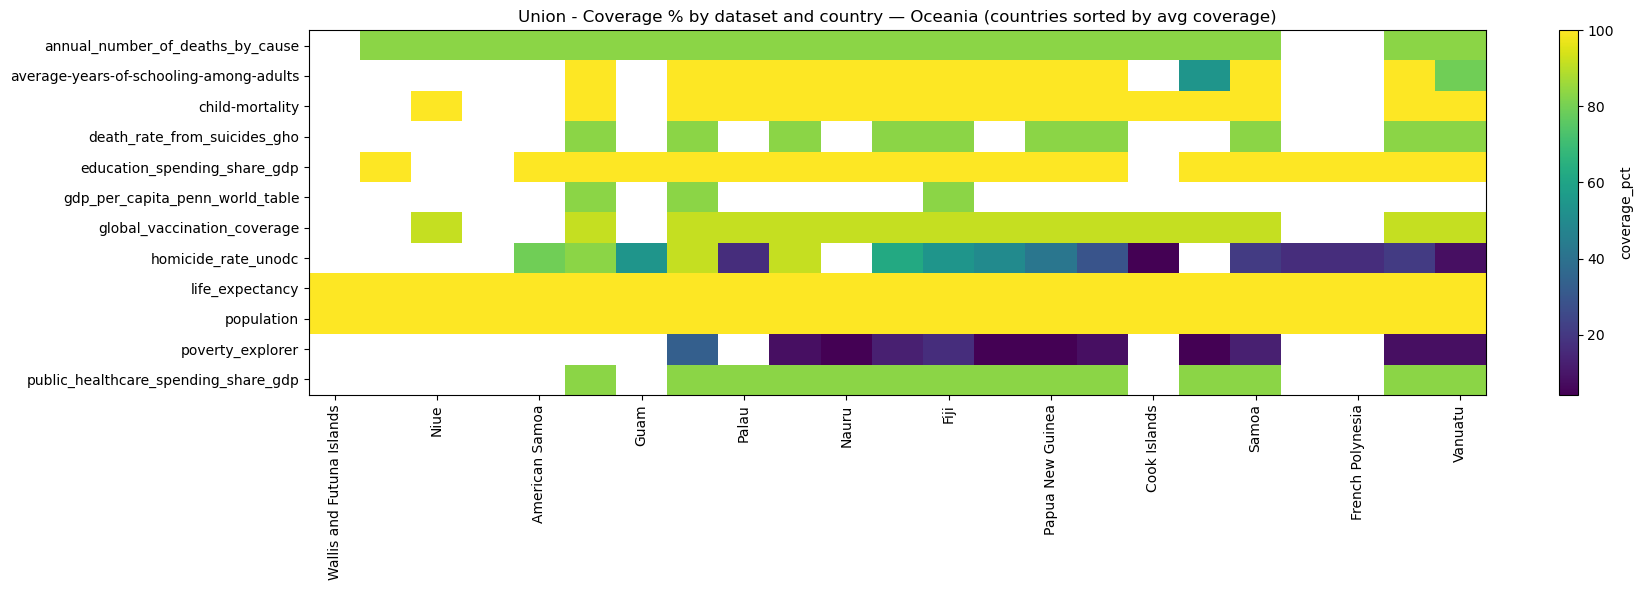

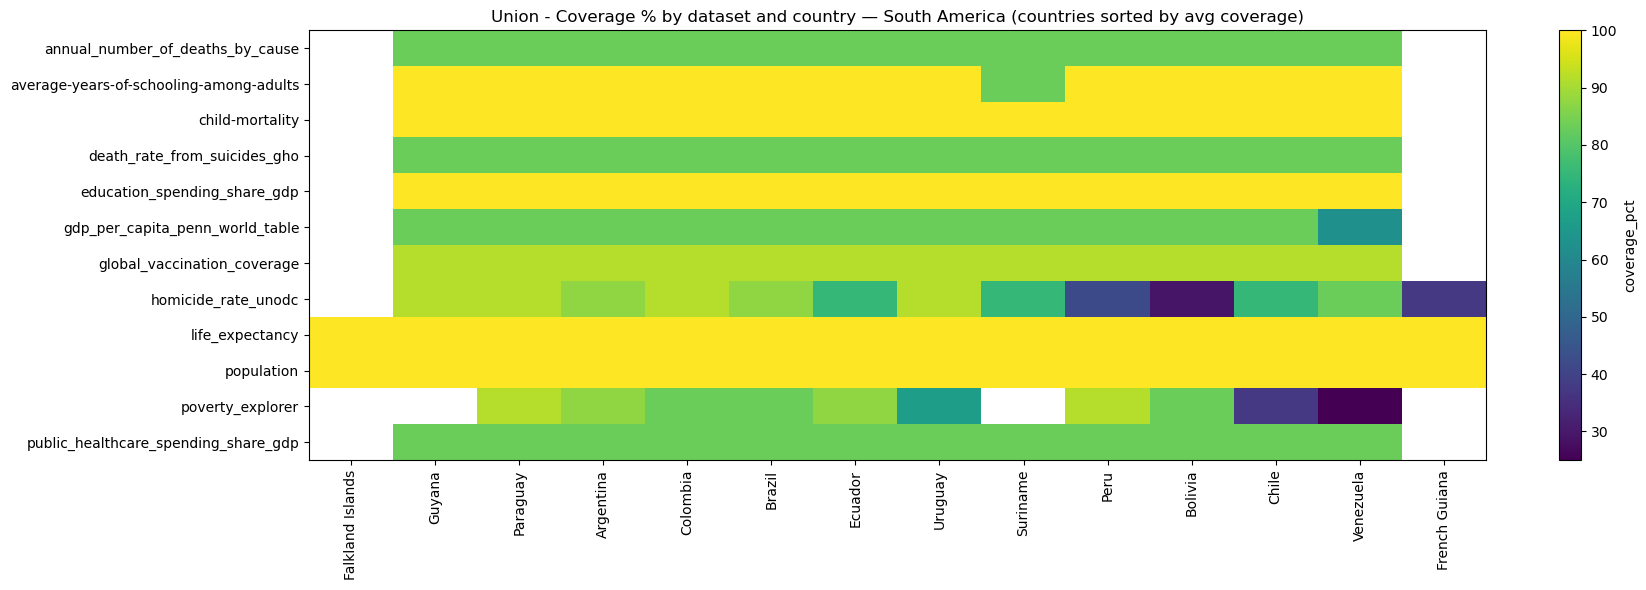

In [27]:
coverage_table_union = fns.get_coverage_table(results_normalized)
range_years = results_normalized['range_years']

for cont, countries in union_by_cont.items():
    width = max(18, len(countries) * 0.45)  
    step = 1 if len(countries) <= 20 else 2
    fns.plot_coverage_heatmap_by_continent_sorted(
        coverage_table_union,
        countries,
        title=f"Union - Coverage % by dataset and country — {cont}",
        figsize=(width, 6),
        x_step=step
    )
    
# Dictionary with the datasets filtered by the union of countries
dict_union = {
    name: df[df["Country"].isin(results_normalized['all_countries_union']) & df["Year"].isin(range_years)]
    for name, df in dict_normalized.items()
}

### ~**Intersection** - Coverage Heatmap per continent by dataset, country and years~

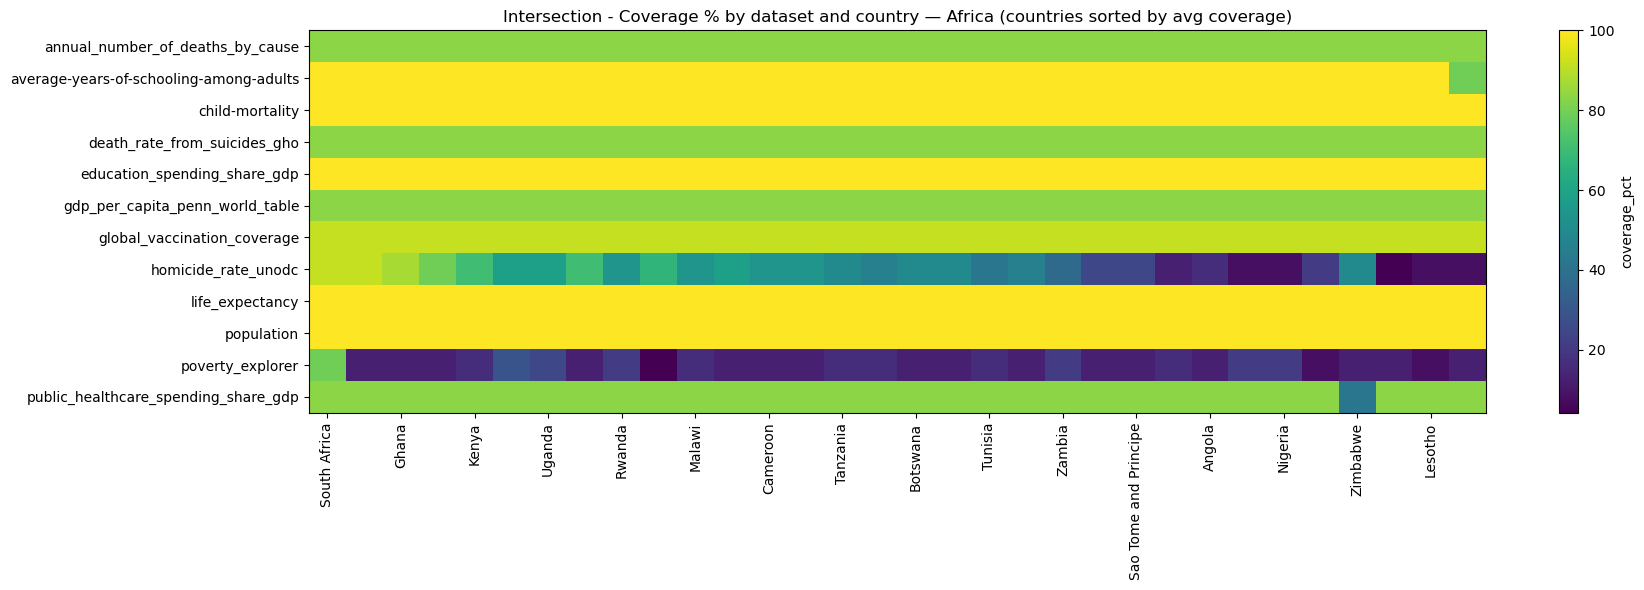

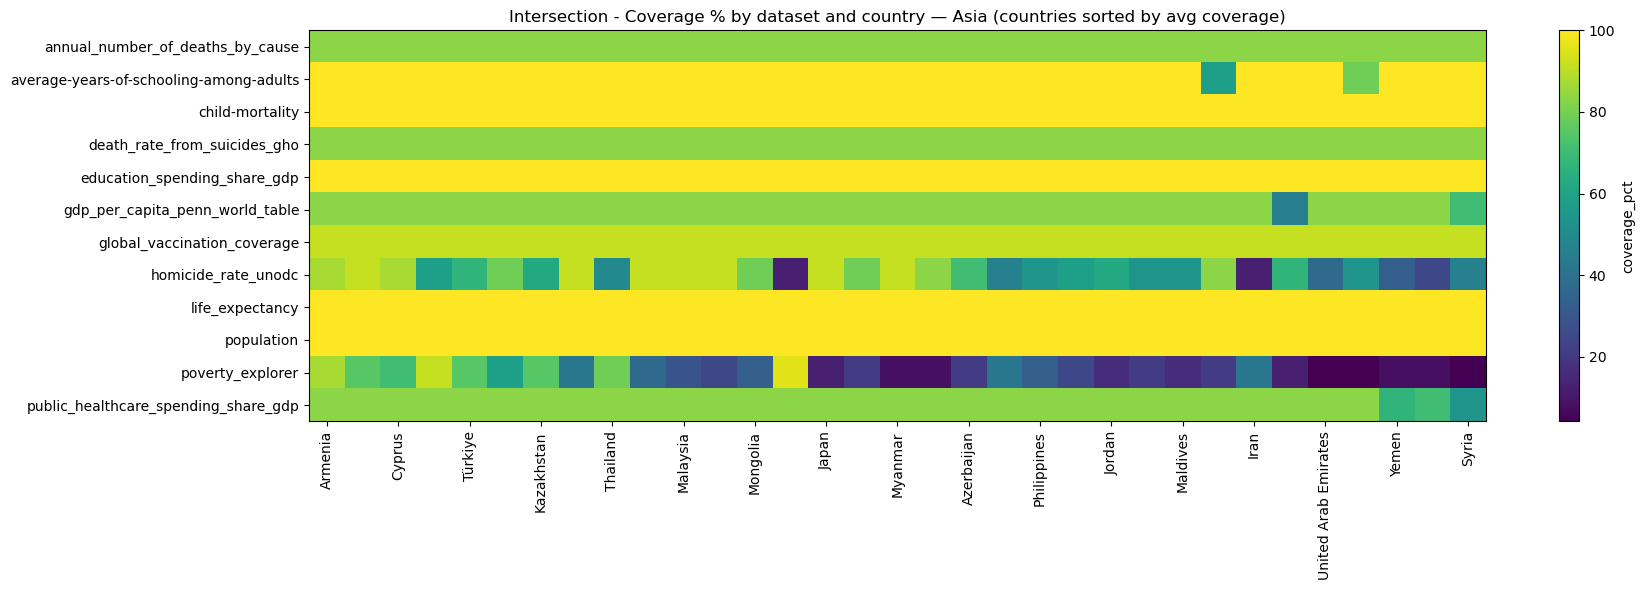

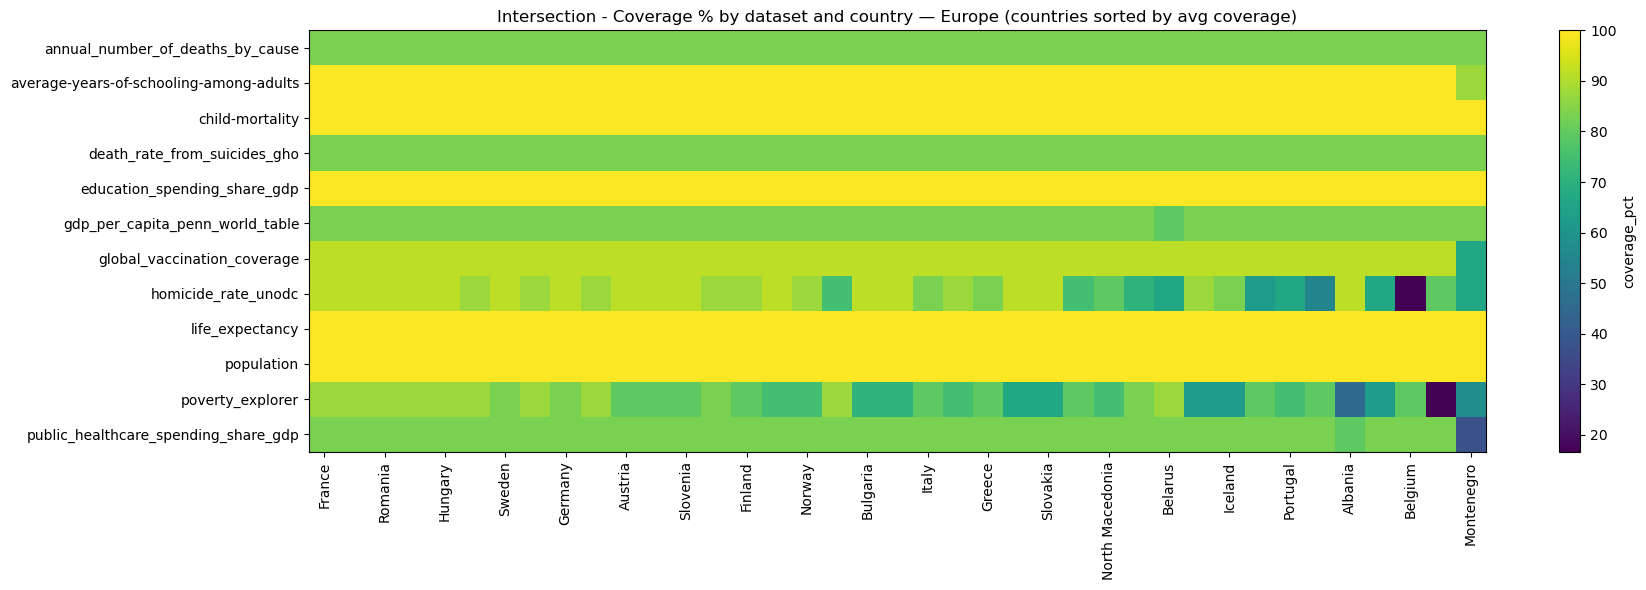

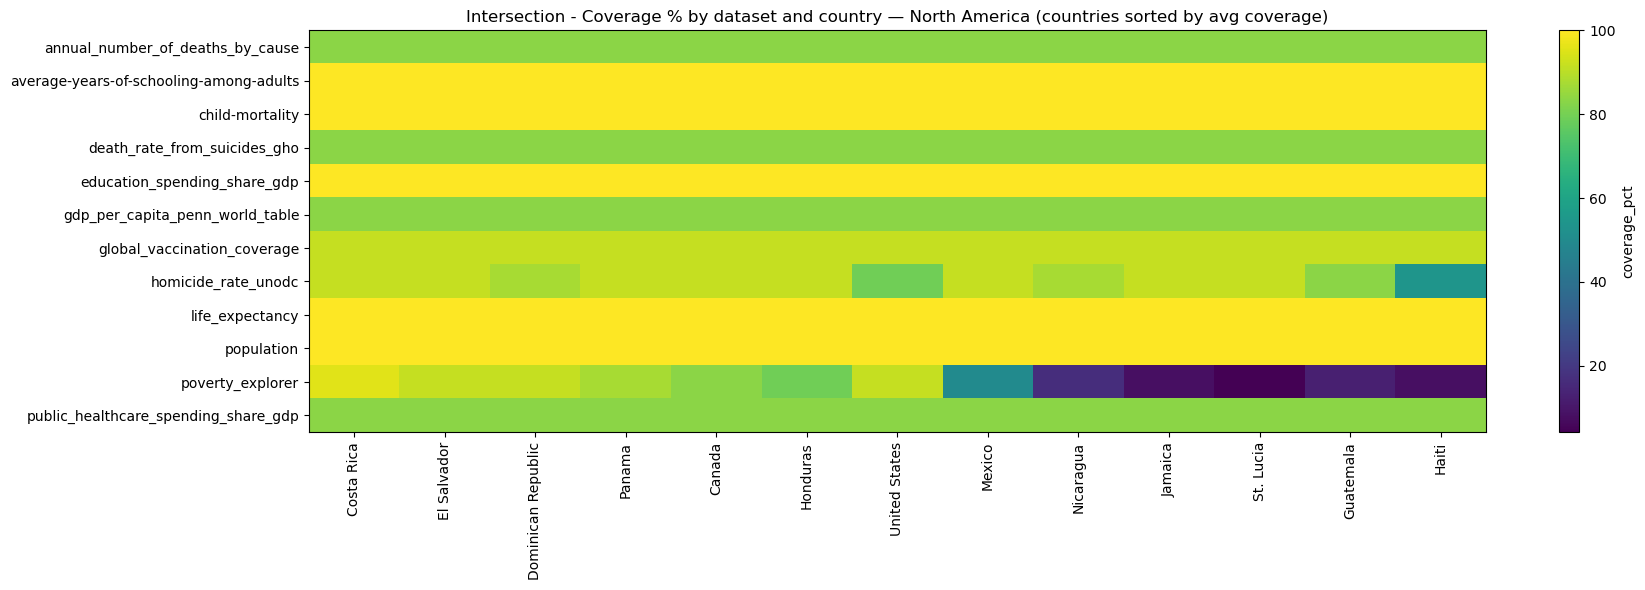

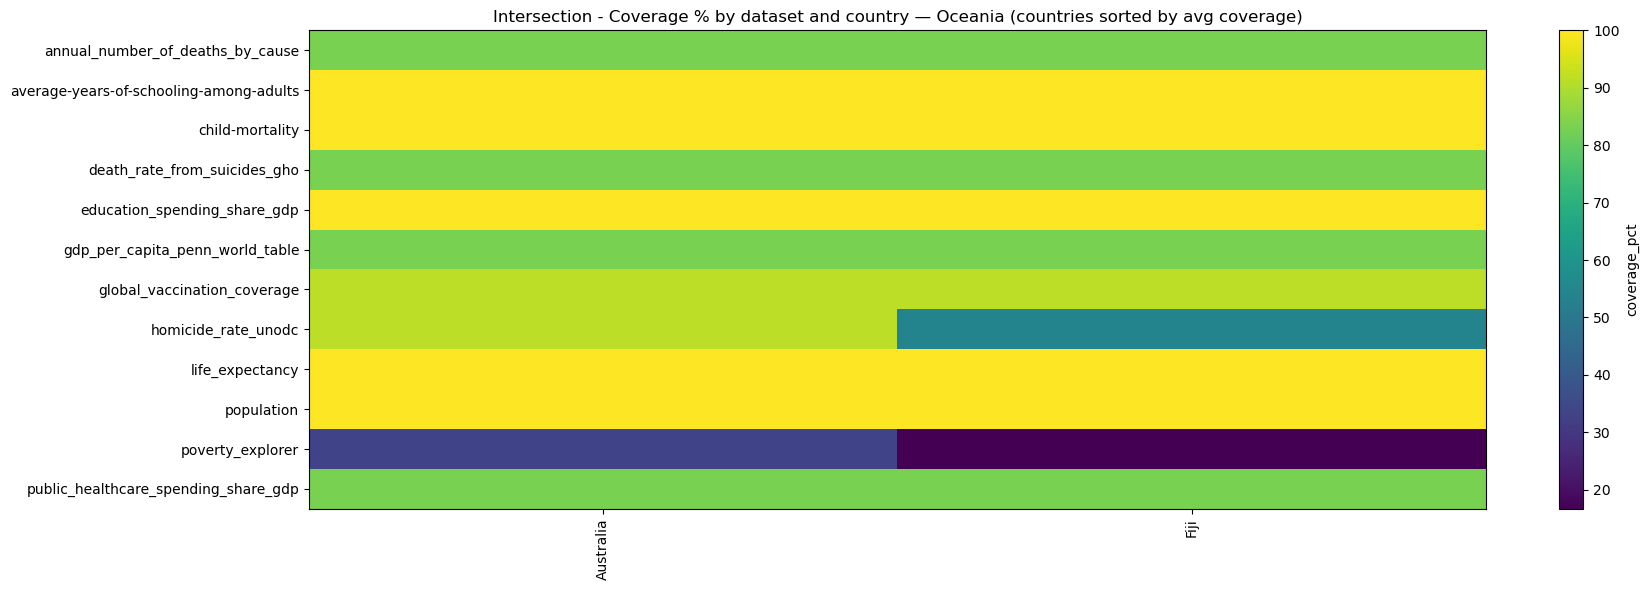

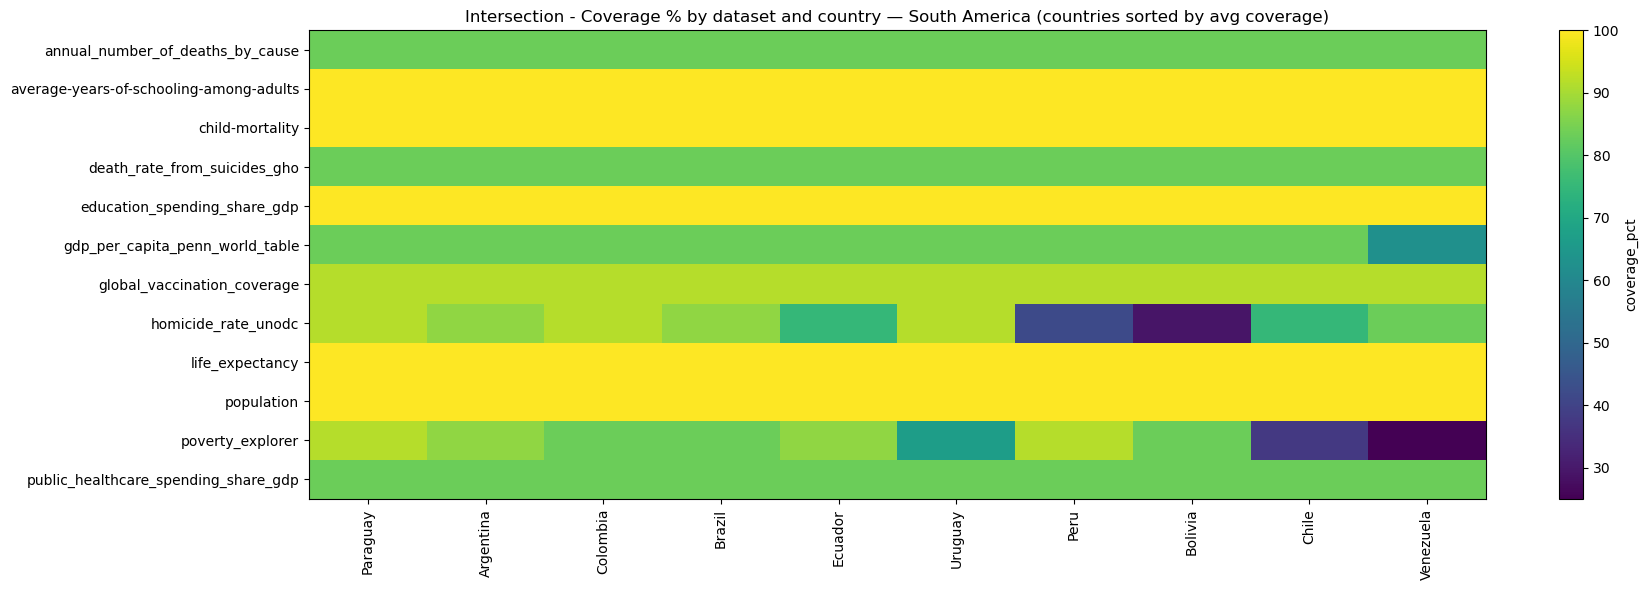

In [28]:
coverage_table_intersec = fns.get_coverage_table(results_normalized)

for cont, countries in inter_by_cont.items():
    width = max(18, len(countries) * 0.45)
    step = 1 if len(countries) <= 20 else 2
    fns.plot_coverage_heatmap_by_continent_sorted(
        coverage_table_intersec,
        countries,
        title=f"Intersection - Coverage % by dataset and country — {cont}",
        figsize=(width, 6),
        x_step=step
    )
    
# Dictionary with the datasets filtered by the intersection of countries
dict_intersec = {
    name: df[df["Country"].isin(results_normalized['all_countries_intersection']) & df["Year"].isin(range_years)]
    for name, df in dict_normalized.items()
}

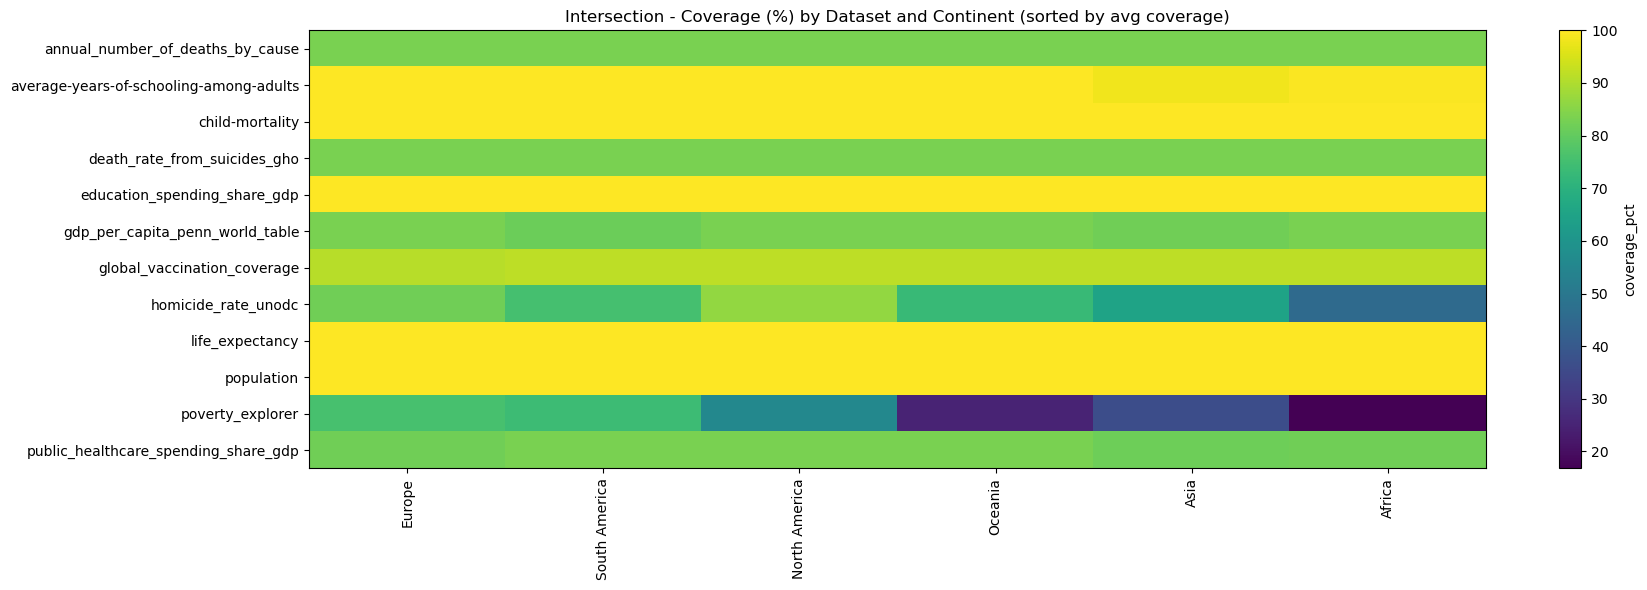

In [67]:
ct = coverage_table_intersec.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')

country_to_continent = {}
for cont, countries in inter_by_cont.items():
    for c in countries:
        country_to_continent[c] = cont

ct['Continent'] = ct.index.map(country_to_continent)
ct = ct.dropna(subset=['Continent'])

continent_coverage = ct.groupby('Continent').mean().round(1)
continent_coverage = continent_coverage.loc[
    continent_coverage.mean(axis=1).sort_values(ascending=False).index
]

# Plot — exact same style as your per-country heatmaps
plt.figure(figsize=(18, 6))
plt.imshow(continent_coverage.values.T, aspect="auto", interpolation="nearest")

plt.yticks(range(len(continent_coverage.columns)), continent_coverage.columns)
plt.xticks(range(len(continent_coverage.index)), continent_coverage.index, rotation=90)

plt.title("Intersection - Coverage (%) by Dataset and Continent (sorted by avg coverage)")
plt.colorbar(label="coverage_pct")
plt.tight_layout()
plt.show()

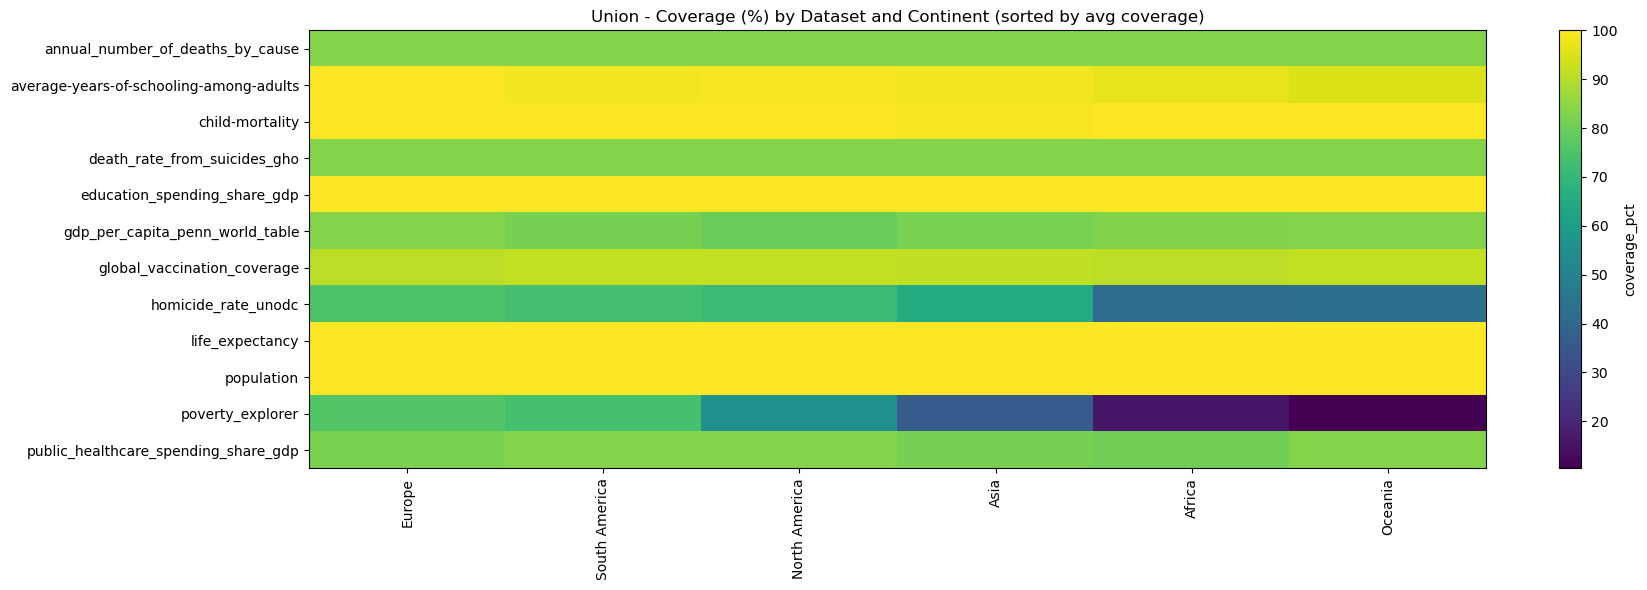

In [68]:
ct = coverage_table_intersec.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')

country_to_continent = {}
for cont, countries in union_by_cont.items():
    for c in countries:
        country_to_continent[c] = cont

ct['Continent'] = ct.index.map(country_to_continent)
ct = ct.dropna(subset=['Continent'])

continent_coverage = ct.groupby('Continent').mean().round(1)
continent_coverage = continent_coverage.loc[
    continent_coverage.mean(axis=1).sort_values(ascending=False).index
]

# Plot — exact same style as your per-country heatmaps
plt.figure(figsize=(18, 6))
plt.imshow(continent_coverage.values.T, aspect="auto", interpolation="nearest")

plt.yticks(range(len(continent_coverage.columns)), continent_coverage.columns)
plt.xticks(range(len(continent_coverage.index)), continent_coverage.index, rotation=90)

plt.title("Union - Coverage (%) by Dataset and Continent (sorted by avg coverage)")
plt.colorbar(label="coverage_pct")
plt.tight_layout()
plt.show()

### ~**Coverage Analysis of Union and Intersection Dictionaries**~

In [30]:
#print("Coverage Analysis for Union datasets:")
#results_union = fns.analyze_coverage(dict_union, year_min, year_max, coverage_threshold=90)

#print("Coverage Analysis for Intersection datasets:")
results_intersec = fns.analyze_coverage(dict_intersec, year_min, year_max, coverage_threshold=90)


Coverage Analysis: 2000-2023 (24 years)
Coverage threshold: 90%

annual_number_of_deaths_by_cause:
  Countries with coverage >= 90%: 0
  Countries with coverage < 90%: 129

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Albania,20,4,83.3,"2020, 2021, 2022, 2023"
Algeria,20,4,83.3,"2020, 2021, 2022, 2023"
Angola,20,4,83.3,"2020, 2021, 2022, 2023"
Argentina,20,4,83.3,"2020, 2021, 2022, 2023"
Armenia,20,4,83.3,"2020, 2021, 2022, 2023"
Australia,20,4,83.3,"2020, 2021, 2022, 2023"
Austria,20,4,83.3,"2020, 2021, 2022, 2023"
Azerbaijan,20,4,83.3,"2020, 2021, 2022, 2023"
Bangladesh,20,4,83.3,"2020, 2021, 2022, 2023"



average-years-of-schooling-among-adults:
  Countries with coverage >= 90%: 125
  Countries with coverage < 90%: 4

  Top 4 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Montenegro,21,3,87.5,"2000, 2001, 2002"
Guinea-Bissau,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Lebanon,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Bhutan,14,10,58.3,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007..."



child-mortality:
  Countries with coverage >= 90%: 129
  Countries with coverage < 90%: 0

death_rate_from_suicides_gho:
  Countries with coverage >= 90%: 0
  Countries with coverage < 90%: 129

  Top 20 countries with lowest coverage:


...

,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Argentina,21,3,87.5,"2000, 2022, 2023"
Armenia,21,3,87.5,"2003, 2022, 2023"
Brazil,21,3,87.5,"2021, 2022, 2023"
Cyprus,21,3,87.5,"2003, 2022, 2023"
Czechia,21,3,87.5,"2018, 2022, 2023"
Dominican Republic,21,3,87.5,"2015, 2022, 2023"
Finland,21,3,87.5,"2021, 2022, 2023"
Ghana,21,3,87.5,"2000, 2022, 2023"
Ireland,21,3,87.5,"2014, 2022, 2023"



life_expectancy:
  Countries with coverage >= 90%: 129
  Countries with coverage < 90%: 0

population:
  Countries with coverage >= 90%: 129
  Countries with coverage < 90%: 0

poverty_explorer:
  Countries with coverage >= 90%: 8
  Countries with coverage < 90%: 121

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Argentina,21,3,87.5,"2015, 2022, 2023"
Armenia,21,3,87.5,"2000, 2022, 2023"
Belarus,21,3,87.5,"2021, 2022, 2023"
Ecuador,21,3,87.5,"2001, 2002, 2023"
Estonia,21,3,87.5,"2021, 2022, 2023"
France,21,3,87.5,"2021, 2022, 2023"
Hungary,21,3,87.5,"2021, 2022, 2023"
Lithuania,21,3,87.5,"2021, 2022, 2023"
Luxembourg,21,3,87.5,"2021, 2022, 2023"



public_healthcare_spending_share_gdp:
  Countries with coverage >= 90%: 0
  Countries with coverage < 90%: 129

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Algeria,20,4,83.3,"2020, 2021, 2022, 2023"
Angola,20,4,83.3,"2020, 2021, 2022, 2023"
Argentina,20,4,83.3,"2020, 2021, 2022, 2023"
Armenia,20,4,83.3,"2020, 2021, 2022, 2023"
Australia,20,4,83.3,"2020, 2021, 2022, 2023"
Austria,20,4,83.3,"2020, 2021, 2022, 2023"
Azerbaijan,20,4,83.3,"2020, 2021, 2022, 2023"
Bangladesh,20,4,83.3,"2020, 2021, 2022, 2023"
Belarus,20,4,83.3,"2020, 2021, 2022, 2023"


**We chose to continue working with the Intersection dataframe as it is more complete and better suite for ML models. We understand that choosing intersection can introduce certain bias in the information, as we are taking countries with stronger statistical infrastructure, which is acknowledged as a limitation and also serves as our first recommendation: invest in data collection for underrepresented nations.**

# **~Aggregated Data~**

In [31]:
dict_data_agg = dict_intersec.copy()

## **~Global Vaccination~**
- Missing: 2020 y 2023 pero podemos obtener esta data directamente el dataset de [World Population Review](https://worldpopulationreview.com/country-rankings/suicide-rate-by-country)

In [32]:
def merge_vaccination_files(directory, output_file='global_vaccination_coverage.csv'):
    """
    Merge all vaccination Excel files into one dataset.
    Aggregates data by Country and Year (taking the mean).
    
    Parameters:
    -----------
    directory : str
        Path to folder with Excel files
    output_file : str
        Name of output CSV file (default: 'global_vaccination_coverage.csv')
    
    Returns:
    --------
    pd.DataFrame
        Merged vaccination dataset
    """
    
    # Find all Excel files
    files = list(Path(directory).glob("*_coverage_*.xlsx"))
    
    if not files:
        raise ValueError(f"No files found in {directory}")
    
    print(f"Found {len(files)} files")
    
    # Process each file
    dfs = []
    
    for filepath in sorted(files):
        # Read file
        df = pd.read_excel(filepath)
        
        # Extract vaccine name from filename
        vaccine_name = filepath.stem.split('_coverage')[0]
        
        # Find the "Mean" column
        mean_col = [col for col in df.columns if 'Mean' in str(col)][0]
        
        # Keep only Year, Country, and Mean column
        df_clean = df[['Year', 'Country', mean_col]].copy()
        
        # Rename Mean column to vaccine name
        df_clean = df_clean.rename(columns={mean_col: vaccine_name})
        
        # Aggregate by Country and Year (calculate mean)
        df_agg = df_clean.groupby(['Country', 'Year'], as_index=False)[vaccine_name].mean()
        
        dfs.append(df_agg)
        print(f"  ✓ {vaccine_name}: {len(df_clean)} rows → {len(df_agg)} rows (aggregated)")
    
    # Merge all dataframes
    df_merged = dfs[0]
    for df in dfs[1:]:
        df_merged = df_merged.merge(df, on=['Country', 'Year'], how='outer')
    
    # Sort
    df_merged = df_merged.sort_values(['Country', 'Year']).reset_index(drop=True)
    
    # Save to CSV
    #df_merged.to_csv(output_file, index=False)
    
    print(f"\n✅ CSV created: {output_file}")
    print(f"   Shape: {df_merged.shape}")
    print(f"   Years: {df_merged['Year'].min()}-{df_merged['Year'].max()}")
    print(f"   Countries: {df_merged['Country'].nunique()}")
    
    return df_merged

In [33]:
def normalize_vaccination_columns(df):
    
    df_normalized = df.copy()
    rename_dict = {}
    cols_to_drop = []
    
    for col in df_normalized.columns:
        col_lower = col.lower().strip()
        
        # Columnas básicas
        if col_lower == 'country':
            rename_dict[col] = 'Country'
        elif col_lower == 'code':
            cols_to_drop.append(col)       
        elif col_lower == 'year':
            rename_dict[col] = 'Year'
        elif col_lower == 'entity':
            rename_dict[col] = 'Country'     
        
        # Formato 1: 'BCG (% of one-year-olds immunized)'
        elif '(% of one-year-olds immunized)' in col:
            vaccine_code = col.split('(')[0].strip()
            rename_dict[col] = vaccine_code
        
        # Formato 2: 'coverage__antigen_hepb3'
        elif 'coverage__antigen_' in col_lower:
            vaccine_code = col_lower.replace('coverage__antigen_', '').upper()
            
            vaccine_mapping = {
                'HEPB3': 'HepB3',
                'HIB3': 'Hib3',
                'IPV1': 'IPV1',
                'MCV1': 'MCV1',
                'PCV3': 'PCV3',
                'POL3': 'Pol3',
                'Polio3': 'Pol3',
                'RCV1': 'RCV1',
                'ROTAC': 'RotaC',
                'DTPCV3': 'DTP3',
                'YFV': 'YFV',
                'BCG': 'BCG'
            }
            
            rename_dict[col] = vaccine_mapping.get(vaccine_code, vaccine_code)
    
    df_normalized = df_normalized.drop(columns=cols_to_drop, errors='ignore')
    df_normalized = df_normalized.rename(columns=rename_dict)
    
    return df_normalized

#############################################################################################


In [34]:
UNICEF_FOLDER = 'data_agg/global_vaccination_coverage'

# Antigen name mapping — WHO codes → pipeline names
ANTIGEN_MAP = {
    'BCG':   'BCG',
    'DTP1':  'DTP1',
    'DTP3':  'DTP3',
    'HEPB3': 'HepB3',
    'HIB3':  'Hib3',
    'MCV1':  'MCV1',
    'MCV2':  'MCV2',
    'PCV3':  'PCV3',
    'POL3':  'Pol3',
    'RCV1':  'RCV1',
    'ROTAC': 'RotaC',
}

CATEGORY_PRIORITY = {'WUENIC': 1, 'OFFICIAL': 2, 'ADMIN': 3}

def load_unicef_excel_files(folder_path):
    """
    Load all UNICEF Excel files from folder, apply WUENIC > OFFICIAL > ADMIN
    priority, and return wide-format DataFrame (Country, Year, vaccine cols).
    """
    files = [f for f in os.listdir(folder_path) 
             if f.endswith('.xlsx') or f.endswith('.csv')]
    print(f"Found {len(files)} files in {folder_path}")
    
    all_frames = []
    for fname in files:
        fpath = os.path.join(folder_path, fname)
        try:
            df = pd.read_excel(fpath, sheet_name='Sheet1')
            df.columns = df.columns.str.upper().str.strip()
            
            required = {'NAME', 'CODE', 'YEAR', 'ANTIGEN', 
                       'COVERAGE_CATEGORY', 'COVERAGE'}
            if not required.issubset(df.columns):
                print(f"  ⚠️  {fname}: missing {required - set(df.columns)}")
                continue
            
            all_frames.append(df[list(required)])
            print(f"  ✅ {fname}: {len(df)} rows | "
                  f"antigens: {df['ANTIGEN'].dropna().unique()}")
        except Exception as e:
            print(f"  ❌ {fname}: {e}")
    
    df_all = pd.concat(all_frames, ignore_index=True)
    
    # Filter years and countries only (3-letter ISO codes)
    df_all = df_all[
        df_all['YEAR'].between(year_min, year_max) &
        (df_all['CODE'].str.len() == 3)
    ]
    
    # Keep only mapped antigens, drop None mappings (IPV1, IPV2, YFV)
    df_all = df_all[df_all['ANTIGEN'].isin(ANTIGEN_MAP.keys())]
    df_all = df_all[df_all['ANTIGEN'].map(ANTIGEN_MAP).notna()]
    df_all['ANTIGEN'] = df_all['ANTIGEN'].map(ANTIGEN_MAP)
    
    # Apply priority — keep best category per country/year/antigen
    df_all['Priority'] = df_all['COVERAGE_CATEGORY'].map(
        CATEGORY_PRIORITY).fillna(99)
    df_all = (
        df_all
        .sort_values('Priority')
        .drop_duplicates(subset=['CODE', 'NAME', 'YEAR', 'ANTIGEN'], keep='first')
        .drop(columns=['Priority', 'COVERAGE_CATEGORY', 'CODE'])
    )
    
    # Pivot to wide format
    df_wide = df_all.pivot_table(
        index=['NAME', 'YEAR'],
        columns='ANTIGEN',
        values='COVERAGE',
        aggfunc='first'
    ).reset_index()
    
    df_wide.columns.name = None
    df_wide = df_wide.rename(columns={'NAME': 'Country', 'YEAR': 'Year'})
    df_wide['Year'] = df_wide['Year'].astype(int)
    df_wide = df_wide.sort_values(['Country', 'Year']).reset_index(drop=True)
    
    print(f"\n✅ UNICEF files loaded: {df_wide.shape}")
    print(f"   Countries: {df_wide['Country'].nunique()}")
    print(f"   Vaccines: {[c for c in df_wide.columns if c not in ['Country','Year']]}")
    return df_wide


# Load the new UNICEF files — this replaces df_vaccination_owid
df_vaccination_owid = load_unicef_excel_files(UNICEF_FOLDER)

# Load local WHO Excel files (existing pipeline)
df_vaccination_local = merge_vaccination_files('data_who/global vaccination/')

# Normalize existing dict dataset
dict_data_agg['global_vaccination_coverage'] = normalize_vaccination_columns(
    dict_data_agg['global_vaccination_coverage']
)
df_vaccination_existing = dict_data_agg['global_vaccination_coverage'].copy()

print("Dataset Summary:")
print(f"  Local (existing WHO):  {df_vaccination_local.shape}")
print(f"  UNICEF (new):          {df_vaccination_owid.shape}")
print(f"  Existing (old dict):   {df_vaccination_existing.shape}")

Found 9 files in data_agg/global_vaccination_coverage
  ✅ UNICEF BCG.xlsx: 13968 rows | antigens: ['BCG']
  ✅ UNICEF DTP 1_3.xlsx: 29740 rows | antigens: ['DTPCV3' 'DTPCV1']
  ✅ UNICEF HepB3.xlsx: 14235 rows | antigens: ['HEPB3']
  ✅ UNICEF Hib3.xlsx: 14840 rows | antigens: ['HIB3']
  ✅ UNICEF MCV1_2.xlsx: 29693 rows | antigens: ['MCV2' 'MCV1']
  ✅ UNICEF PCV3.xlsx: 10141 rows | antigens: ['PCV3']
  ✅ UNICEF Pol3.xlsx: 14903 rows | antigens: ['POL3']
  ✅ UNICEF RCV1.xlsx: 13054 rows | antigens: ['RCV1']
  ✅ UNICEF RotaC.xlsx: 10468 rows | antigens: ['ROTAC']

✅ UNICEF files loaded: (4861, 11)
   Countries: 214
   Vaccines: ['BCG', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'RCV1', 'RotaC']
Found 9 files
  ✓ BCG: 46775 rows → 2475 rows (aggregated)
  ✓ DTP1: 47400 rows → 2525 rows (aggregated)
  ✓ HepB3: 47400 rows → 2525 rows (aggregated)
  ✓ Hib3: 47400 rows → 2525 rows (aggregated)
  ✓ MCV1: 47400 rows → 2525 rows (aggregated)
  ✓ MCV2: 46500 rows → 2450 rows (aggregated)
  ✓ P

In [ ]:
# Normalize country names for all three datasets
# ============================================================================
df_vaccination_local = fns.normalize_country_names(df_vaccination_local)
df_vaccination_owid = fns.normalize_country_names(df_vaccination_owid)
df_vaccination_existing = fns.normalize_country_names(df_vaccination_existing)

# Filter all three by selected countries and years
# ============================================================================
selected_countries = dict_intersec["life_expectancy"]["Country"].unique().tolist()

df_vaccination_local = fns.filter_by_countries(df_vaccination_local, selected_countries)
df_vaccination_local = fns.filter_by_years(df_vaccination_local, year_min, year_max)

df_vaccination_owid = fns.filter_by_countries(df_vaccination_owid, selected_countries)
df_vaccination_owid = fns.filter_by_years(df_vaccination_owid, year_min, year_max)

df_vaccination_existing = fns.filter_by_countries(df_vaccination_existing, selected_countries)
df_vaccination_existing = fns.filter_by_years(df_vaccination_existing, year_min, year_max)

# Get ALL vaccines from all datasets 
# ============================================================================
local_vaccines = set(df_vaccination_local.columns) - {'Country', 'Year'}
owid_vaccines = set(df_vaccination_owid.columns) - {'Country', 'Year'}
existing_vaccines = set(df_vaccination_existing.columns) - {'Country', 'Year'}

# Union of all vaccines
all_vaccines = sorted(local_vaccines | owid_vaccines | existing_vaccines)
print(f"\nAll vaccines (union): {all_vaccines}")
print(f"  From local:    {sorted(local_vaccines)}")
print(f"  From OWID:     {sorted(owid_vaccines)}")
print(f"  From existing: {sorted(existing_vaccines)}")

# Merge all three datasets (outer joins to keep all data)
df_final = df_vaccination_local.copy()

# ── VACCINE ALIASES: collapse duplicate columns ───────────────────────────────
# Polio3 (local WHO) == Pol3 (OWID/existing) → keep as Pol3
# Add more aliases here if needed

VACCINE_ALIASES = {
    'Polio3': 'Pol3',   # same vaccine, different source naming
    # 'DTP1': 'DTP3',   # NOT the same — DTP1 is 1st dose, DTP3 is 3rd dose, keep separate
}

def apply_vaccine_aliases(df, aliases):
    for old_name, new_name in aliases.items():
        if old_name in df.columns:
            if new_name in df.columns:
                # Both exist — fill new_name gaps with old_name, then drop old
                df[new_name] = df[new_name].fillna(df[old_name])
                df = df.drop(columns=[old_name])
            else:
                # Only old exists — just rename
                df = df.rename(columns={old_name: new_name})
    return df

# Apply aliases to each source BEFORE merging
df_vaccination_local   = apply_vaccine_aliases(df_vaccination_local, VACCINE_ALIASES)
df_vaccination_owid    = apply_vaccine_aliases(df_vaccination_owid, VACCINE_ALIASES)
df_vaccination_existing = apply_vaccine_aliases(df_vaccination_existing, VACCINE_ALIASES)

# Also drop columns you've decided to exclude entirely
DROP_VACCINES = ['IPV1', 'YFV']  # too sparse (<35% and <12% coverage)
for df in [df_vaccination_local, df_vaccination_owid, df_vaccination_existing]:
    cols_to_drop = [c for c in DROP_VACCINES if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

# Now recompute all_vaccines union
local_vaccines    = set(df_vaccination_local.columns) - {'Country', 'Year'}
owid_vaccines     = set(df_vaccination_owid.columns) - {'Country', 'Year'}
existing_vaccines = set(df_vaccination_existing.columns) - {'Country', 'Year'}
all_vaccines = sorted(local_vaccines | owid_vaccines | existing_vaccines)
print(f"Vaccines after deduplication: {all_vaccines}")
# Expected: ['BCG', 'DTP1', 'DTP3', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'RCV1', 'RotaC']

# Merge with existing (outer join)
df_final = df_final.merge(
    df_vaccination_existing,
    on=['Country', 'Year'],
    how='outer',
    suffixes=('', '_existing')
)

# Merge with OWID (outer join)
df_final = df_final.merge(
    df_vaccination_owid,
    on=['Country', 'Year'],
    how='outer',
    suffixes=('', '_owid')
)

# Combine columns with priority (Local > Existing > OWID)
# ============================================================================
for vaccine in all_vaccines:
    # Column names from different sources
    col_local = vaccine
    col_existing = f"{vaccine}_existing"
    col_owid = f"{vaccine}_owid"
    
    # If vaccine column doesn't exist in final, create it
    if col_local not in df_final.columns:
        df_final[col_local] = None
    
    # Fill with priority: local > existing > owid
    if col_existing in df_final.columns:
        df_final[col_local] = df_final[col_local].fillna(df_final[col_existing])
        df_final = df_final.drop(columns=[col_existing])
    
    if col_owid in df_final.columns:
        df_final[col_local] = df_final[col_local].fillna(df_final[col_owid])
        df_final = df_final.drop(columns=[col_owid])

# Keep only Country, Year, and vaccine columns
cols_to_keep = ['Country', 'Year'] + all_vaccines
df_vaccination_final = df_final[cols_to_keep].copy()

# Sort
df_vaccination_final = df_vaccination_final.sort_values(['Country', 'Year']).reset_index(drop=True)

# Summary and save
# ============================================================================
print(f"\n{'='*80}")
print("FINAL VACCINATION DATASET")
print(f"{'='*80}")
print(f"Final shape: {df_vaccination_final.shape}")
print(f"Countries: {df_vaccination_final['Country'].nunique()}")
print(f"Years: {df_vaccination_final['Year'].min()} - {df_vaccination_final['Year'].max()}")
print(f"Total vaccines: {len(all_vaccines)}")
print(f"Vaccines: {all_vaccines}")
print(f"{'='*80}")

# Check coverage per vaccine
print("\nCoverage per vaccine:")
for vaccine in all_vaccines:
    non_null = df_vaccination_final[vaccine].notna().sum()
    total = len(df_vaccination_final)
    pct = (non_null / total * 100)
    print(f"  {vaccine:10s}: {non_null:5d}/{total:5d} ({pct:5.1f}%)")

# Save final dataset
#df_vaccination_final.to_csv('global_vaccination_coverage_final.csv', index=False)

# Update dictionary
dict_data_agg['global_vaccination_coverage'] = df_vaccination_final

# Show sample
display(df_vaccination_final.sample(10))

  Initial: (2625, 11) → Filtered: (1725, 11)
DataFrame filtered by years (2000 to 2023):
  Initial: (1725, 11) → Filtered: (1656, 11)
  Initial: (4861, 11) → Filtered: (3090, 11)
DataFrame filtered by years (2000 to 2023):
  Initial: (3090, 11) → Filtered: (3090, 11)
  Initial: (2832, 13) → Filtered: (2832, 13)
DataFrame filtered by years (2000 to 2023):
  Initial: (2832, 13) → Filtered: (2832, 13)

All vaccines (union): ['BCG', 'DTP1', 'DTP3', 'HepB3', 'Hib3', 'IPV1', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'Polio3', 'RCV1', 'RotaC', 'YFV']
  From local:    ['BCG', 'DTP1', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Polio3', 'RotaC']
  From OWID:     ['BCG', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'RCV1', 'RotaC']
  From existing: ['BCG', 'DTP3', 'HepB3', 'Hib3', 'IPV1', 'MCV1', 'PCV3', 'Pol3', 'RCV1', 'RotaC', 'YFV']
Vaccines after deduplication: ['BCG', 'DTP1', 'DTP3', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'RCV1', 'RotaC']

FINAL VACCINATION DATASET
Final shape: (3114, 13)

,Country,Year,BCG,DTP1,DTP3,HepB3,Hib3,MCV1,MCV2,PCV3,Pol3,RCV1,RotaC
114,Armenia,2018,0.987091,0.982636,92.0,0.919455,0.920000,0.934455,0.934182,0.927091,92.0,95.0,0.927909
122,Australia,2002,NaN,NaN,92.0,95.000000,95.000000,94.000000,NaN,NaN,92.0,94.0,NaN
1826,Montenegro,2008,98.000000,NaN,95.0,93.000000,93.000000,89.000000,96.000000,NaN,95.0,89.0,NaN
33,Algeria,2009,0.984000,0.974646,95.0,0.932667,0.935167,0.935479,0.933208,0.000000,94.0,NaN,NaN
992,Ghana,2008,0.963500,0.968100,93.0,0.869400,0.869400,0.940900,0.000000,0.000000,92.0,NaN,0.000000
2891,United Arab Emirates,2017,95.000000,NaN,97.0,98.000000,98.000000,99.000000,97.000000,96.000000,96.0,99.0,90.000000
1432,Kazakhstan,2016,95.000000,NaN,82.0,82.000000,82.000000,99.000000,99.000000,97.000000,82.0,99.0,NaN
1632,Malaysia,2000,0.930312,0.995313,98.0,0.938500,0.000000,0.846500,0.000000,0.000000,98.0,96.0,NaN
2053,Nigeria,2019,0.723108,0.699865,56.0,0.581189,0.581216,0.636811,0.107243,0.578081,54.0,NaN,0.000000
1330,Italy,2010,NaN,NaN,96.0,96.000000,95.000000,91.000000,NaN,71.000000,96.0,91.0,NaN


## **~GDP Per Capita~**
- Missings: 2020 y 2023
- Obtain missing data from [World Bank Data](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD)

In [36]:
path_gdp = "data_agg/gdp_per_capita"
lista = os.listdir(path_gdp)

files = sorted([f for f in lista if f.endswith(".csv")])

print("Files founded:", len(files))
for f in files:
    print(" -", f)   

dfs = []
cols = ["Country Name","2015","2016","2017","2018","2019","2020","2021","2022","2023"]

for f in files:
    fullpath = os.path.join(path_gdp, f)
    df = pd.read_csv(fullpath, skiprows=4)
    df.columns = df.columns.str.strip()

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"On {f} there are missing columns: {missing}. Available columns: {list(df.columns)}")

    dfs.append(df[cols])

df_gdp_agg = pd.concat(dfs, ignore_index=True)

print("Shape final:", df_gdp_agg.shape)

# Intial cleaning
df_gdp_agg = fns.initial_cleaning(df_gdp_agg)

df_gdp_agg.sample(5)

#Convertir de wide a long con pd.melt()
df_gdp_agg_long = pd.melt(
    df_gdp_agg,
    id_vars=['Country'],  # Columna que se mantiene
    value_vars=[col for col in df_gdp_agg.columns if col != 'Country'],  # Columnas a convertir
    var_name='Year',
    value_name='GDP per Capita'
)

df_gdp_agg_long['Year'] = df_gdp_agg_long['Year'].astype(int)

#**Normalization and filter by countries and years**
df_gdp_agg_normalized= fns.normalize_country_names(df_gdp_agg_long)

df_gdp_agg = fns.filter_by_countries(df_gdp_agg_normalized, selected_countries)

df_gdp_agg = fns.filter_by_years(df_gdp_agg, year_min, year_max)

df_copy_gdp = dict_data_agg['gdp_per_capita_penn_world_table'].copy()
df_copy_gdp = df_copy_gdp.rename(columns={
    'GDP per capita (output, multiple price benchmarks)': 'GDP per Capita'
})

# ── Fix: use PWT as base, fill missing years with World Bank ─────────────────
# PWT covers up to ~2019, World Bank fills 2020-2023 gaps
# Concatenate then keep first occurrence per Country/Year (PWT has priority)

combined_gdp = pd.concat(
    [df_copy_gdp, df_gdp_agg],   # ← PWT first = higher priority
    ignore_index=True,
    sort=False
)

# Deduplicate — keep first (PWT) for overlapping years
combined_gdp = (
    combined_gdp
    .sort_values(['Country', 'Year'])
    .drop_duplicates(subset=['Country', 'Year'], keep='first')
    .reset_index(drop=True)
)

print(f"Combined shape after dedup: {combined_gdp.shape}")

# Verify no more duplicates
dupes = combined_gdp.groupby(['Country', 'Year']).size()
dupes = dupes[dupes > 1]
print(f"Remaining duplicates: {len(dupes)}")

dict_data_agg['gdp_per_capita_penn_world_table'] = combined_gdp.copy()

Files founded: 1
 - gdp_per_capita_2024.csv
Shape final: (266, 10)
'df' no tiene 'Year' ni 'year'.
  Initial: (2394, 3) → Filtered: (1161, 3)
DataFrame filtered by years (2000 to 2023):
  Initial: (1161, 3) → Filtered: (1161, 3)
Combined shape after dedup: (3089, 3)
Remaining duplicates: 0


## **~Death_Suicides~**
- Missing: 2020 y 2023 
- Obtain the data from [World Population Review](https://worldpopulationreview.com/country-rankings/suicide-rate-by-country)

In [37]:
path = "data_agg/suicide_rate/"
lista = os.listdir(path)

files = sorted([f for f in lista if f.endswith(".csv")])

print("Files founded:", len(files))
for f in files[:5]:
    print(" -", f) 

dfs = []
cols = ["country","SuicideRateCountries_2023","SuicideRateCountries_2022","SuicideRateCountries_2021","SuicideRateCountries_2020"]

for f in files:
    fullpath = os.path.join(path, f)
    df = pd.read_csv(fullpath)
    df.columns = df.columns.str.strip()
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"On {f} there are missing columns: {missing}. Available columns: {list(df.columns)}")

    dfs.append(df[cols])

df_suicide_agg = pd.concat(dfs, ignore_index=True)

print("Shape final:", df_suicide_agg.shape)

# Initial Cleaning
df_suicide_agg = fns.initial_cleaning(df_suicide_agg)

df_suicide_agg.head(5)

df_suicide_agg = df_suicide_agg.rename(columns={'country': 'Country',
                                              'SuicideRateCountries_2023': '2023',
                                              'SuicideRateCountries_2022': '2022',
                                              'SuicideRateCountries_2021': '2021',
                                              'SuicideRateCountries_2020': '2020'})
df_suicide_agg.sample(5)

Files founded: 1
 - suicide-rate-by-country-2026.csv


Shape final: (204, 5)
'df' no tiene 'Year' ni 'year'.


,Country,2023,2022,2021,2020
45,Czechia,13.33,13.88,13.87,13.64
32,Central African Republic,11.12,11.21,11.63,11.19
38,Cameroon,9.30,9.03,8.53,8.57
112,Monaco,17.72,17.70,17.95,17.75
188,Tanzania,6.08,5.94,5.58,5.88


**Convert format from Wide to Long**

In [38]:
df_suicide_agg_long = pd.melt(
    df_suicide_agg,
    id_vars=['Country'],  # Columna que se mantiene
    value_vars=[col for col in df_suicide_agg.columns if col != 'Country'],  # Columnas a convertir
    var_name='Year',
    value_name='Suicide Rate'
)

df_suicide_agg_long['Year'] = df_suicide_agg_long['Year'].astype(int)

df_suicide_agg_long.sample(5)

#**Normalization and filter by countries and year**
df_suicides_agg_normalized= fns.normalize_country_names(df_suicide_agg_long)

df_suicides_agg = fns.filter_by_countries(df_suicides_agg_normalized, selected_countries)

df_suicides_agg = fns.filter_by_years(df_suicides_agg, year_min, year_max)

  Initial: (816, 3) → Filtered: (516, 3)
DataFrame filtered by years (2000 to 2023):
  Initial: (516, 3) → Filtered: (516, 3)


**Combined dataset for death_rate_from_suicides_gho**

In [39]:
# Prepare data to combine
df_copy_suicides = dict_data_agg["death_rate_from_suicides_gho"].copy()

df_copy_suicides = df_copy_suicides.rename(columns={'Age-standardized suicide rate - Sex: both sexes': 'Suicide Rate'})
df_copy_suicides.sample(5)

combined_suicides = pd.concat(
    [df_suicides_agg, df_copy_suicides],
    ignore_index=True,
    sort=False
)
print("combined shape:", combined_suicides.shape)
combined_suicides.sample(5)

#**Re-assigned the combined dataset to the dictionary dict_data_agg**
dict_data_agg["death_rate_from_suicides_gho"] = combined_suicides.copy()

combined shape: (3096, 3)


## **~Annual_deaths~**
- Missing: 2020 y 2023 
- Obtain dataset from [IHME](https://vizhub.healthdata.org/gbd-results/)


In [40]:
path = "data_agg/annual_deaths/"
lista = os.listdir(path)

files = sorted([f for f in lista if f.endswith(".csv")])

print("Files founded:", len(files))
for f in files:
    print(" -", f)

dfs = []
cols = ["location_name", "cause_name", "year", "val"]

for f in files:
    fullpath = os.path.join(path, f) 
    df = pd.read_csv(fullpath)
    df.columns = df.columns.str.strip()
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"On {f} there are missing columns: {missing}. Available columns: {list(df.columns)}")

    dfs.append(df[cols])

df_annual_deaths_agg = pd.concat(dfs, ignore_index=True)

# Initial Cleaining
df_annual_deaths_agg = fns.initial_cleaning(df_annual_deaths_agg)

print("Shape final:", df_annual_deaths_agg.shape)
df_annual_deaths_agg.head()

#**Normalization and analysis**
df_annual_deaths_normalized = fns.normalize_country_names(df_annual_deaths_agg)

df_annual_deaths_agg = fns.filter_by_countries(df_annual_deaths_normalized, selected_countries)

df_annual_deaths_agg = fns.filter_by_years(df_annual_deaths_agg, year_min, year_max)

Files founded: 4
 - annual_deaths_2020.csv
 - annual_deaths_2021.csv
 - annual_deaths_2022.csv
 - annual_deaths_2023.csv
Shape final: (25296, 4)
  Initial: (25296, 4) → Filtered: (15996, 4)
DataFrame filtered by years (2000 to 2023):
  Initial: (15996, 4) → Filtered: (15996, 4)


**Convert fromat from Long to Wide**

In [41]:
df_copy_deaths = dict_data_agg["annual_number_of_deaths_by_cause"].copy()      # wide
df1 = df_annual_deaths_agg.copy()                                              # long

# Clean types / text
df_annual_deaths_agg["Country"] = df_annual_deaths_agg["Country"].astype(str).str.strip()
df_annual_deaths_agg["cause_name"]    = df_annual_deaths_agg["cause_name"].astype(str).str.strip()

# Pivot to wide (one column per cause)
df_annual_deaths_agg = df_annual_deaths_agg.pivot_table(
    index=["Country", "Year"],
    columns="cause_name",
    values="val",
    aggfunc="sum"   # use sum because you had repeated keys
).reset_index()

print("df1_wide shape:", df_annual_deaths_agg.shape)
df_annual_deaths_agg.head()

df1_wide shape: (516, 33)


cause_name,Country,Year,Acute hepatitis,Alcohol use disorders,Alzheimer's disease and other dementias,Cardiovascular diseases,Chronic kidney disease,Chronic respiratory diseases,Cirrhosis and other chronic liver diseases,Conflict and terrorism,...,Meningitis,Neonatal disorders,Neoplasms,Nutritional deficiencies,Parkinson's disease,Poisonings,Protein-energy malnutrition,Road injuries,Self-harm,Tuberculosis
0,Albania,2020,2.652485,17.295781,1093.152420,11780.031516,432.769724,1167.904062,302.529753,0.000000,...,7.693021,101.225584,4797.048991,24.848998,275.426150,8.424987,22.461934,208.201222,140.877021,37.805996
1,Albania,2021,2.608003,17.877470,1195.071125,12275.028033,455.889271,1269.264766,316.357229,0.000000,...,7.638821,92.086753,5142.215860,27.139774,294.282351,8.537050,24.570953,208.192820,142.696074,38.136679
2,Albania,2022,2.360642,17.163633,1222.842762,12067.470550,450.951090,1298.573386,304.366558,0.000000,...,7.302233,79.524294,4963.937844,24.554641,293.284577,8.175925,22.237349,194.696684,138.134855,35.992608
3,Albania,2023,2.055450,14.846892,1029.425892,10585.918564,404.260259,1097.083893,262.778452,0.999943,...,6.290372,68.875155,4379.159353,20.219444,262.831291,7.169623,18.330725,167.479024,120.683944,29.783532
4,Algeria,2020,194.355203,96.664159,7223.289683,102347.776022,10042.189560,7733.079423,6308.356067,28.000000,...,319.789488,8782.031151,21568.891608,221.041128,1577.107573,478.821707,177.663008,7629.071835,1439.503954,1836.314262


In [42]:
prefix = "Deaths - "
suffix = " - Sex: Both - Age: All Ages (Number)"

rename_map = {}
for c in df_copy_deaths.columns:
    if c in ["Country", "Year"]:
        continue

    new_c = c
    if new_c.startswith(prefix):
        new_c = new_c[len(prefix):]
    if new_c.endswith(suffix):
        new_c = new_c[:-len(suffix)]

    rename_map[c] = new_c.strip()

df_copy_deaths = df_copy_deaths.rename(columns=rename_map)

combined = pd.concat(
    [df_annual_deaths_agg, df_copy_deaths],
    ignore_index=True,
    sort=False
)
print("combined shape:", combined.shape)
combined.sample(5)

#**Re-assigned the combined dataset to the dictionary dict_data_agg**
dict_data_agg["annual_number_of_deaths_by_cause"] = combined.copy()

combined shape: (3116, 33)


## **~GDP Health Expenditure~**
- Missing: 2020 y 2023
- Obtain dataset from [IHME](https://vizhub.healthdata.org/gbd-results/)

In [43]:
path = "data_agg\gdp_health_expenditure"
lista = os.listdir(path)

files = sorted([f for f in lista if f.endswith(".csv")])

print("Files founded:", len(files))
for f in files:
    print(" -", f)


for f in files:
    fullpath = os.path.join(path, f) 
    df = pd.read_csv(fullpath)
    df.columns = df.columns.str.strip()

df_gdp_health_agg = df

# Initial Cleaining
df_gdp_health_agg = fns.initial_cleaning(df_gdp_health_agg)

print("Shape final:", df_gdp_health_agg.shape)
df_gdp_health_agg.head()

Files founded: 1
 - GDP_health_expenditure.csv
'df' no tiene 'Year' ni 'year'.
Shape final: (266, 25)


,Country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,5.657523,5.803267,5.408213,5.989670,6.069927,5.908981,5.911158,5.925114,5.801854,...,5.713334,5.891670,6.014036,5.865882,5.730629,5.755890,5.984597,5.942595,5.559021,5.540810
2,Afghanistan,NaN,NaN,9.443391,8.941258,9.808474,9.948289,10.622766,9.904675,10.256495,...,9.528878,10.105348,11.818590,12.620817,14.208419,14.831320,15.533614,21.508444,23.088169,14.985763
3,Africa Western and Central,3.437577,3.436280,3.095826,4.436122,4.269526,4.122613,4.038875,3.818976,3.630724,...,3.599144,3.810205,3.802756,3.732668,3.288622,3.250936,3.788444,4.135622,4.174496,4.143225
4,Angola,1.685253,3.958827,2.939822,3.106803,3.460840,2.547266,2.398334,2.657908,2.978076,...,2.156800,2.299669,2.390687,2.437943,2.298875,2.203943,2.816889,2.739871,2.600410,2.546929


In [44]:
#Convertir de wide a long con pd.melt()
df_gdp_health_agg = pd.melt(
    df_gdp_health_agg,
    id_vars=['Country'],  # Columna que se mantiene
    value_vars=[col for col in df_gdp_health_agg.columns if col != 'Country'],  # Columnas a convertir
    var_name='Year',
    value_name='% GDP on Health Expenditure'
)

df_gdp_health_agg['Year'] = df_gdp_health_agg['Year'].astype(int)

#**Normalization and analysis**
df_gdp_health_normalized = fns.normalize_country_names(df_gdp_health_agg)

df_gdp_health_agg = fns.filter_by_countries(df_gdp_health_normalized, selected_countries)

df_gdp_health_agg = fns.filter_by_years(df_gdp_health_agg, year_min, year_max)

# **Prepare Data to contact datasets**

dict_data_agg['public_healthcare_spending_share_gdp'].rename(columns={'Domestic general government health expenditure (% of GDP)': '% GDP on Health Expenditure'}, inplace=True)


df_copy_gdp_health = dict_data_agg['public_healthcare_spending_share_gdp'].copy()
existing_pairs = set(zip(df_copy_gdp_health['Country'], df_copy_gdp_health['Year']))

df_gdp_health_agg = df_gdp_health_agg[
    ~df_gdp_health_agg.apply(
        lambda r: (r['Country'], r['Year']) in existing_pairs, axis=1
    )
]

combined_gdp_health = pd.concat(
    [df_copy_gdp_health, df_gdp_health_agg],
    ignore_index=True,
    sort=False
)

print("combined shape:", combined_gdp_health.shape)
combined_gdp_health.sample(5)

#**Re-assigned the combined dataset to the dictionary dict_data_agg**
dict_data_agg['public_healthcare_spending_share_gdp'] = combined_gdp_health.copy()

  Initial: (6384, 3) → Filtered: (3096, 3)
DataFrame filtered by years (2000 to 2023):
  Initial: (3096, 3) → Filtered: (3096, 3)
combined shape: (3096, 3)


# **~Dataset Final~**

In [45]:
# Check each dataset for duplicates
def dups_by_country_year(dict_data):
    for k, df in dict_data.items():
        dupes = df.groupby(['Country', 'Year']).size()
        dupes = dupes[dupes > 1]
        if len(dupes) > 0:
            countries = dupes.reset_index()['Country'].unique()
            print(f"\n{k}: {len(dupes)} duplicate Country-Year combos")
            print("******************************************************")
            print(f"    Countries: {countries}")
            print(f"    Sample: {dupes.head(5).to_dict()}")
        else:
            print(f"{k}: no duplicates")

dups_by_country_year(dict_data_agg)



annual_number_of_deaths_by_cause: 20 duplicate Country-Year combos
******************************************************
    Countries: ['United Kingdom']
    Sample: {('United Kingdom', 2000): 2, ('United Kingdom', 2001): 2, ('United Kingdom', 2002): 2, ('United Kingdom', 2003): 2, ('United Kingdom', 2004): 2}
average-years-of-schooling-among-adults: no duplicates
child-mortality: no duplicates
death_rate_from_suicides_gho: no duplicates
education_spending_share_gdp: no duplicates
gdp_per_capita_penn_world_table: no duplicates

global_vaccination_coverage: 24 duplicate Country-Year combos
******************************************************
    Countries: ['Sao Tome and Principe']
    Sample: {('Sao Tome and Principe', 2000): 2, ('Sao Tome and Principe', 2001): 2, ('Sao Tome and Principe', 2002): 2, ('Sao Tome and Principe', 2003): 2, ('Sao Tome and Principe', 2004): 2}
homicide_rate_unodc: no duplicates
life_expectancy: no duplicates
population: no duplicates

poverty_explorer: 5

In [ ]:
# DUPLICATE CHECK
# =============================================================================

print("# Check each dataset for duplicates")
for k, df in dict_data_agg.items():
    dupes = df.groupby(['Country', 'Year']).size()
    dupes = dupes[dupes > 1]
    
    if len(dupes) > 0:
        countries = dupes.reset_index()['Country'].unique()
        print(f"{k}: {len(dupes)} duplicate Country-Year combos")
        print("*" * 60)
        print(f"    Countries: {list(countries)}")
        print(f"    Sample: {dupes.head(5).to_dict()}")
    else:
        print(f"{k}: no duplicates")

# Check each dataset for duplicates
annual_number_of_deaths_by_cause: 20 duplicate Country-Year combos
************************************************************
    Countries: ['United Kingdom']
    Sample: {('United Kingdom', 2000): 2, ('United Kingdom', 2001): 2, ('United Kingdom', 2002): 2, ('United Kingdom', 2003): 2, ('United Kingdom', 2004): 2}

average-years-of-schooling-among-adults: no duplicates

child-mortality: no duplicates

death_rate_from_suicides_gho: no duplicates

education_spending_share_gdp: no duplicates

gdp_per_capita_penn_world_table: no duplicates

global_vaccination_coverage: 24 duplicate Country-Year combos
************************************************************
    Countries: ['Sao Tome and Principe']
    Sample: {('Sao Tome and Principe', 2000): 2, ('Sao Tome and Principe', 2001): 2, ('Sao Tome and Principe', 2002): 2, ('Sao Tome and Principe', 2003): 2, ('Sao Tome and Principe', 2004): 2}

homicide_rate_unodc: no duplicates

life_expectancy: no dup

In [47]:
# INVESTIGATE ALL DUPLICATE ROWS
# =============================================================================

print("="*80)
print("INVESTIGATING ALL DUPLICATE ROWS")
print("="*80)

# 1. Annual deaths - UK (ALL duplicate years)
print("\n1. ANNUAL_NUMBER_OF_DEATHS_BY_CAUSE - United Kingdom")
print("-"*80)
df_deaths = dict_data_agg['annual_number_of_deaths_by_cause']
uk = df_deaths[df_deaths['Country'] == 'United Kingdom']

# Find all duplicate years
dupes_uk = uk.groupby('Year').size()
dupes_uk = dupes_uk[dupes_uk > 1]
print(f"Duplicate years: {list(dupes_uk.index)}")
print(f"Total duplicate years: {len(dupes_uk)}")

# Show all duplicate rows
print("\nAll duplicate rows:")
duplicate_years = dupes_uk.index.tolist()
uk_duplicates = uk[uk['Year'].isin(duplicate_years)].sort_values('Year')
display(uk_duplicates)

# 2. Vaccination - Sao Tome and Principe (ALL duplicate years)
print("\n2. GLOBAL_VACCINATION_COVERAGE - Sao Tome and Principe")
print("-"*80)
df_vacc = dict_data_agg['global_vaccination_coverage']
sao_tome = df_vacc[df_vacc['Country'] == 'Sao Tome and Principe']

dupes_st = sao_tome.groupby('Year').size()
dupes_st = dupes_st[dupes_st > 1]
print(f"Duplicate years: {list(dupes_st.index)}")
print(f"Total duplicate years: {len(dupes_st)}")

print("\nAll duplicate rows:")
duplicate_years = dupes_st.index.tolist()
st_duplicates = sao_tome[sao_tome['Year'].isin(duplicate_years)].sort_values('Year')
display(st_duplicates)

# 3. Vaccination - South Africa (ALL duplicate years)
print("\n3. GLOBAL_VACCINATION_COVERAGE - South Africa")
print("-"*80)
sa_vacc = df_vacc[df_vacc['Country'] == 'South Africa']

dupes_sa_vacc = sa_vacc.groupby('Year').size()
dupes_sa_vacc = dupes_sa_vacc[dupes_sa_vacc > 1]
print(f"Duplicate years: {list(dupes_sa_vacc.index)}")
print(f"Total duplicate years: {len(dupes_sa_vacc)}")

print("\nAll duplicate rows:")
duplicate_years = dupes_sa_vacc.index.tolist()
sa_vacc_duplicates = sa_vacc[sa_vacc['Year'].isin(duplicate_years)].sort_values('Year')
display(sa_vacc_duplicates)

# 4. Poverty - South Africa (ALL duplicate years)
print("\n4. POVERTY_EXPLORER - South Africa")
print("-"*80)
df_pov = dict_data_agg['poverty_explorer']
sa_pov = df_pov[df_pov['Country'] == 'South Africa']

dupes_sa_pov = sa_pov.groupby('Year').size()
dupes_sa_pov = dupes_sa_pov[dupes_sa_pov > 1]
print(f"Duplicate years: {list(dupes_sa_pov.index)}")
print(f"Total duplicate years: {len(dupes_sa_pov)}")

print("\nAll duplicate rows:")
duplicate_years = dupes_sa_pov.index.tolist()
sa_pov_duplicates = sa_pov[sa_pov['Year'].isin(duplicate_years)].sort_values('Year')
display(sa_pov_duplicates)

print("\n"+"="*80)

INVESTIGATING ALL DUPLICATE ROWS

1. ANNUAL_NUMBER_OF_DEATHS_BY_CAUSE - United Kingdom
--------------------------------------------------------------------------------
Duplicate years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Total duplicate years: 20

All duplicate rows:


,Country,Year,Acute hepatitis,Alcohol use disorders,Alzheimer's disease and other dementias,Cardiovascular diseases,Chronic kidney disease,Chronic respiratory diseases,Cirrhosis and other chronic liver diseases,Conflict and terrorism,...,Meningitis,Neonatal disorders,Neoplasms,Nutritional deficiencies,Parkinson's disease,Poisonings,Protein-energy malnutrition,Road injuries,Self-harm,Tuberculosis
1176,United Kingdom,2000,18.0,692.0,19397.0,196592.0,3702.0,33280.0,6026.0,6.0,...,394.0,1742.0,137155.0,134.0,4410.0,195.0,71.0,3472.0,4648.0,453.0
2936,United Kingdom,2000,22.0,995.0,22905.0,239565.0,4653.0,40522.0,7712.0,14.0,...,478.0,2060.0,166014.0,163.0,5218.0,240.0,87.0,4234.0,5891.0,554.0
1177,United Kingdom,2001,19.0,824.0,19765.0,191541.0,3801.0,33442.0,6251.0,5.0,...,435.0,1670.0,136243.0,133.0,4535.0,169.0,77.0,3400.0,4559.0,434.0
2937,United Kingdom,2001,23.0,1176.0,23333.0,233119.0,4784.0,40655.0,8027.0,14.0,...,514.0,1965.0,164840.0,163.0,5353.0,208.0,94.0,4141.0,5785.0,531.0
1178,United Kingdom,2002,20.0,905.0,20188.0,189226.0,3947.0,34315.0,6531.0,3.0,...,351.0,1660.0,137516.0,135.0,4725.0,155.0,81.0,3363.0,4459.0,428.0
2938,United Kingdom,2002,24.0,1290.0,23827.0,230394.0,4981.0,41715.0,8413.0,5.0,...,425.0,1949.0,166083.0,165.0,5570.0,191.0,100.0,4088.0,5676.0,524.0
1179,United Kingdom,2003,20.0,979.0,20586.0,184816.0,4060.0,35053.0,6797.0,44.0,...,345.0,1734.0,138012.0,135.0,4882.0,144.0,83.0,3297.0,4359.0,420.0
2939,United Kingdom,2003,24.0,1389.0,24271.0,224685.0,5126.0,42535.0,8714.0,55.0,...,416.0,2028.0,167145.0,166.0,5744.0,178.0,103.0,4004.0,5526.0,513.0
1180,United Kingdom,2004,20.0,1048.0,20880.0,175130.0,4048.0,34673.0,6854.0,21.0,...,322.0,1709.0,136692.0,132.0,4912.0,134.0,83.0,3160.0,4230.0,396.0
2940,United Kingdom,2004,24.0,1482.0,24610.0,213148.0,5130.0,42083.0,8782.0,24.0,...,390.0,2006.0,166006.0,162.0,5782.0,165.0,103.0,3842.0,5371.0,485.0



2. GLOBAL_VACCINATION_COVERAGE - Sao Tome and Principe
--------------------------------------------------------------------------------
Duplicate years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Total duplicate years: 24

All duplicate rows:


,Country,Year,BCG,DTP1,DTP3,HepB3,Hib3,MCV1,MCV2,PCV3,Pol3,RCV1,RotaC
2346,Sao Tome and Principe,2000,81.0000,NaN,82.0,0.0000,0.0000,69.0000,0.0000,0.0000,87.0,NaN,0.0000
2347,Sao Tome and Principe,2000,0.8510,0.8020,82.0,NaN,NaN,0.7760,NaN,NaN,87.0,NaN,NaN
2348,Sao Tome and Principe,2001,92.0000,NaN,92.0,0.0000,0.0000,75.0000,0.0000,0.0000,90.0,NaN,0.0000
2349,Sao Tome and Principe,2001,0.8825,0.8280,92.0,NaN,NaN,0.8155,NaN,NaN,90.0,NaN,NaN
2350,Sao Tome and Principe,2002,96.0000,NaN,92.0,0.0000,0.0000,85.0000,0.0000,0.0000,92.0,NaN,0.0000
2351,Sao Tome and Principe,2002,0.9135,0.8640,92.0,NaN,NaN,0.8560,NaN,NaN,92.0,NaN,NaN
2352,Sao Tome and Principe,2003,99.0000,NaN,94.0,0.4175,0.0000,87.0000,0.0000,0.0000,94.0,NaN,0.0000
2353,Sao Tome and Principe,2003,0.9330,0.8945,94.0,43.0000,NaN,0.8845,NaN,NaN,94.0,NaN,NaN
2354,Sao Tome and Principe,2004,99.0000,NaN,96.0,0.8450,0.0000,91.0000,0.0000,0.0000,99.0,NaN,0.0000
2355,Sao Tome and Principe,2004,0.9430,0.9130,96.0,70.0000,NaN,0.8990,NaN,NaN,99.0,NaN,NaN



3. GLOBAL_VACCINATION_COVERAGE - South Africa
--------------------------------------------------------------------------------
Duplicate years: []
Total duplicate years: 0

All duplicate rows:


,Country,Year,BCG,DTP1,DTP3,HepB3,Hib3,MCV1,MCV2,PCV3,Pol3,RCV1,RotaC



4. POVERTY_EXPLORER - South Africa
--------------------------------------------------------------------------------
Duplicate years: [2000, 2005, 2008, 2010, 2014]
Total duplicate years: 5

All duplicate rows:


,Country,Year,Share below $2.15 a day,Share below $3.65 a day,Share below $6.85 a day,Share below $20 a day,Share below $40 a day,Mean income or consumption per day,Median income or consumption per day,gini,palma_ratio,p90_p10_ratio,bottom50_share,decile1_share,decile10_share
578,South Africa,2000,56.546850,76.924670,90.373990,98.339900,99.559525,3.361841,1.870000,NaN,NaN,10.901639,NaN,NaN,NaN
1772,South Africa,2000,36.825283,55.381603,74.299120,93.346880,98.192665,6.417391,3.118283,0.577697,5.187199,15.587959,12.891053,1.281683,44.930530
583,South Africa,2005,50.369717,74.081640,90.131310,97.931206,99.254110,3.785297,2.140000,NaN,NaN,9.855073,NaN,NaN,NaN
1773,South Africa,2005,28.331333,51.180542,71.805750,88.144120,94.872375,9.539003,3.543823,0.647625,7.429294,18.713745,10.609204,0.996855,54.229760
586,South Africa,2008,45.939056,70.729280,88.393370,97.653550,99.125150,4.168544,2.340000,NaN,NaN,9.437500,NaN,NaN,NaN
1774,South Africa,2008,18.662973,39.312508,62.354214,84.815860,93.099785,12.030882,4.754775,0.630090,6.860522,18.732586,10.977097,1.003558,51.264374
588,South Africa,2010,44.225048,69.641815,88.064290,97.597725,99.074050,4.275172,2.420000,NaN,NaN,9.166667,NaN,NaN,NaN
1775,South Africa,2010,18.035963,37.921760,60.871147,83.832146,92.341800,12.693399,4.975511,0.633832,7.133805,20.107212,10.628075,0.937887,51.260334
592,South Africa,2014,40.904728,67.494330,87.385605,97.623650,99.139470,4.383550,2.560000,NaN,NaN,8.457447,NaN,NaN,NaN
1776,South Africa,2014,20.492558,39.966194,61.630123,84.553055,93.155440,11.943058,4.753422,0.630261,7.065052,20.460451,10.652005,0.857174,50.498950


In [48]:
# STRATEGY: KEEP ROW WITH LEAST NaN VALUES
# =============================================================================

def remove_duplicates_keep_most_complete(df):
    """
    Remove duplicates by keeping the row with the least NaN values.
    If tied, keep the first one.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with potential duplicates
    
    Returns:
    --------
    pd.DataFrame
        Cleaned DataFrame
    """
    
    # Check for duplicates
    dupes = df.groupby(['Country', 'Year']).size()
    dupes = dupes[dupes > 1]
    
    if len(dupes) == 0:
        print("No duplicates found")
        return df.copy()
    
    print(f"Found {len(dupes)} duplicate Country-Year combinations")
    
    # Add a column counting NaN values per row
    df_temp = df.copy()
    df_temp['nan_count'] = df_temp.isnull().sum(axis=1)
    
    # Sort by Country, Year, and nan_count (ascending = least NaN first)
    df_temp = df_temp.sort_values(['Country', 'Year', 'nan_count'])
    
    # Keep first (which has least NaN)
    df_cleaned = df_temp.drop_duplicates(subset=['Country', 'Year'], keep='first')
    
    # Remove the temporary column
    df_cleaned = df_cleaned.drop(columns=['nan_count'])
    
    # Sort and reset index
    df_cleaned = df_cleaned.sort_values(['Country', 'Year']).reset_index(drop=True)
    
    print(f"Removed {len(df) - len(df_cleaned)} duplicate rows")
    print(f"Result: {df.shape} → {df_cleaned.shape}")
    
    return df_cleaned


# PPLY TO ALL DATASETS WITH DUPLICATES
# =============================================================================

print("="*80)
print("REMOVING DUPLICATES - KEEPING MOST COMPLETE ROWS")
print("="*80)

# 1. Annual deaths
print("\n1. annual_number_of_deaths_by_cause")
dict_data_agg['annual_number_of_deaths_by_cause'] = remove_duplicates_keep_most_complete(
    dict_data_agg['annual_number_of_deaths_by_cause']
)

# 2. Vaccination
print("\n2. global_vaccination_coverage")
dict_data_agg['global_vaccination_coverage'] = remove_duplicates_keep_most_complete(
    dict_data_agg['global_vaccination_coverage']
)

# 3. Poverty
print("\n3. poverty_explorer")
dict_data_agg['poverty_explorer'] = remove_duplicates_keep_most_complete(
    dict_data_agg['poverty_explorer']
)

print("\n"+"="*80)
print("✅ ALL DUPLICATES REMOVED")
print("="*80)

# Verify
print("\nVerifying no duplicates remain:")
for k, df in dict_data_agg.items():
    dupes = df.groupby(['Country', 'Year']).size()
    dupes = dupes[dupes > 1]
    if len(dupes) > 0:
        print(f"  ⚠️  {k}: Still has {len(dupes)} duplicates!")
    else:
        print(f"  ✅ {k}: Clean")

REMOVING DUPLICATES - KEEPING MOST COMPLETE ROWS

1. annual_number_of_deaths_by_cause
Found 20 duplicate Country-Year combinations
Removed 20 duplicate rows
Result: (3116, 33) → (3096, 33)

2. global_vaccination_coverage
Found 24 duplicate Country-Year combinations
Removed 24 duplicate rows
Result: (3114, 13) → (3090, 13)

3. poverty_explorer
Found 5 duplicate Country-Year combinations
Removed 5 duplicate rows
Result: (1495, 15) → (1490, 15)

✅ ALL DUPLICATES REMOVED

Verifying no duplicates remain:
  ✅ annual_number_of_deaths_by_cause: Clean
  ✅ average-years-of-schooling-among-adults: Clean
  ✅ child-mortality: Clean
  ✅ death_rate_from_suicides_gho: Clean
  ✅ education_spending_share_gdp: Clean
  ✅ gdp_per_capita_penn_world_table: Clean
  ✅ global_vaccination_coverage: Clean
  ✅ homicide_rate_unodc: Clean
  ✅ life_expectancy: Clean
  ✅ population: Clean
  ✅ poverty_explorer: Clean
  ✅ public_healthcare_spending_share_gdp: Clean


In [49]:
dict_data_agg['population'].rename(columns={'Population - Sex: all - Age: all - Variant: estimates': 'Population'}, inplace=True)
dict_data_agg['life_expectancy'].rename(columns={'Period life expectancy at birth': 'Life Expectancy'}, inplace=True)
dict_data_agg['homicide_rate_unodc'].rename(columns={'Homicide rate per 100,000 population - Both sexes - All ages': 'Homicide Rate'}, inplace=True)

for k, df in dict_data_agg.items():
    if 'Entity' in df.columns.tolist():
        df.drop(columns={'Entity'}, inplace=True)
    elif 'entity' in df.columns.tolist():
        df.drop(columns={'entity'}, inplace=True)

dups_by_country_year(dict_data_agg)

annual_number_of_deaths_by_cause: no duplicates
average-years-of-schooling-among-adults: no duplicates
child-mortality: no duplicates
death_rate_from_suicides_gho: no duplicates
education_spending_share_gdp: no duplicates
gdp_per_capita_penn_world_table: no duplicates
global_vaccination_coverage: no duplicates
homicide_rate_unodc: no duplicates
life_expectancy: no duplicates
population: no duplicates
poverty_explorer: no duplicates
public_healthcare_spending_share_gdp: no duplicates


**Analysis Coverage of final dict_data_agg**

Final Dataset:


Coverage Analysis: 2000-2023 (24 years)
Coverage threshold: 95%

annual_number_of_deaths_by_cause:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

average-years-of-schooling-among-adults:
  Countries with coverage >= 95%: 125
  Countries with coverage < 95%: 4

  Top 4 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Montenegro,21,3,87.5,"2000, 2001, 2002"
Guinea-Bissau,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Lebanon,19,5,79.2,"2000, 2001, 2002, 2003, 2004"
Bhutan,14,10,58.3,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007..."



child-mortality:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

death_rate_from_suicides_gho:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

education_spending_share_gdp:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

gdp_per_capita_penn_world_table:
  Countries with coverage >= 95%: 128
  Countries with coverage < 95%: 1

  Top 1 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Uzbekistan,18,6,75.0,"2001, 2002, 2003, 2004, 2005, 2006"



global_vaccination_coverage:
  Countries with coverage >= 95%: 128
  Countries with coverage < 95%: 1

  Top 1 countries with lowest coverage:


...


homicide_rate_unodc:
  Countries with coverage >= 95%: 0
  Countries with coverage < 95%: 129

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Albania,22,2,91.7,"2022, 2023"
Australia,22,2,91.7,"2022, 2023"
Austria,22,2,91.7,"2022, 2023"
Bulgaria,22,2,91.7,"2022, 2023"
Canada,22,2,91.7,"2022, 2023"
Colombia,22,2,91.7,"2022, 2023"
Costa Rica,22,2,91.7,"2022, 2023"
Croatia,22,2,91.7,"2022, 2023"
El Salvador,22,2,91.7,"2022, 2023"



life_expectancy:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

population:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0

poverty_explorer:
  Countries with coverage >= 95%: 2
  Countries with coverage < 95%: 127

  Top 20 countries with lowest coverage:


,years_with_data,years_missing,coverage_pct,missing_years_str
Country,,,,
Dominican Republic,22,2,91.7,"2022, 2023"
El Salvador,22,2,91.7,"2020, 2023"
Georgia,22,2,91.7,"2022, 2023"
Paraguay,22,2,91.7,"2000, 2023"
Peru,22,2,91.7,"2022, 2023"
United States,22,2,91.7,"2022, 2023"
Argentina,21,3,87.5,"2015, 2022, 2023"
Armenia,21,3,87.5,"2000, 2022, 2023"
Belarus,21,3,87.5,"2021, 2022, 2023"



public_healthcare_spending_share_gdp:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0


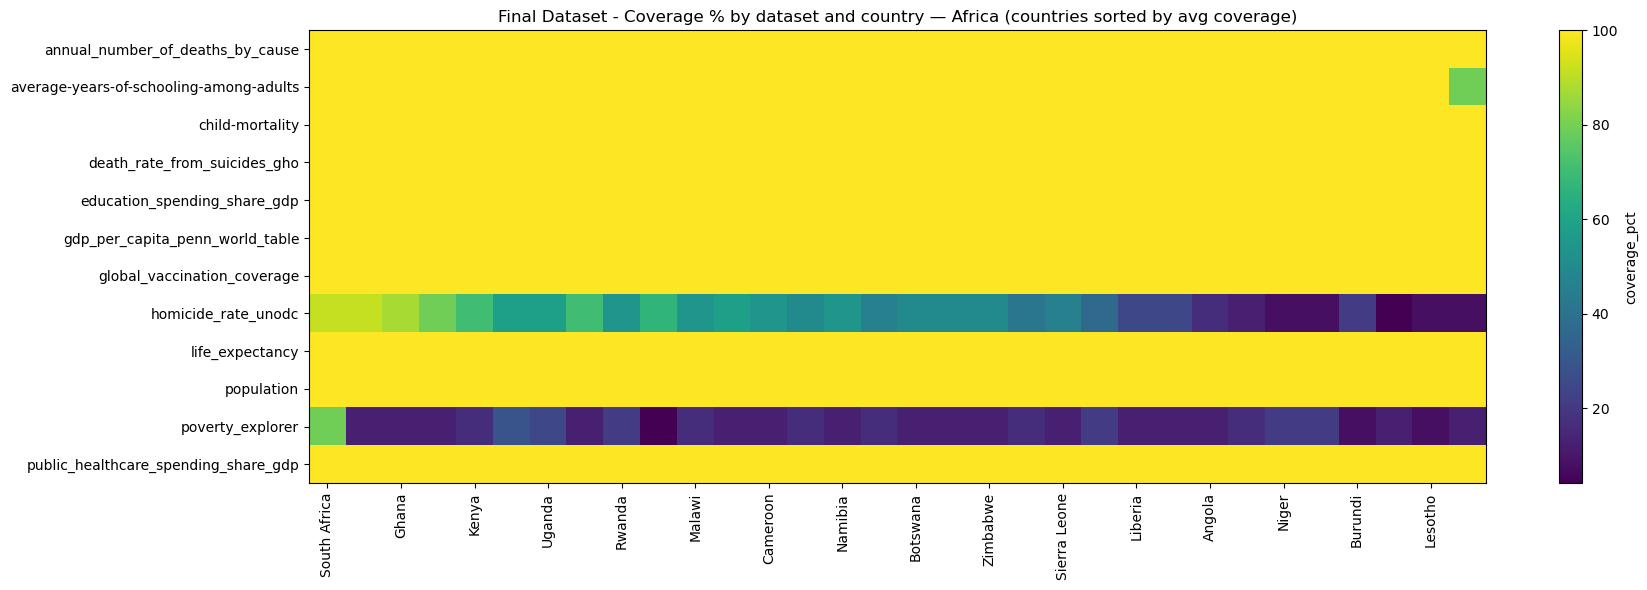

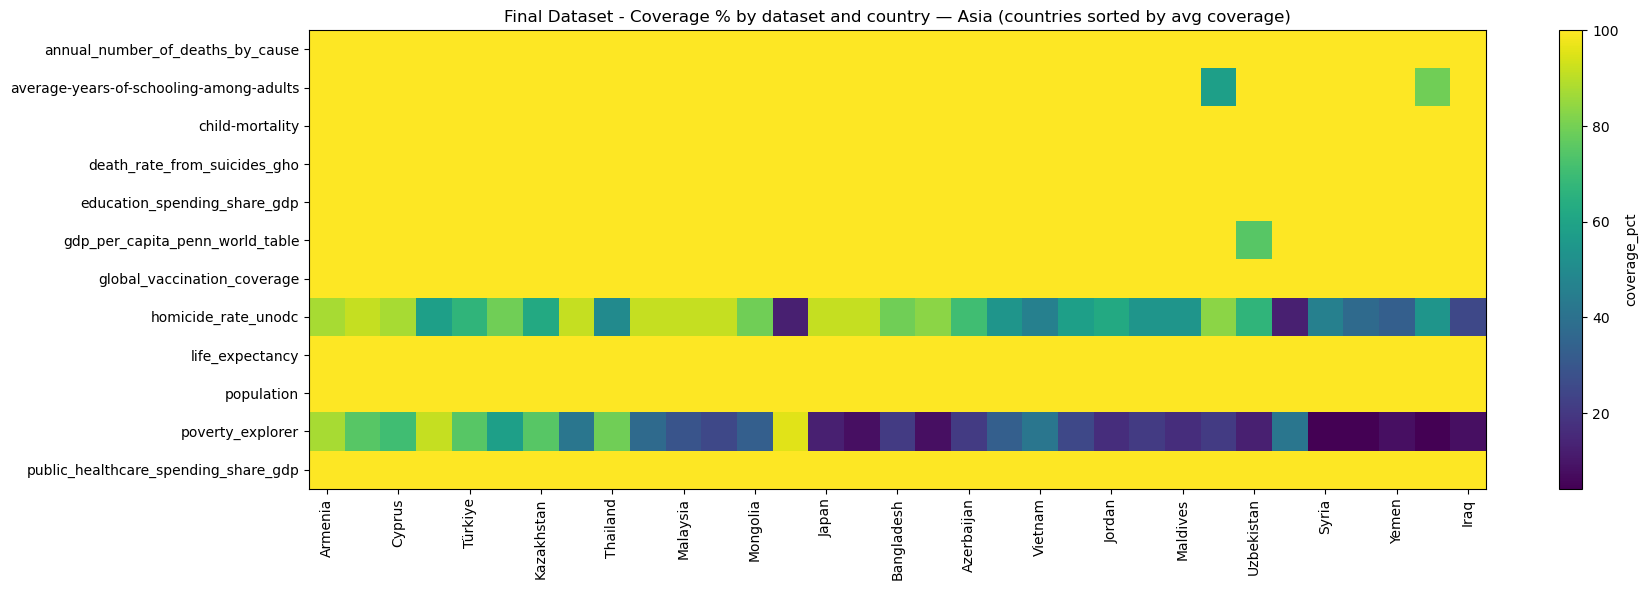

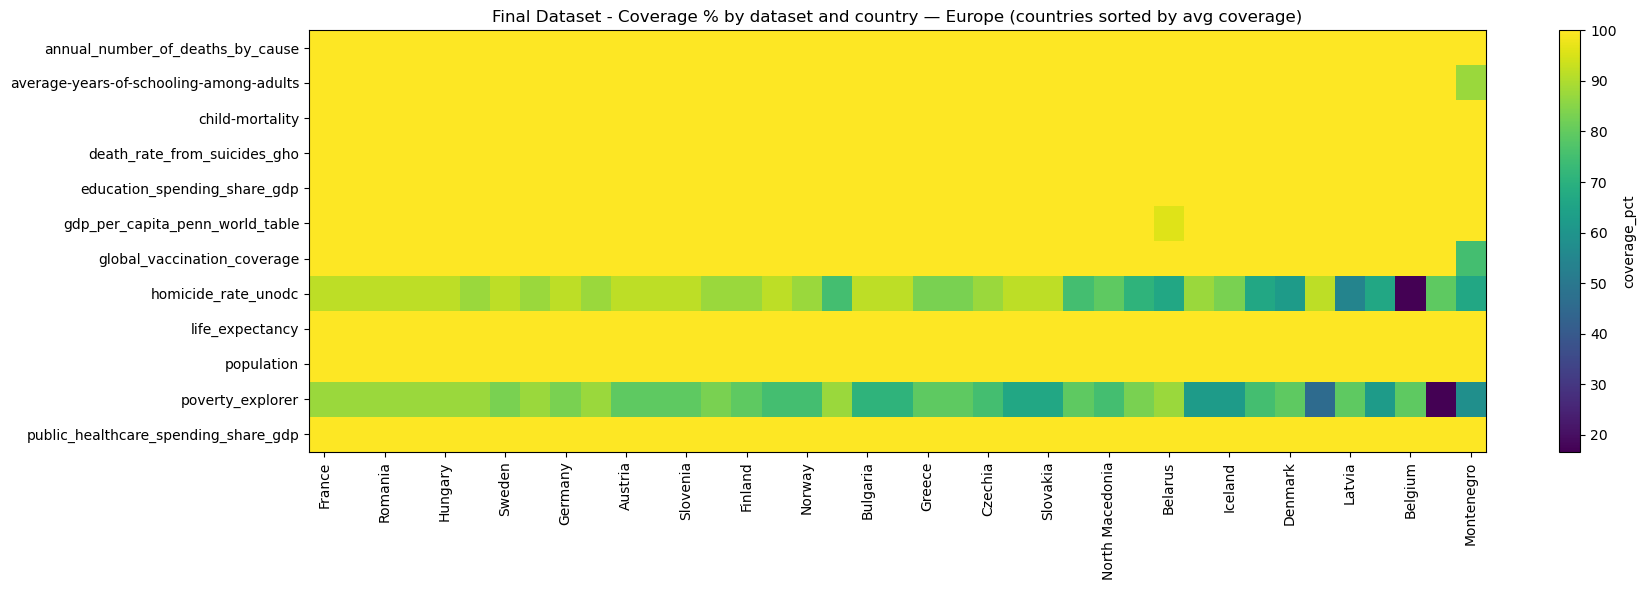

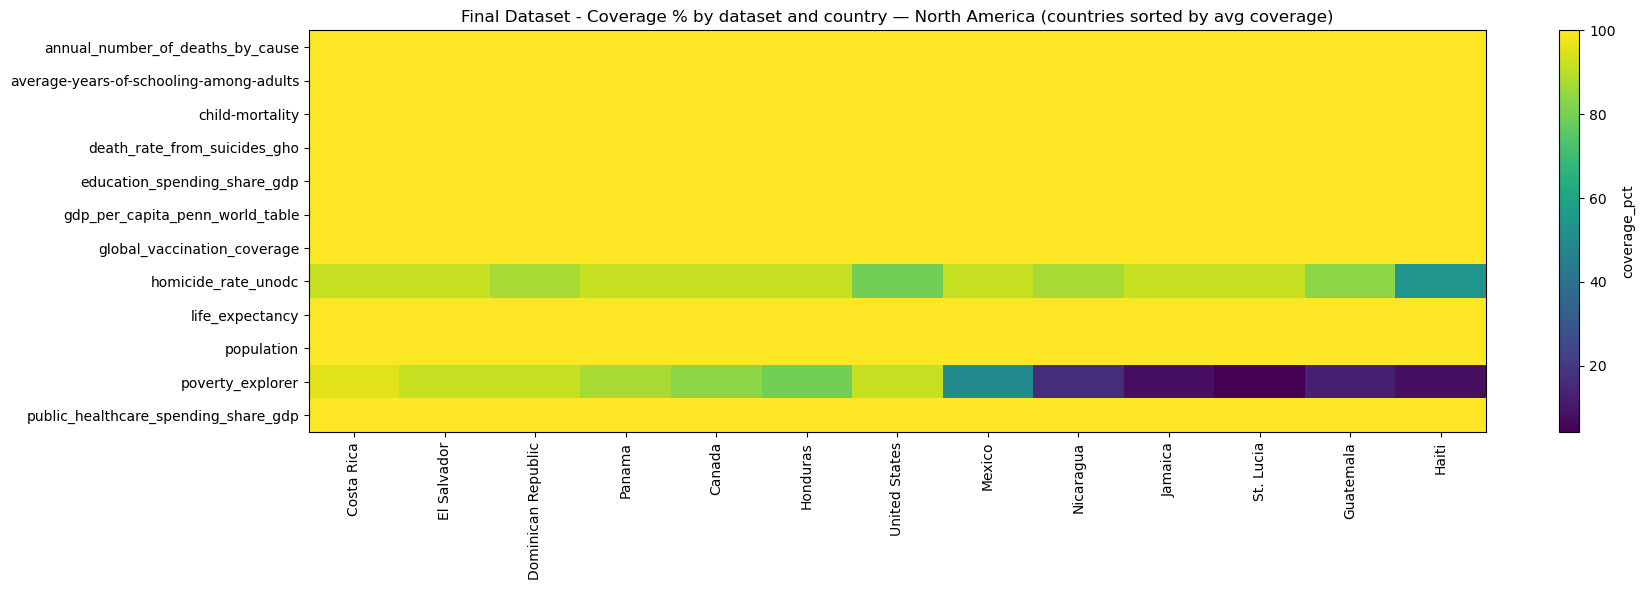

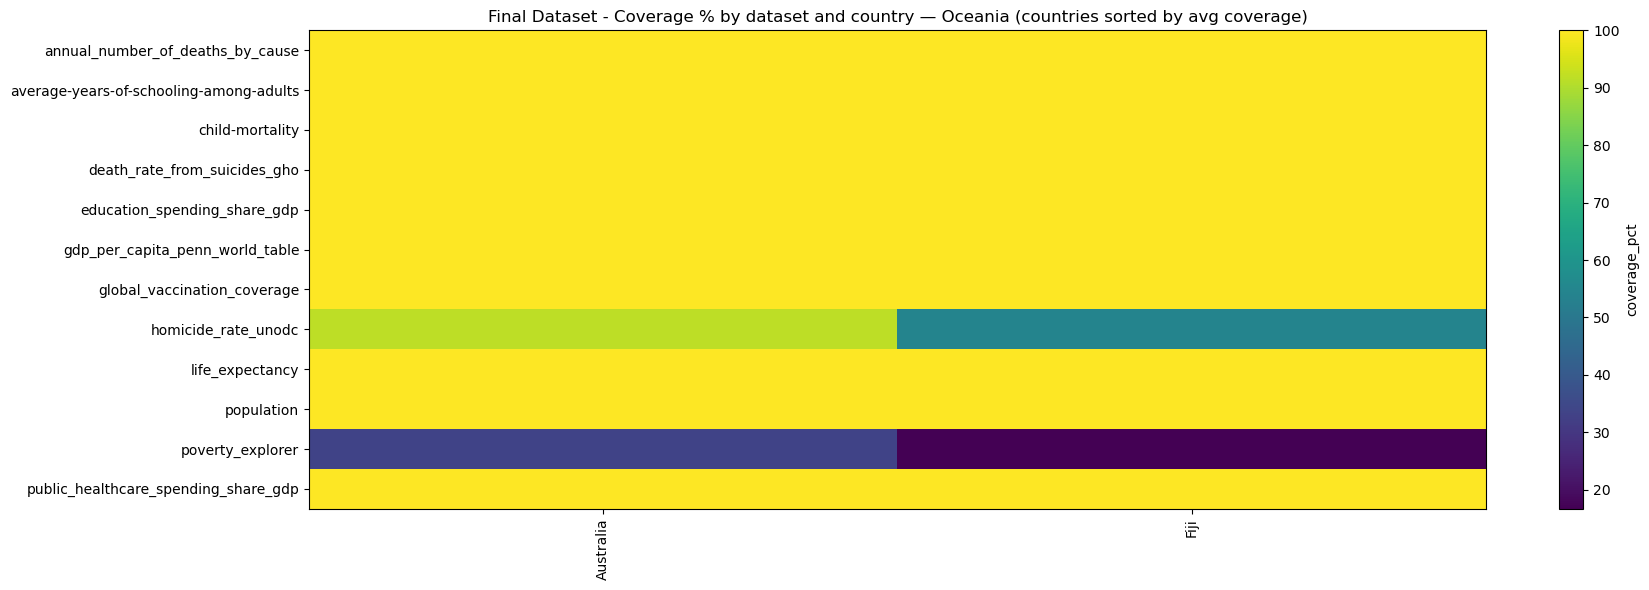

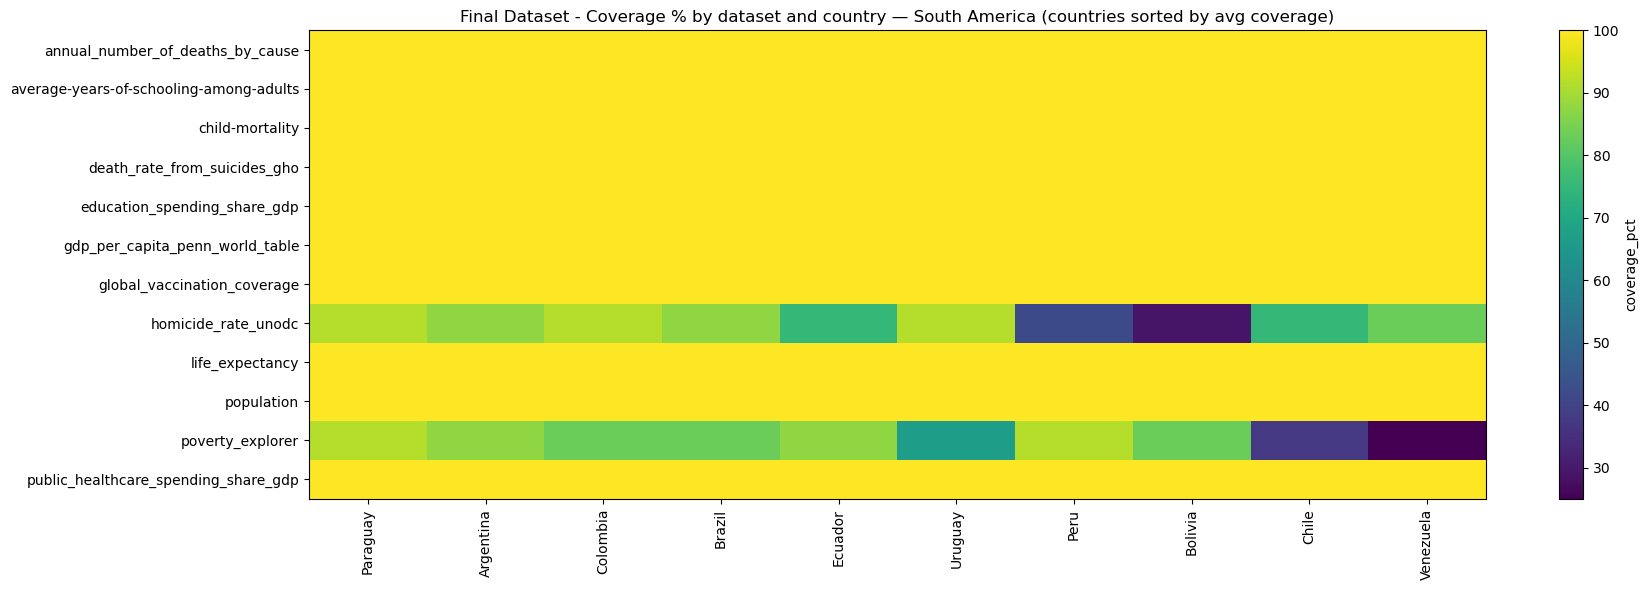

In [50]:
print(f'Final Dataset:\n')

results_data_agg = fns.analyze_coverage(dict_data_agg, year_min, year_max, coverage_threshold=95)

coverage_table = fns.get_coverage_table(results_data_agg)

# Un heatmap por continente (ordenado)
for cont, countries in inter_by_cont.items():
    # Ajustes automáticos para que se vea bien
    width = max(18, len(countries) * 0.45)  # más países => más ancho
    step = 1 if len(countries) <= 20 else 2  # si hay muchos países, reduce etiquetas
    fns.plot_coverage_heatmap_by_continent_sorted(
        coverage_table,
        countries,
        title=f"Final Dataset - Coverage % by dataset and country — {cont}",
        figsize=(width, 6),
        x_step=step
    )

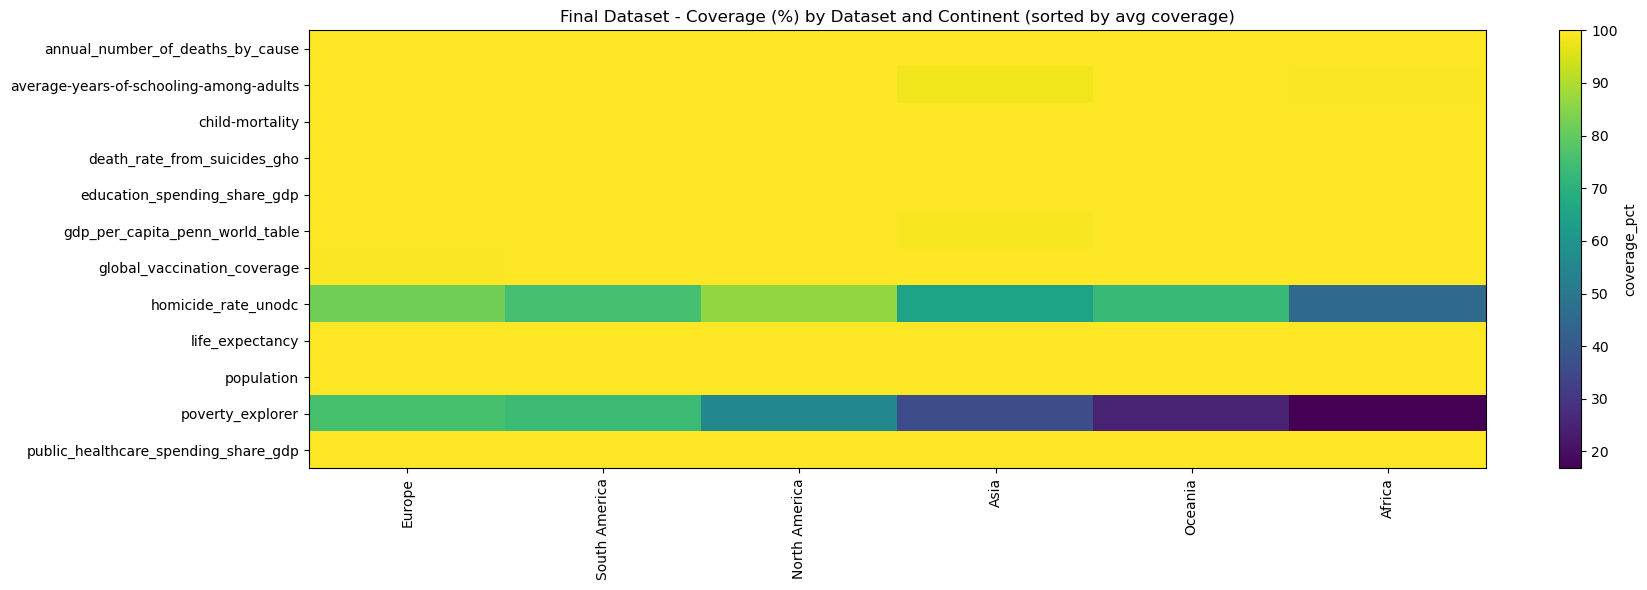

In [51]:
ct = coverage_table.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')

country_to_continent = {}
for cont, countries in inter_by_cont.items():
    for c in countries:
        country_to_continent[c] = cont

ct['Continent'] = ct.index.map(country_to_continent)
ct = ct.dropna(subset=['Continent'])

continent_coverage = ct.groupby('Continent').mean().round(1)
continent_coverage = continent_coverage.loc[
    continent_coverage.mean(axis=1).sort_values(ascending=False).index
]

# Plot — exact same style as your per-country heatmaps
plt.figure(figsize=(18, 6))
plt.imshow(continent_coverage.values.T, aspect="auto", interpolation="nearest")

plt.yticks(range(len(continent_coverage.columns)), continent_coverage.columns)
plt.xticks(range(len(continent_coverage.index)), continent_coverage.index, rotation=90)

plt.title("Final Dataset - Coverage (%) by Dataset and Continent (sorted by avg coverage)")
plt.colorbar(label="coverage_pct")
plt.tight_layout()
plt.show()

In [52]:
# IMPUTATION STRATEGY FOR df_merged_all
# ============================================================================
# Three-layer approach:
#   Layer 1: Within-country linear interpolation (fills gaps between known points)
#   Layer 2: Forward/backward fill for edges (carries last known value)
#   Layer 3: Continent-year median (for countries with no within-country data)
#
# CRITICAL: We interpolate WITHIN each country separately. We NEVER use
# data from other countries to fill gaps — that would introduce artificial
# cross-country correlations and bias the model.
# ============================================================================

df_imputed = fns.merge_all_datasets(dict_data_agg)

country_to_continent = {country: continent
                        for continent, countries in inter_by_cont.items()
                        for country in countries}
df_imputed['Continent'] = df_imputed['Country'].map(country_to_continent)

# Drop the unnamed index column if present
if 'Unnamed: 0' in df_imputed.columns:
    df_imputed = df_imputed.drop(columns=['Unnamed: 0'])

# Drop columns we've decided to exclude (YFV too sparse, IPV1 too sparse)
drop_cols = ['YFV', 'IPV1']
df_imputed = df_imputed.drop(columns=[c for c in drop_cols if c in df_imputed.columns])

# Drop duplicate Continent columns (keep only the main one)
continent_dups = [c for c in df_imputed.columns if c.startswith('Continent_')]
df_imputed = df_imputed.drop(columns=continent_dups)

print(f"Starting shape: {df_imputed.shape}")

# Identify numeric columns to impute (exclude identifiers)
id_cols = ['Country', 'Year', 'Continent']
numeric_cols = [c for c in df_imputed.columns 
                if c not in id_cols and df_imputed[c].dtype in ['float64', 'int64']]
print(f"Numeric columns to impute: {len(numeric_cols)}")

# Capture state BEFORE imputation (for summary)
nan_before = df_imputed[numeric_cols].isnull().sum().sum()
df_before  = df_imputed.copy()
print(f"Total NaN before imputation: {nan_before:,}")

# LAYER 1: Within-country linear interpolation
# ============================================================================
# For each country, sort by year and interpolate between known data points.
# limit_direction='both' fills gaps in both directions within the time series.
# Does NOT extrapolate beyond the first/last known value.
# ============================================================================

df_imputed = df_imputed.sort_values(['Country', 'Year'])

for col in numeric_cols:
    df_imputed[col] = (
        df_imputed
        .groupby('Country')[col]
        .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    )

nan_after_interp = df_imputed[numeric_cols].isnull().sum().sum()
print(f"\nAfter Layer 1 (interpolation):     {nan_after_interp:,} NaN remaining "
      f"(filled {nan_before - nan_after_interp:,})")

# LAYER 2: Forward-fill then backward-fill (max 5 years)
# ============================================================================
# For edge cases: if a country's last data point is 2018, carry it forward
# to 2019-2023 (max 5 years). If first observation is 2005, carry backward
# to 2000-2004. Limit prevents carrying stale data too far.
# ============================================================================

MAX_FILL = 3

for col in numeric_cols:
    df_imputed[col] = (
        df_imputed
        .groupby('Country')[col]
        .transform(lambda x: x.ffill(limit=MAX_FILL).bfill(limit=MAX_FILL))
    )

nan_after_fill = df_imputed[numeric_cols].isnull().sum().sum()
print(f"After Layer 2 (ffill/bfill ±{MAX_FILL}yr): {nan_after_fill:,} NaN remaining "
      f"(filled {nan_after_interp - nan_after_fill:,})")

# LAYER 3: Continent-year median
# ============================================================================
# For countries that never reported a value (no within-country data to
# interpolate from), use the median of their continent for that year.
# Philosophically: "a country in Sub-Saharan Africa in 2005 likely had
# coverage similar to its neighbors."
# ============================================================================

for col in numeric_cols:
    continent_year_median = (
        df_imputed.groupby(['Continent', 'Year'])[col].transform('median')
    )
    df_imputed[col] = df_imputed[col].fillna(continent_year_median)

nan_after_median = df_imputed[numeric_cols].isnull().sum().sum()
print(f"After Layer 3 (continent median):  {nan_after_median:,} NaN remaining "
      f"(filled {nan_after_fill - nan_after_median:,})")

# SUMMARY
# ============================================================================

total_cells = df_imputed[numeric_cols].size

print(f"\n{'='*70}")
print("IMPUTATION SUMMARY")
print(f"{'='*70}")
print(f"Total cells:     {total_cells:,}")
print(f"NaN before:      {nan_before:,} ({nan_before/total_cells*100:.1f}%)")
print(f"NaN after:       {nan_after_median:,} ({nan_after_median/total_cells*100:.1f}%)")
print(f"Cells filled:    {nan_before - nan_after_median:,} "
      f"({(nan_before - nan_after_median)/total_cells*100:.1f}%)")

print(f"\n📊 Remaining missingness by column:")
remaining = df_imputed[numeric_cols].isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
for col, n_miss in remaining.items():
    pct_before = df_before[col].isnull().sum() / len(df_before) * 100
    pct_after  = n_miss / len(df_imputed) * 100
    print(f"  {col:50s} | {pct_before:5.1f}% → {pct_after:5.1f}% "
          f"({pct_before - pct_after:5.1f}% filled)")
    
# ── Convert absolute death counts to rates (per 100,000 population) ──────────
# Do this AFTER imputation so Population has no missing values
# ============================================================================

death_cause_cols = [
    'Acute hepatitis', 'Alcohol use disorders',
    "Alzheimer's disease and other dementias", 'Cardiovascular diseases',
    'Chronic kidney disease', 'Chronic respiratory diseases',
    'Cirrhosis and other chronic liver diseases', 'Conflict and terrorism',
    'Diabetes mellitus', 'Diarrheal diseases', 'Digestive diseases',
    'Drowning', 'Drug use disorders', 'Environmental heat and cold exposure',
    'Exposure to forces of nature', 'Fire, heat, and hot substances',
    'HIV/AIDS', 'Interpersonal violence', 'Lower respiratory infections',
    'Malaria', 'Maternal disorders', 'Meningitis', 'Neonatal disorders',
    'Neoplasms', 'Nutritional deficiencies', "Parkinson's disease",
    'Poisonings', 'Protein-energy malnutrition', 'Road injuries',
    'Self-harm', 'Tuberculosis'
]

# Only convert columns that exist and where Population is available
available_death_cols = [c for c in death_cause_cols if c in df_imputed.columns]

df_imputed[available_death_cols] = df_imputed[available_death_cols].div(
    df_imputed['Population'], axis=0
) * 100_000

# Verify — check a known country/year
sample = df_imputed[df_imputed['Country'] == 'Colombia'][
    ['Country', 'Year', 'Population', 'Cardiovascular diseases']
].head(5)
print(sample)
print(f"\n✅ Converted {len(available_death_cols)} death columns to rates per 100,000")

# SAVE
# ============================================================================

df_imputed.to_csv('Phase_A_docs/df_merged_all_imputed.csv', index=False)
print(f"\n✅ Saved: df_merged_all_imputed.csv  {df_imputed.shape}")

Base: annual_number_of_deaths_by_cause - Shape: (3096, 33)
1. + average-years-of-schooling-among-adults - Shape: (3096, 34)
2. + child-mortality - Shape: (3096, 35)
3. + death_rate_from_suicides_gho - Shape: (3096, 36)
4. + education_spending_share_gdp - Shape: (3096, 37)
5. + gdp_per_capita_penn_world_table - Shape: (3096, 38)
6. + global_vaccination_coverage - Shape: (3096, 49)
7. + homicide_rate_unodc - Shape: (3096, 50)
8. + life_expectancy - Shape: (3096, 51)
9. + population - Shape: (3096, 52)
10. + poverty_explorer - Shape: (3096, 65)
11. + public_healthcare_spending_share_gdp - Shape: (3096, 66)

 Merged DataFrame: (3096, 66)
   Columns: 66
   Rows: 3,096
Starting shape: (3096, 67)
Numeric columns to impute: 63
Total NaN before imputation: 28,264

After Layer 1 (interpolation):     3,432 NaN remaining (filled 24,832)
After Layer 2 (ffill/bfill ±3yr): 3,432 NaN remaining (filled 0)
After Layer 3 (continent median):  48 NaN remaining (filled 3,384)

IMPUTATION SUMMARY
Total cells

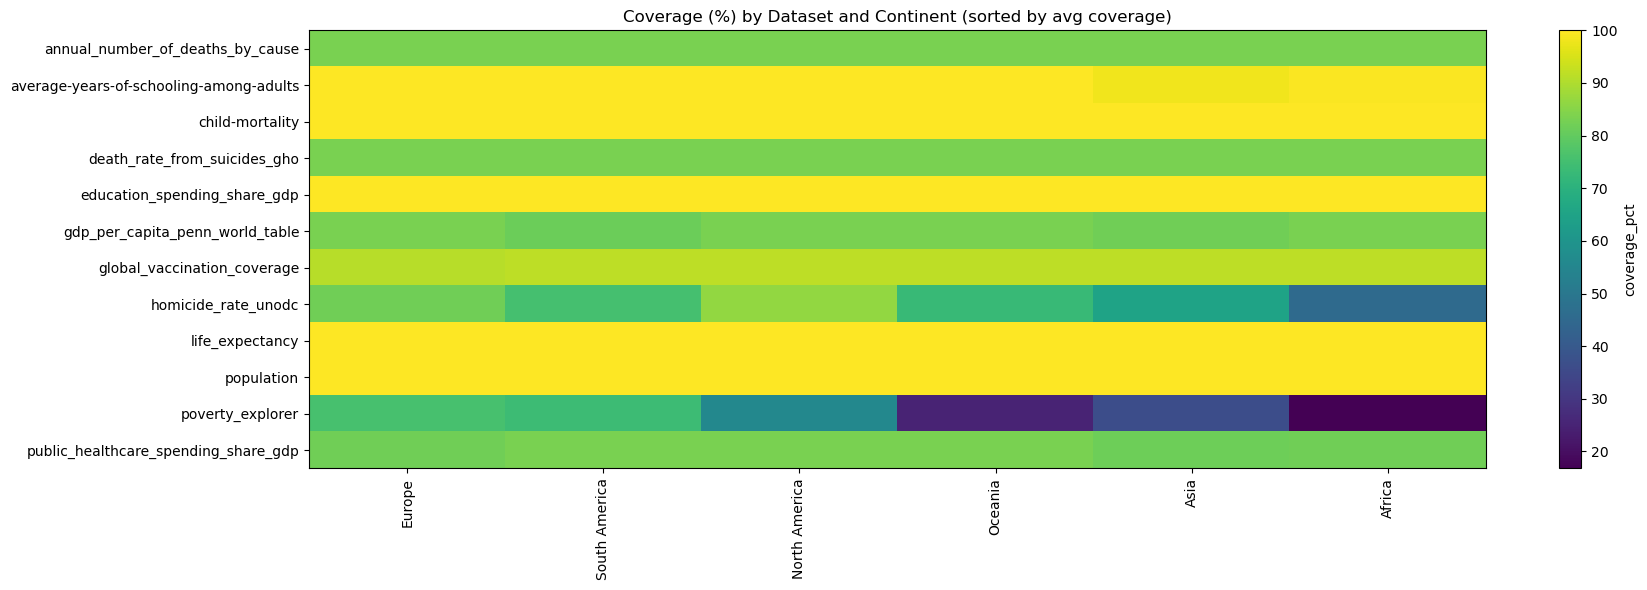

In [53]:
ct = coverage_table_intersec.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')

country_to_continent = {}
for cont, countries in inter_by_cont.items():
    for c in countries:
        country_to_continent[c] = cont

ct['Continent'] = ct.index.map(country_to_continent)
ct = ct.dropna(subset=['Continent'])

continent_coverage = ct.groupby('Continent').mean().round(1)
continent_coverage = continent_coverage.loc[
    continent_coverage.mean(axis=1).sort_values(ascending=False).index
]

# Plot — exact same style as your per-country heatmaps
plt.figure(figsize=(18, 6))
plt.imshow(continent_coverage.values.T, aspect="auto", interpolation="nearest")

plt.yticks(range(len(continent_coverage.columns)), continent_coverage.columns)
plt.xticks(range(len(continent_coverage.index)), continent_coverage.index, rotation=90)

plt.title("Coverage (%) by Dataset and Continent (sorted by avg coverage)")
plt.colorbar(label="coverage_pct")
plt.tight_layout()
plt.show()


Coverage Analysis: 2000-2023 (24 years)
Coverage threshold: 95%

DataFrame:
  Countries with coverage >= 95%: 129
  Countries with coverage < 95%: 0


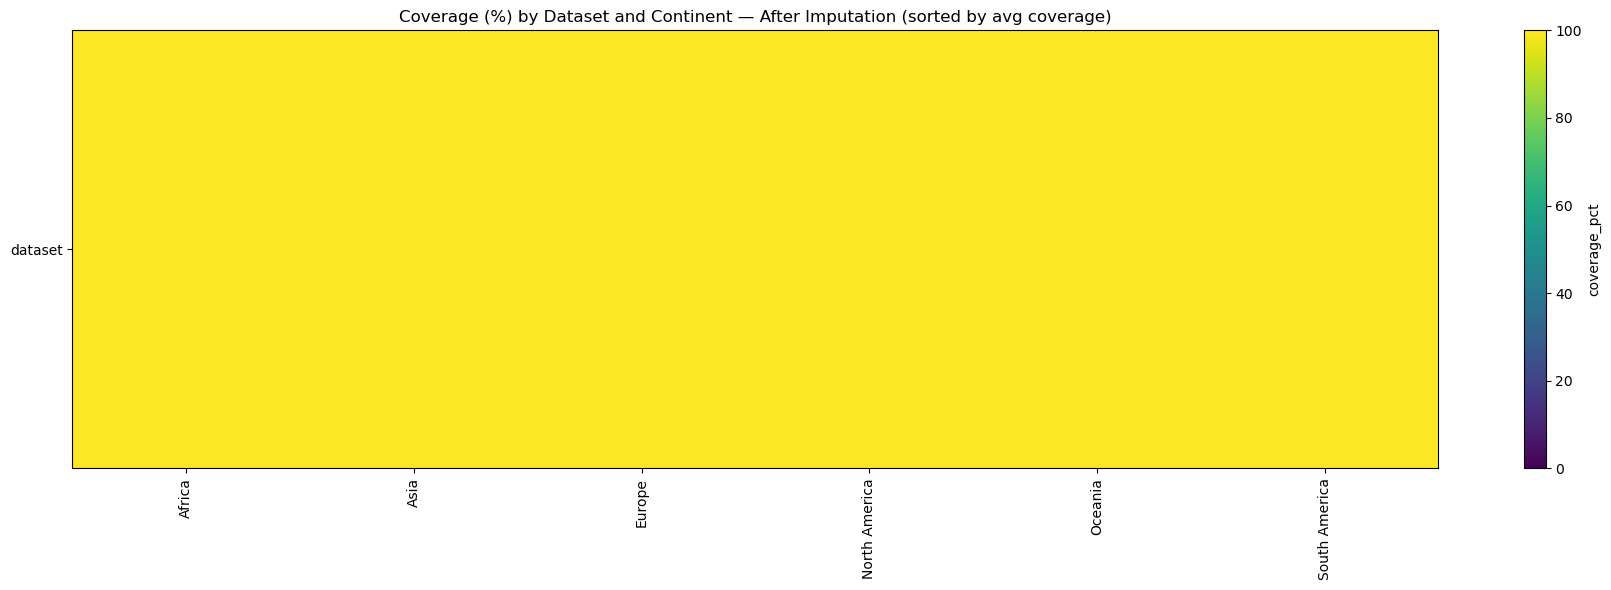

In [54]:
coverage_table_final = fns.get_coverage_table(fns.analyze_coverage(df_imputed, year_min, year_max, coverage_threshold=95))

#coverage_table = fns.get_coverage_table(results_data_agg)

ct = coverage_table_final.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')

country_to_continent = {}
for cont, countries in inter_by_cont.items():
    for c in countries:
        country_to_continent[c] = cont

ct['Continent'] = ct.index.map(country_to_continent)
ct = ct.dropna(subset=['Continent'])

continent_coverage = ct.groupby('Continent').mean().round(1)
continent_coverage = continent_coverage.loc[
    continent_coverage.mean(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(18, 6))
plt.imshow(continent_coverage.values.T, aspect="auto", interpolation="nearest", vmin=0, vmax=100)

plt.yticks(range(len(continent_coverage.columns)), continent_coverage.columns)
plt.xticks(range(len(continent_coverage.index)), continent_coverage.index, rotation=90)

plt.title("Coverage (%) by Dataset and Continent — After Imputation (sorted by avg coverage)")
plt.colorbar(label="coverage_pct")
plt.tight_layout()
plt.show()

In [55]:
# Quick check: what does the after-imputation coverage actually look like?
ct = coverage_table_final.T.copy()
ct = ct.apply(pd.to_numeric, errors='coerce')
print(f"Min coverage: {ct.min().min():.1f}%")
print(f"Max coverage: {ct.max().max():.1f}%")
print(f"Mean coverage: {ct.mean().mean():.1f}%")
print(f"\nDatasets below 100%:")
print(ct.mean().sort_values().head(10).round(1))

Min coverage: 100.0%
Max coverage: 100.0%
Mean coverage: 100.0%

Datasets below 100%:
dataset    100.0
dtype: float64


In [56]:
df_life = df_imputed[['Continent', 'Country', 'Year', 'Life Expectancy']].copy()
df_life.columns

CONTINENT_COLORS = {
'Africa':        '#66c2a5',
'Asia':          '#fc8d62',
'Europe':        '#8da0cb',
'North America': '#e78ac3',
'Oceania':       '#a6d854',
'South America': '#ffd92f',
}

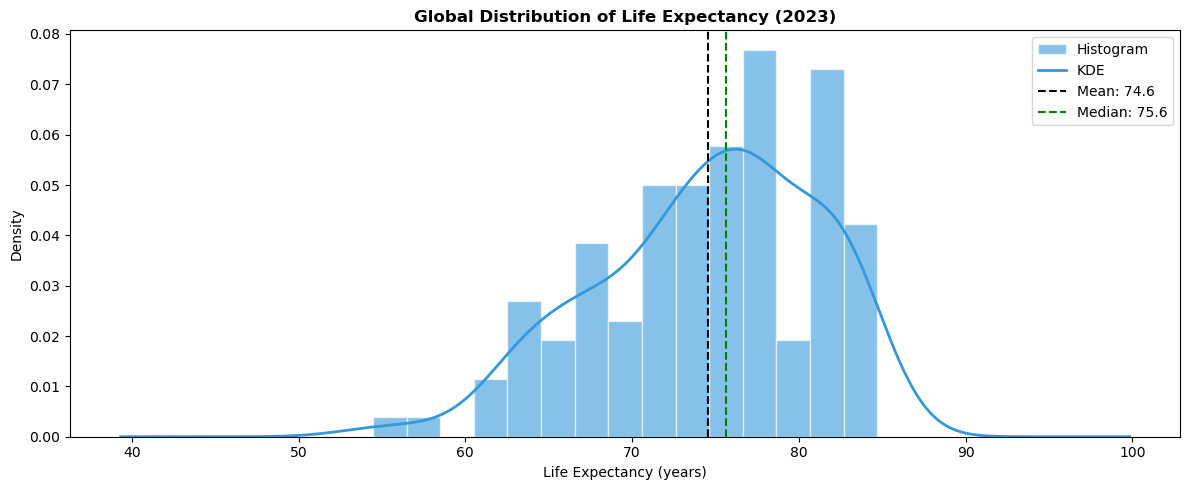

Mean:   74.6
Median: 75.6


In [57]:
def plot_le_distribution(df_life, backend="plotly"):
    """
    Plot the distribution of Life Expectancy for the latest available year.

    Parameters
    ----------
    df_life  : pd.DataFrame   must contain 'Year' and 'Life Expectancy' columns
    backend  : {"plotly", "matplotlib"}
    """
    latest_year = df_life['Year'].max()
    df_latest   = df_life[df_life['Year'] == latest_year]
    le          = df_latest['Life Expectancy'].dropna()
    mean_val    = le.mean()
    median_val  = le.median()

    if backend == "plotly":
        fig = ff.create_distplot(
            [le], ['Life Expectancy'],
            bin_size=5, colors=['#3498db'], show_rug=False
        )
        fig.add_vline(x=mean_val,   line_dash="dash", line_color="black",
                      annotation_text=f"Mean: {mean_val:.1f}")
        fig.add_vline(x=median_val, line_dash="dash", line_color="green",
                      annotation_text=f"Median: {median_val:.1f}")
        fig.update_layout(
            title=f'<b>Global Distribution of Life Expectancy ({latest_year})</b>',
            xaxis_title='Life Expectancy (years)',
            yaxis_title='Density',
            template='plotly_white',
            showlegend=False
        )
        fig.show()

    elif backend == "matplotlib":
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.hist(le, bins=15, density=True,
                color='#3498db', alpha=0.6, edgecolor='white', label='Histogram')
        le.plot.kde(ax=ax, color='#3498db', linewidth=2, label='KDE')
        ax.axvline(mean_val,   color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                   label=f'Median: {median_val:.1f}')
        ax.set_title(f'Global Distribution of Life Expectancy ({latest_year})', fontweight='bold')
        ax.set_xlabel('Life Expectancy (years)')
        ax.set_ylabel('Density')
        ax.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")

    print(f"Mean:   {mean_val:.1f}")
    print(f"Median: {median_val:.1f}")


# Usage
#plot_le_distribution(df_life, backend="plotly")
plot_le_distribution(df_life, backend="matplotlib")

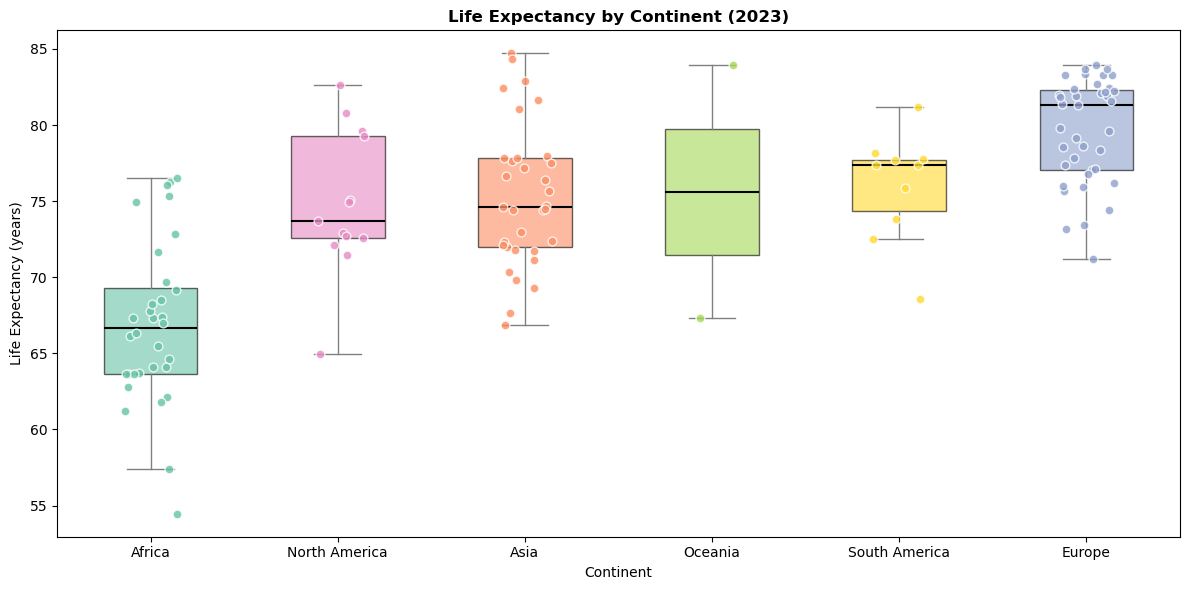

In [58]:
def plot_le_by_continent_box(df_life, inter_by_cont, backend="plotly"):
    """
    Box plot with jittered points of Life Expectancy by continent
    for the latest available year.

    Parameters
    ----------
    df_life       : pd.DataFrame   must contain 'Year' and 'Life Expectancy'
    inter_by_cont : dict           {continent: [countries]} used to map Continent if missing
    backend       : {"plotly", "matplotlib"}
    """
    if 'Continent' not in df_life.columns:
        country_to_continent = {country: continent
                                for continent, countries in inter_by_cont.items()
                                for country in countries}
        df_life = df_life.copy()
        df_life['Continent'] = df_life['Country'].map(country_to_continent)

    latest_year     = df_life['Year'].max()
    df_latest       = df_life[df_life['Year'] == latest_year]
    continent_order = (df_latest.groupby('Continent')['Life Expectancy']
                                .median().sort_values().index.tolist())

    if backend == "plotly":
        fig = px.box(
            df_latest,
            x='Continent',
            y='Life Expectancy',
            color='Continent',
            category_orders={'Continent': continent_order},
            color_discrete_map=CONTINENT_COLORS,
            points="all",
            title=f'<b>Life Expectancy by Continent ({latest_year})</b>',
            template='plotly_white'
        )
        fig.update_layout(
            xaxis_title='Continent',
            yaxis_title='Life Expectancy (years)',
            showlegend=False
        )
        fig.show()

    elif backend == "matplotlib":
        colors = [CONTINENT_COLORS.get(c, 'gray') for c in continent_order]

        fig, ax = plt.subplots(figsize=(12, 6))

        for i, (cont, color) in enumerate(zip(continent_order, colors)):
            data = df_latest[df_latest['Continent'] == cont]['Life Expectancy'].dropna()

            ax.boxplot(data, positions=[i], widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color='black', linewidth=1.5),
                       whiskerprops=dict(color='gray'),
                       capprops=dict(color='gray'),
                       flierprops=dict(marker='', markersize=0))

            jitter = np.random.uniform(-0.15, 0.15, size=len(data))
            ax.scatter(np.full(len(data), i) + jitter, data,
                       color=color, edgecolor='white', s=40, alpha=0.8, zorder=3)

        ax.set_xticks(range(len(continent_order)))
        ax.set_xticklabels(continent_order)
        ax.set_title(f'Life Expectancy by Continent ({latest_year})', fontweight='bold')
        ax.set_xlabel('Continent')
        ax.set_ylabel('Life Expectancy (years)')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")


# Usage
#plot_le_by_continent_box(df_life, inter_by_cont, backend="plotly")
plot_le_by_continent_box(df_life, inter_by_cont, backend="matplotlib")

In [59]:
# --- 1c. Summary Table by Continent ---
latest_year = df_life['Year'].max()
df_latest   = df_life[df_life['Year'] == latest_year].copy()

if 'Continent' not in df_latest.columns:
    country_to_continent = {country: continent
                            for continent, countries in inter_by_cont.items()
                            for country in countries}
    df_latest['Continent'] = df_latest['Country'].map(country_to_continent)

summary = df_latest.groupby('Continent')['Life Expectancy'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(1)
summary.columns = ['N Countries', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
summary['Range'] = (summary['Max'] - summary['Min']).round(1)
summary = summary.sort_values('Median', ascending=False)

print(f"Life Expectancy Summary by Continent ({latest_year}):")
display(summary)

best  = df_latest.loc[df_latest['Life Expectancy'].idxmax()]
worst = df_latest.loc[df_latest['Life Expectancy'].idxmin()]
print(f"\n🟢 Highest: {best['Country']} ({best['Continent']}) — {best['Life Expectancy']:.1f} years")
print(f"🔴 Lowest:  {worst['Country']} ({worst['Continent']}) — {worst['Life Expectancy']:.1f} years")

Life Expectancy Summary by Continent (2023):


,N Countries,Mean,Median,Std Dev,Min,Max,Range
Continent,,,,,,,
Europe,39,79.7,81.3,3.4,71.2,84.0,12.8
South America,10,76.0,77.4,3.5,68.6,81.2,12.6
Oceania,2,75.6,75.6,11.7,67.3,83.9,16.6
Asia,33,75.3,74.6,4.7,66.9,84.7,17.8
North America,13,74.8,73.7,4.7,64.9,82.6,17.7
Africa,32,66.9,66.7,5.3,54.5,76.5,22.0



🟢 Highest: Japan (Asia) — 84.7 years
🔴 Lowest:  Nigeria (Africa) — 54.5 years


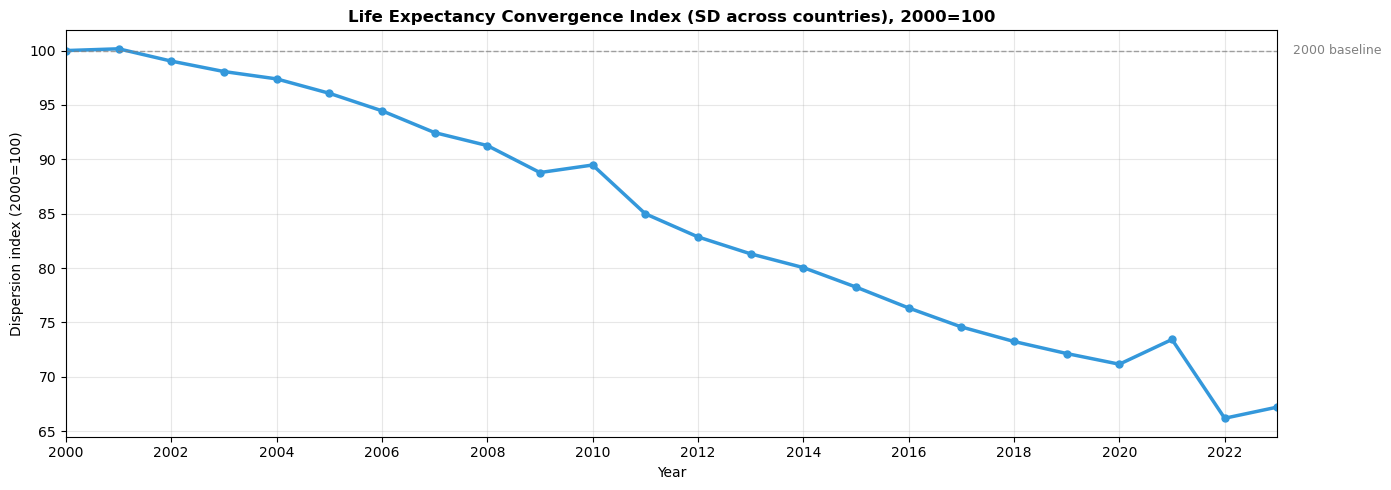

In [60]:
# Convergence index chart — Country-level Standard Deviation (SD)
# =========================
def plot_le_convergence_index(df_le: pd.DataFrame, baseline_year: int = 2000, backend: str = "plotly"):
    """
    Compute the cross-COUNTRY standard deviation of life expectancy
    each year, normalize to baseline_year = 100, and plot.

    Parameters
    ----------
    df_le : pd.DataFrame
    baseline_year : int, default 2000
    backend : {"plotly", "matplotlib"}
    """
    df_clean = df_le.dropna(subset=["Year", "Country", "Life Expectancy"])

    sd_by_year = (
        df_clean
        .groupby("Year", as_index=False)["Life Expectancy"]
        .agg(sd_cross_countries="std", mean_cross_countries="mean", n_countries="count")
    )

    # Normalize to baseline
    base = sd_by_year.loc[sd_by_year["Year"] == baseline_year, "sd_cross_countries"]
    if base.empty or pd.isna(base.iloc[0]) or base.iloc[0] == 0:
        raise ValueError(f"Baseline year {baseline_year} SD is missing or zero; choose another baseline.")
    base_val = float(base.iloc[0])
    sd_by_year["sd_index"] = 100 * sd_by_year["sd_cross_countries"] / base_val

    if backend == "plotly":
        fig = px.line(
            sd_by_year,
            x="Year",
            y="sd_index",
            markers=True,
            title=f"Life Expectancy Convergence Index (SD across countries), {baseline_year}=100",
            labels={"sd_index": "Dispersion index (2000=100)"},
        )
        fig.add_hline(
            y=100,
            line_dash="dash",
            annotation_text=f"{baseline_year} baseline",
            annotation_position="bottom right",
        )
        fig.update_layout(hovermode="x unified")
        fig.show()
        return fig, sd_by_year

    elif backend == "matplotlib":
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(sd_by_year["Year"], sd_by_year["sd_index"],
                color="#3498db", linewidth=2.5, marker="o", markersize=5)
        ax.axhline(y=100, color="gray", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(sd_by_year["Year"].max() + 0.3, 100, f"{baseline_year} baseline",
                va="center", color="gray", fontsize=9)
        ax.set_title(f"Life Expectancy Convergence Index (SD across countries), {baseline_year}=100",
                     fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("Dispersion index (2000=100)")
        ax.set_xticks(range(int(sd_by_year["Year"].min()), int(sd_by_year["Year"].max()) + 1, 2))
        ax.set_xlim(sd_by_year["Year"].min(), sd_by_year["Year"].max())
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        return sd_by_year

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")


# Usage
#fig, sd_tbl = plot_le_convergence_index(df_life, baseline_year=2000, backend="plotly")
sd_tbl      = plot_le_convergence_index(df_life, baseline_year=2000, backend="matplotlib")

In [62]:
convergence_categories = {
    'Life Expectancy & Health (Vaccination)': [
        ('life_expectancy', 'Life Expectancy'),
        ('global_vaccination_coverage', 'DTP3'),
        ('global_vaccination_coverage', 'MCV1'),
        ('global_vaccination_coverage', 'HepB3'),
        ('global_vaccination_coverage', 'Hib3'),
        ('global_vaccination_coverage', 'Pol3'),
        ('global_vaccination_coverage', 'PCV3'),
        ('global_vaccination_coverage', 'RCV1'),
        ('global_vaccination_coverage', 'DTP1'),
        ('global_vaccination_coverage', 'MCV2'),
        ('global_vaccination_coverage', 'RotaC'),
        ('global_vaccination_coverage', 'BCG'),
    ],
    'Demographic & Social': [
        ('life_expectancy', 'Life Expectancy'),
        ('child-mortality', 'Child mortality rate'),
        ('average-years-of-schooling-among-adults', 'Average years of schooling'),
        ('death_rate_from_suicides_gho', 'Suicide Rate'),
        ('homicide_rate_unodc', 'Homicide Rate'),
    ],
    'Economic & Inequality': [
        ('life_expectancy', 'Life Expectancy'),
        ('gdp_per_capita_penn_world_table', 'GDP per Capita'),
        ('public_healthcare_spending_share_gdp', '% GDP on Health Expenditure'),
        ('education_spending_share_gdp', '% GDP on Education Expenditure'),
        ('poverty_explorer', 'gini'),
    ],
    'Poverty & Income Distribution': [
        ('life_expectancy', 'Life Expectancy'),
        ('poverty_explorer', 'Share below $2.15 a day'),
        ('poverty_explorer', 'Share below $6.85 a day'),
        ('poverty_explorer', 'Mean income or consumption per day'),
        ('poverty_explorer', 'palma_ratio'),
        ('poverty_explorer', 'p90_p10_ratio'),
        ('poverty_explorer', 'bottom50_share'),
    ],
    'Health System Performance': [
        ('life_expectancy', 'Life Expectancy'),
        ('public_healthcare_spending_share_gdp', '% GDP on Health Expenditure'),
        ('education_spending_share_gdp', '% GDP on Education Expenditure'),
        ('child-mortality', 'Child mortality rate'),
        ('average-years-of-schooling-among-adults', 'Average years of schooling'),
        ('gdp_per_capita_penn_world_table', 'GDP per Capita'),
    ],
    'Deaths by Cause (Communicable & Preventable)': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'HIV/AIDS'),
        ('annual_number_of_deaths_by_cause', 'Tuberculosis'),
        ('annual_number_of_deaths_by_cause', 'Malaria'),
        ('annual_number_of_deaths_by_cause', 'Maternal disorders'),
        ('annual_number_of_deaths_by_cause', 'Neonatal disorders'),
        ('annual_number_of_deaths_by_cause', 'Diarrheal diseases'),
        ('annual_number_of_deaths_by_cause', 'Lower respiratory infections'),
        ('annual_number_of_deaths_by_cause', 'Meningitis'),
    ],
    'Deaths by Cause (Non-Communicable)': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'Cardiovascular diseases'),
        ('annual_number_of_deaths_by_cause', 'Neoplasms'),
        ('annual_number_of_deaths_by_cause', 'Chronic respiratory diseases'),
        ('annual_number_of_deaths_by_cause', 'Diabetes mellitus'),
        ('annual_number_of_deaths_by_cause', 'Alzheimer\'s disease and other dementias'),
        ('annual_number_of_deaths_by_cause', 'Chronic kidney disease'),
        ('annual_number_of_deaths_by_cause', 'Cirrhosis and other chronic liver diseases'),
        ('annual_number_of_deaths_by_cause', 'Digestive diseases'),
    ],
    'Deaths by Cause (Injuries & External)': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'Conflict and terrorism'),
        ('annual_number_of_deaths_by_cause', 'Interpersonal violence'),
        ('annual_number_of_deaths_by_cause', 'Road injuries'),
        ('annual_number_of_deaths_by_cause', 'Self-harm'),
        ('annual_number_of_deaths_by_cause', 'Alcohol use disorders'),
        ('annual_number_of_deaths_by_cause', 'Drug use disorders'),
        ('annual_number_of_deaths_by_cause', 'Poisonings'),
        ('annual_number_of_deaths_by_cause', 'Drowning'),
    ],
}

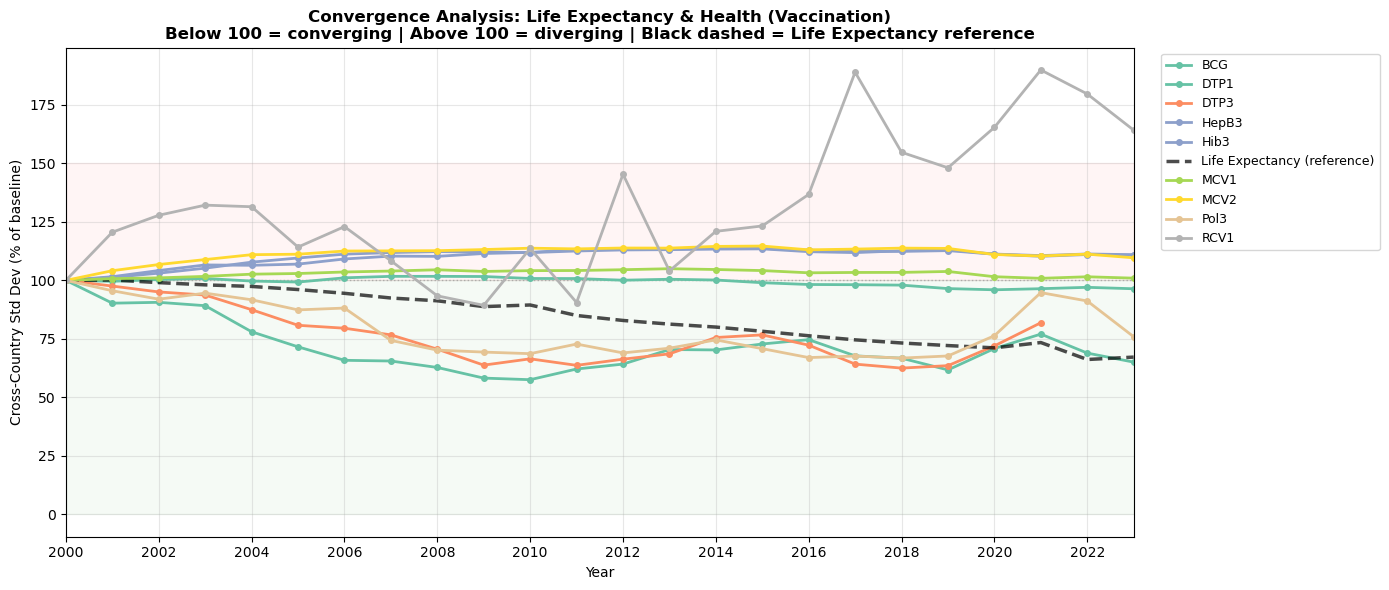

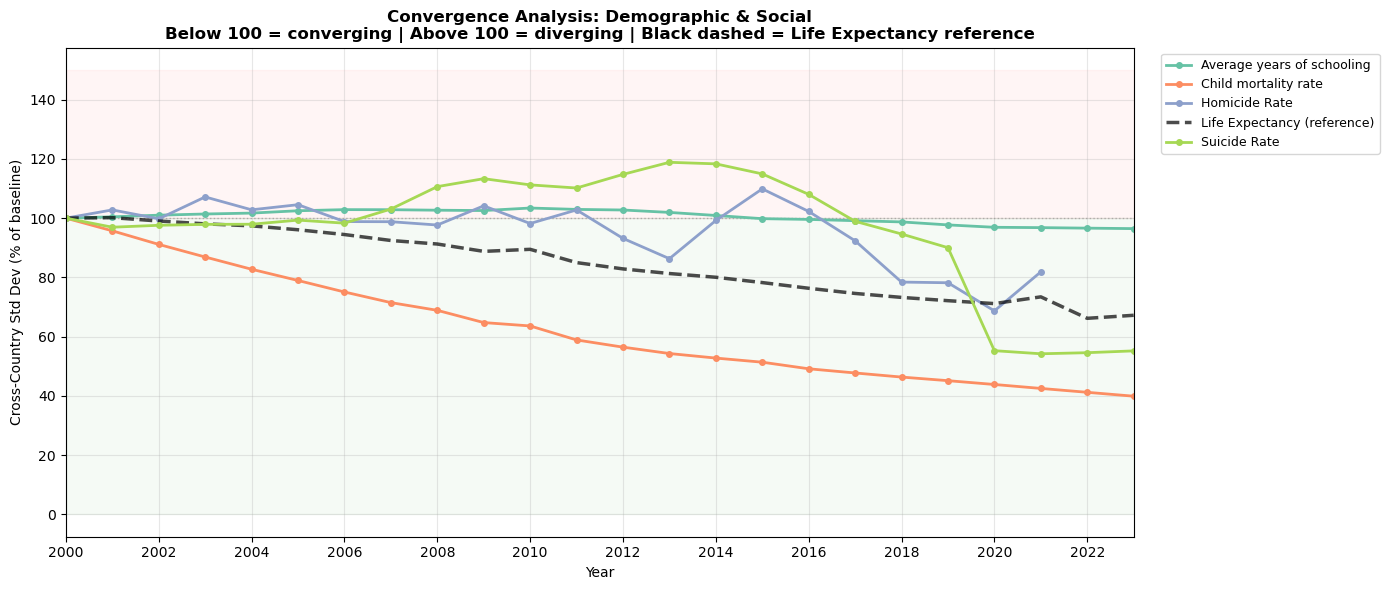

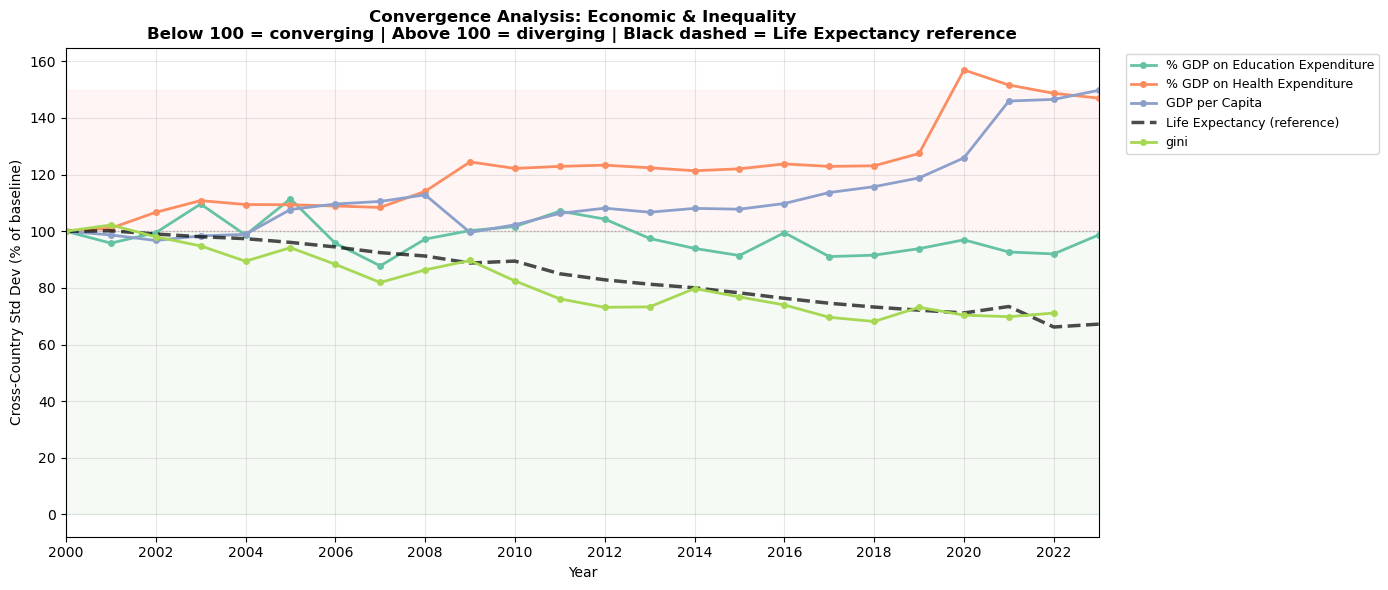

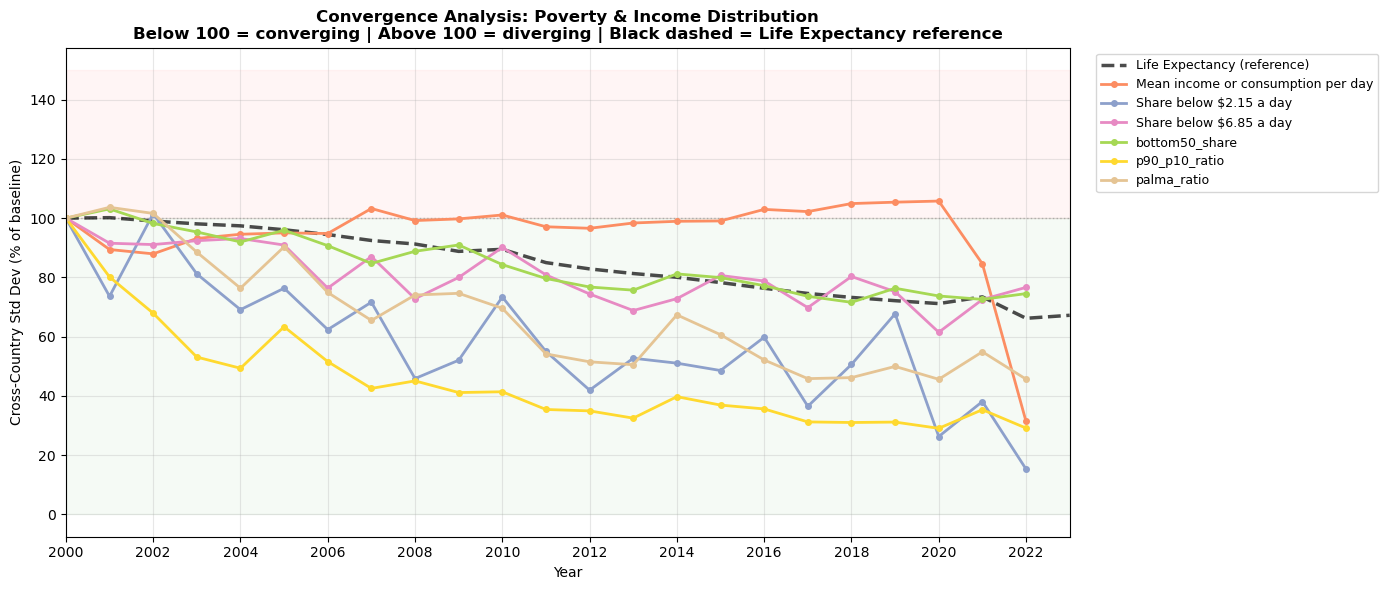

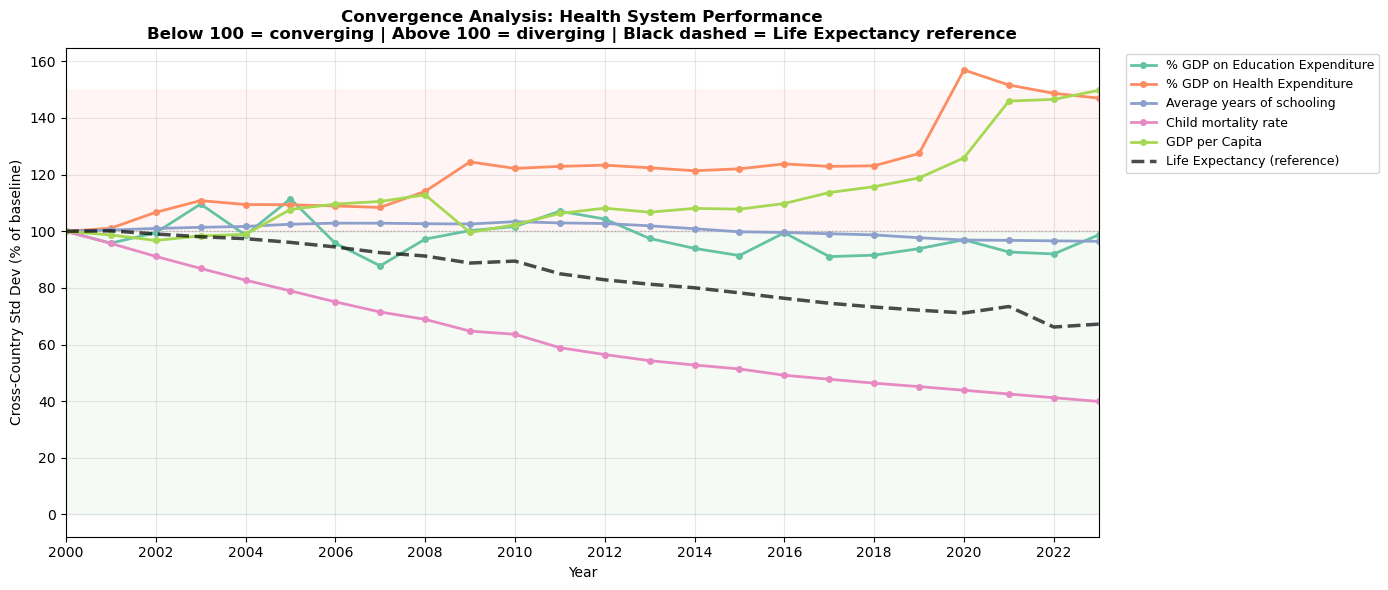

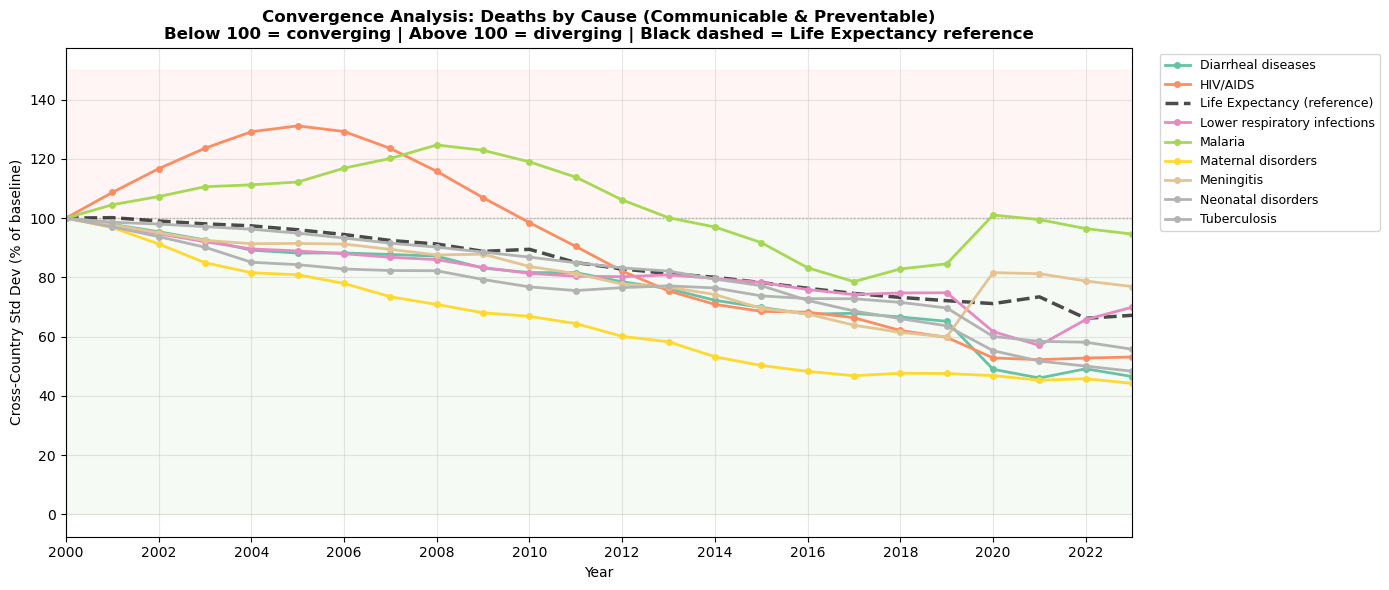

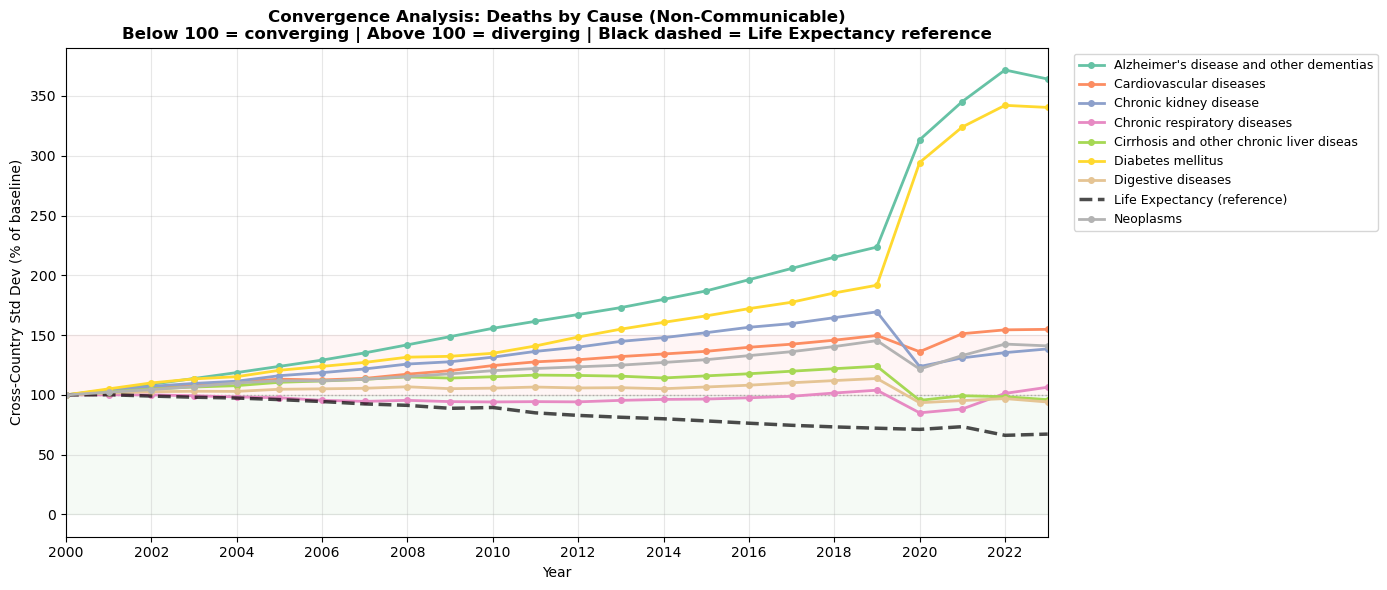

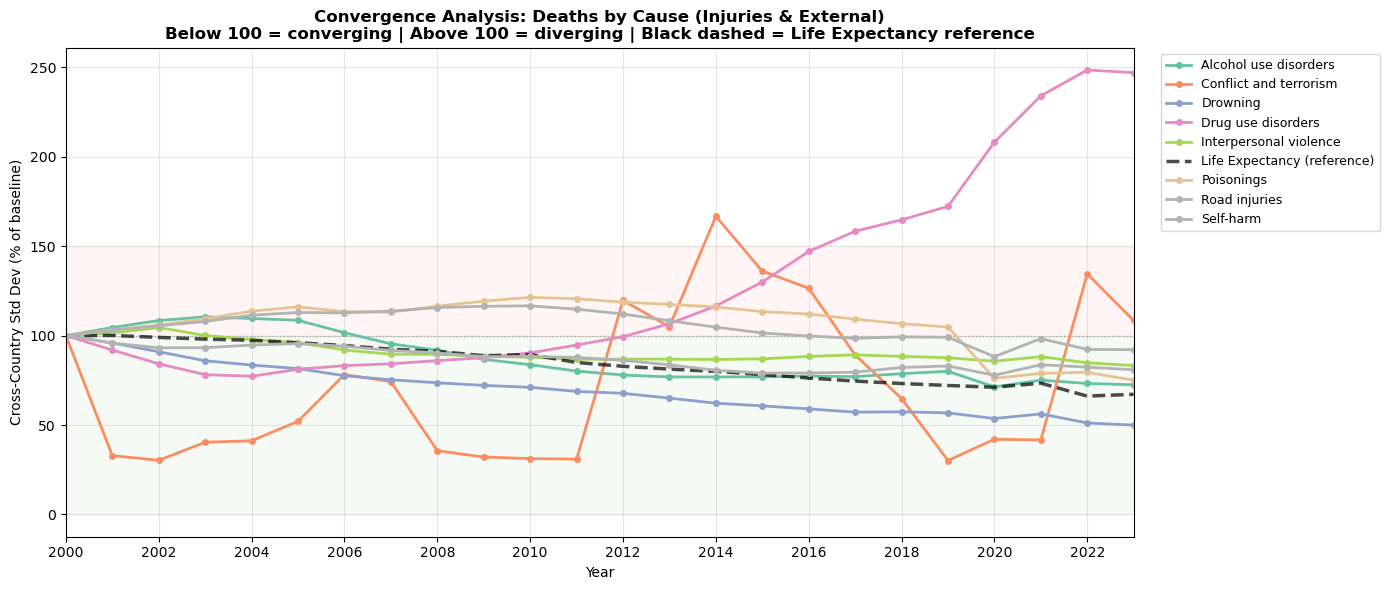

In [63]:
def compute_convergence(config_list, dict_data_agg):
    """Compute normalized SD over time at the COUNTRY level for a list of (dataset_key, col_name) tuples."""
    convergence_vars = []

    for dataset_key, col_name in config_list:
        if dataset_key not in dict_data_agg:
            continue

        df_ds = dict_data_agg[dataset_key].copy()

        if col_name not in df_ds.columns:
            num_cols = [c for c in df_ds.select_dtypes(include=[np.number]).columns if c != 'Year']
            if not num_cols:
                continue
            col_name = num_cols[0]

        yearly_sd = (
            df_ds
            .dropna(subset=[col_name])
            .groupby('Year')[col_name]
            .std()
            .reset_index()
        )
        yearly_sd.columns = ['Year', 'SD']
        yearly_sd['Variable'] = col_name
        convergence_vars.append(yearly_sd)

    if not convergence_vars:
        return None

    # Sort here so .iloc[0] is always the earliest year in plot_convergence
    return pd.concat(convergence_vars, ignore_index=True).sort_values(['Variable', 'Year'])


def plot_convergence(df_conv, title, backend="plotly"):
    """
    Plot convergence chart for a single category.

    Parameters
    ----------
    df_conv  : pd.DataFrame  output of compute_convergence()
    title    : str
    backend  : {"plotly", "matplotlib"}
              Note: colors represent variables, not continents — CONTINENT_COLORS does not apply here.
    """
    variables = df_conv['Variable'].unique()

    if backend == "plotly":
        colors = px.colors.qualitative.Set2
        fig = go.Figure()

        for i, var in enumerate(variables):
            data = df_conv[df_conv['Variable'] == var].copy()
            first_sd = data['SD'].iloc[0]   # safe: sorted by Year in compute_convergence
            if first_sd <= 0:
                continue
            data['SD_Normalized'] = (data['SD'] / first_sd) * 100

            if var == 'Life Expectancy':
                fig.add_trace(go.Scatter(
                    x=data['Year'], y=data['SD_Normalized'],
                    mode='lines',
                    name='Life Expectancy (reference)',
                    line=dict(color='black', width=3, dash='dash'),
                    opacity=0.7
                ))
            else:
                fig.add_trace(go.Scatter(
                    x=data['Year'], y=data['SD_Normalized'],
                    mode='lines+markers',
                    name=var[:40],
                    line=dict(color=colors[i % len(colors)], width=2.5),
                    marker=dict(size=5)
                ))

        fig.add_hline(y=100, line_dash='dot', line_color='gray', opacity=0.5,
                      annotation_text='Baseline (first year)', annotation_position='bottom right')
        fig.add_hrect(y0=0,   y1=100, fillcolor='green', opacity=0.04, line_width=0)
        fig.add_hrect(y0=100, y1=300, fillcolor='red',   opacity=0.04, line_width=0)

        fig.update_layout(
            title=dict(
                text=(f'Convergence Analysis: {title}<br>'
                      f'<sub>Below 100% = converging | Above 100% = diverging | '
                      f'Black dashed = Life Expectancy reference</sub>'),
                font=dict(size=15)
            ),
            xaxis=dict(title='Year', range=[year_min, year_max], gridcolor='lightgray'),
            yaxis=dict(title='Cross-Country Std Dev (% of baseline)', gridcolor='lightgray'),
            template='plotly_white',
            hovermode='x unified',
            legend=dict(x=1.02, y=1, xanchor='left', yanchor='top', font=dict(size=10)),
            height=550,
            width=1000,
        )
        fig.show()

    elif backend == "matplotlib":
        colors_list = plt.cm.Set2(np.linspace(0, 1, max(len(variables), 8)))
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.axhspan(0,   100, color='green', alpha=0.04)
        ax.axhspan(100, 150, color='red',   alpha=0.04)
        ax.axhline(y=100, color='gray', linestyle=':', linewidth=1, alpha=0.5)

        for i, var in enumerate(variables):
            data = df_conv[df_conv['Variable'] == var].copy()
            first_sd = data['SD'].iloc[0]   # safe: sorted by Year in compute_convergence
            if first_sd <= 0:
                continue
            data['SD_Normalized'] = (data['SD'] / first_sd) * 100

            if var == 'Life Expectancy':
                ax.plot(data['Year'], data['SD_Normalized'],
                        color='black', linewidth=2.5, linestyle='--', alpha=0.7,
                        label='Life Expectancy (reference)')
            else:
                ax.plot(data['Year'], data['SD_Normalized'],
                        color=colors_list[i % len(colors_list)], linewidth=2,
                        marker='o', markersize=4, label=var[:40])

        ax.set_title(f'Convergence Analysis: {title}\n'
                     f'Below 100 = converging | Above 100 = diverging | Black dashed = Life Expectancy reference',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Year')
        ax.set_ylabel('Cross-Country Std Dev (% of baseline)')
        ax.set_xticks(range(year_min, year_max + 1, 2))
        ax.set_xlim(year_min, year_max)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")


# Usage
for category_name, config_list in convergence_categories.items():
    df_conv = compute_convergence(config_list, dict_data_agg)
    if df_conv is not None and len(df_conv) > 0:
        plot_convergence(df_conv, category_name, backend="matplotlib")
    else:
        print(f"⚠️ No data for category: {category_name}")


In [64]:
pairwise_categories = {
    'Life Expectancy & Vaccination': [
        ('life_expectancy', 'Life Expectancy'),
        ('global_vaccination_coverage', 'DTP3'),
        ('global_vaccination_coverage', 'MCV1'),
        ('global_vaccination_coverage', 'Pol3'),
        ('global_vaccination_coverage', 'BCG'),
        ('global_vaccination_coverage', 'PCV3'),
        ('global_vaccination_coverage', 'RotaC'),
    ],
    'Demographic & Social': [
        ('life_expectancy', 'Life Expectancy'),
        ('child-mortality', 'Child mortality rate'),
        ('average-years-of-schooling-among-adults', 'Average years of schooling'),
        ('death_rate_from_suicides_gho', 'Suicide Rate'),
        ('homicide_rate_unodc', 'Homicide Rate'),
    ],
    'Economic & Inequality': [
        ('life_expectancy', 'Life Expectancy'),
        ('gdp_per_capita_penn_world_table', 'GDP per Capita'),
        ('public_healthcare_spending_share_gdp', '% GDP on Health Expenditure'),
        ('education_spending_share_gdp', '% GDP on Education Expenditure'),
        ('poverty_explorer', 'gini'),
        ('poverty_explorer', 'palma_ratio'),
    ],
    'Poverty & Income': [
        ('life_expectancy', 'Life Expectancy'),
        ('poverty_explorer', 'Share below $2.15 a day'),
        ('poverty_explorer', 'Share below $6.85 a day'),
        ('poverty_explorer', 'Mean income or consumption per day'),
        ('poverty_explorer', 'bottom50_share'),
        ('poverty_explorer', 'decile10_share'),
    ],
    'Health System Performance': [
        ('life_expectancy', 'Life Expectancy'),
        ('public_healthcare_spending_share_gdp', '% GDP on Health Expenditure'),
        ('gdp_per_capita_penn_world_table', 'GDP per Capita'),
        ('child-mortality', 'Child mortality rate'),
        ('average-years-of-schooling-among-adults', 'Average years of schooling'),
        ('education_spending_share_gdp', '% GDP on Education Expenditure'),
    ],
    'Deaths: Communicable': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'HIV/AIDS'),
        ('annual_number_of_deaths_by_cause', 'Tuberculosis'),
        ('annual_number_of_deaths_by_cause', 'Malaria'),
        ('annual_number_of_deaths_by_cause', 'Diarrheal diseases'),
        ('annual_number_of_deaths_by_cause', 'Lower respiratory infections'),
        ('annual_number_of_deaths_by_cause', 'Neonatal disorders'),
    ],
    'Deaths: Non-Communicable': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'Cardiovascular diseases'),
        ('annual_number_of_deaths_by_cause', 'Neoplasms'),
        ('annual_number_of_deaths_by_cause', 'Diabetes mellitus'),
        ('annual_number_of_deaths_by_cause', 'Chronic respiratory diseases'),
        ('annual_number_of_deaths_by_cause', 'Alzheimer\'s disease and other dementias'),
    ],
    'Deaths: Injuries & External': [
        ('life_expectancy', 'Life Expectancy'),
        ('annual_number_of_deaths_by_cause', 'Conflict and terrorism'),
        ('annual_number_of_deaths_by_cause', 'Road injuries'),
        ('annual_number_of_deaths_by_cause', 'Self-harm'),
        ('annual_number_of_deaths_by_cause', 'Interpersonal violence'),
        ('annual_number_of_deaths_by_cause', 'Drug use disorders'),
    ],
}

recent_years = range(year_max - 2, year_max + 1)


📊 Life Expectancy & Vaccination
  Countries: 129 | Variables: 7


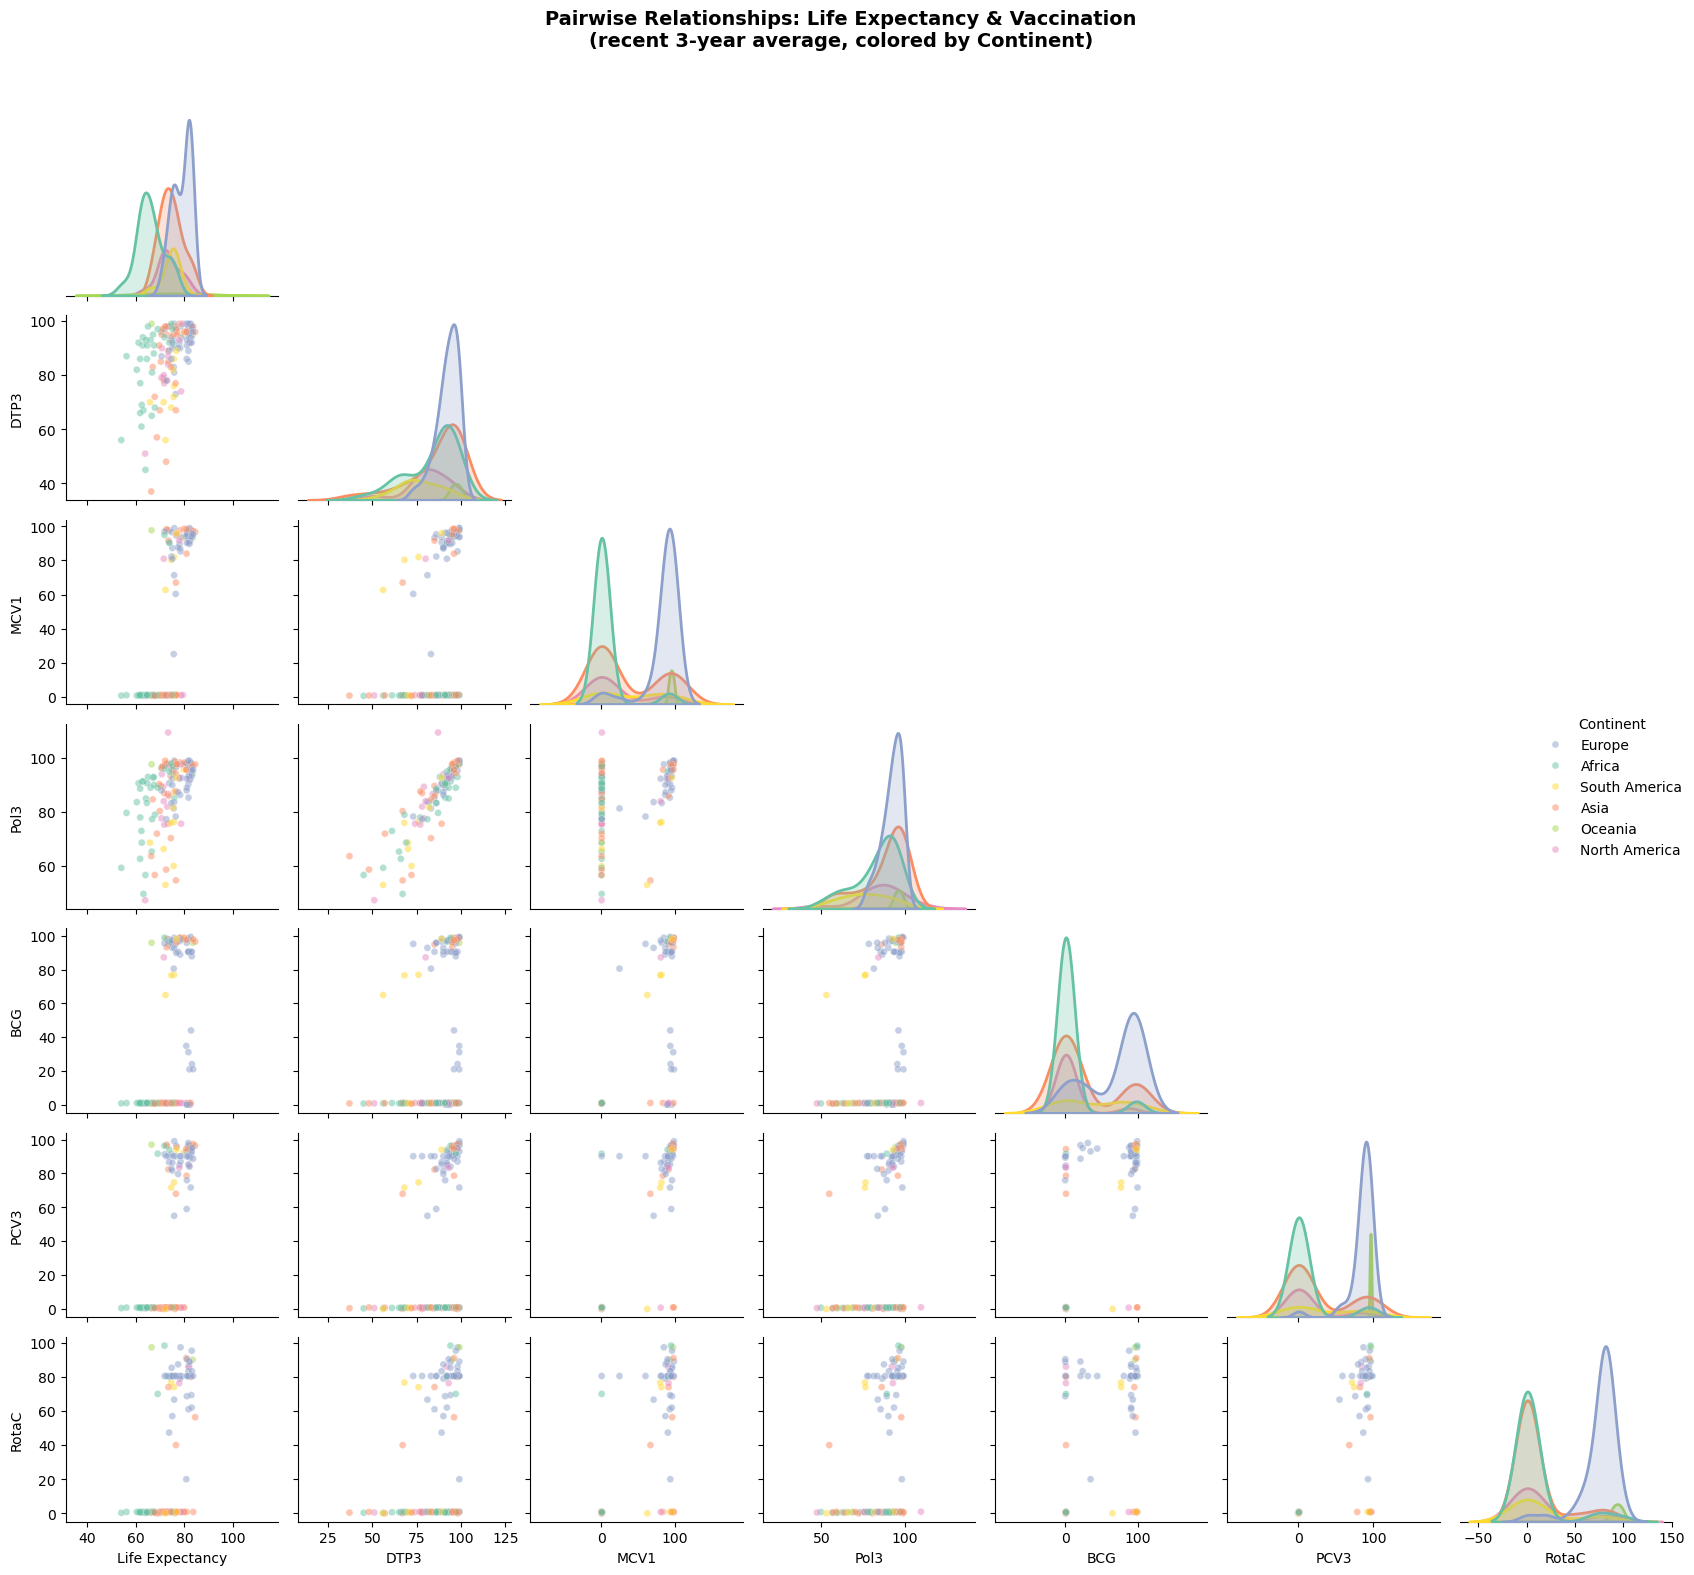

  ✅ 7 variables, 21 pairs plotted

📊 Demographic & Social
  Countries: 129 | Variables: 5


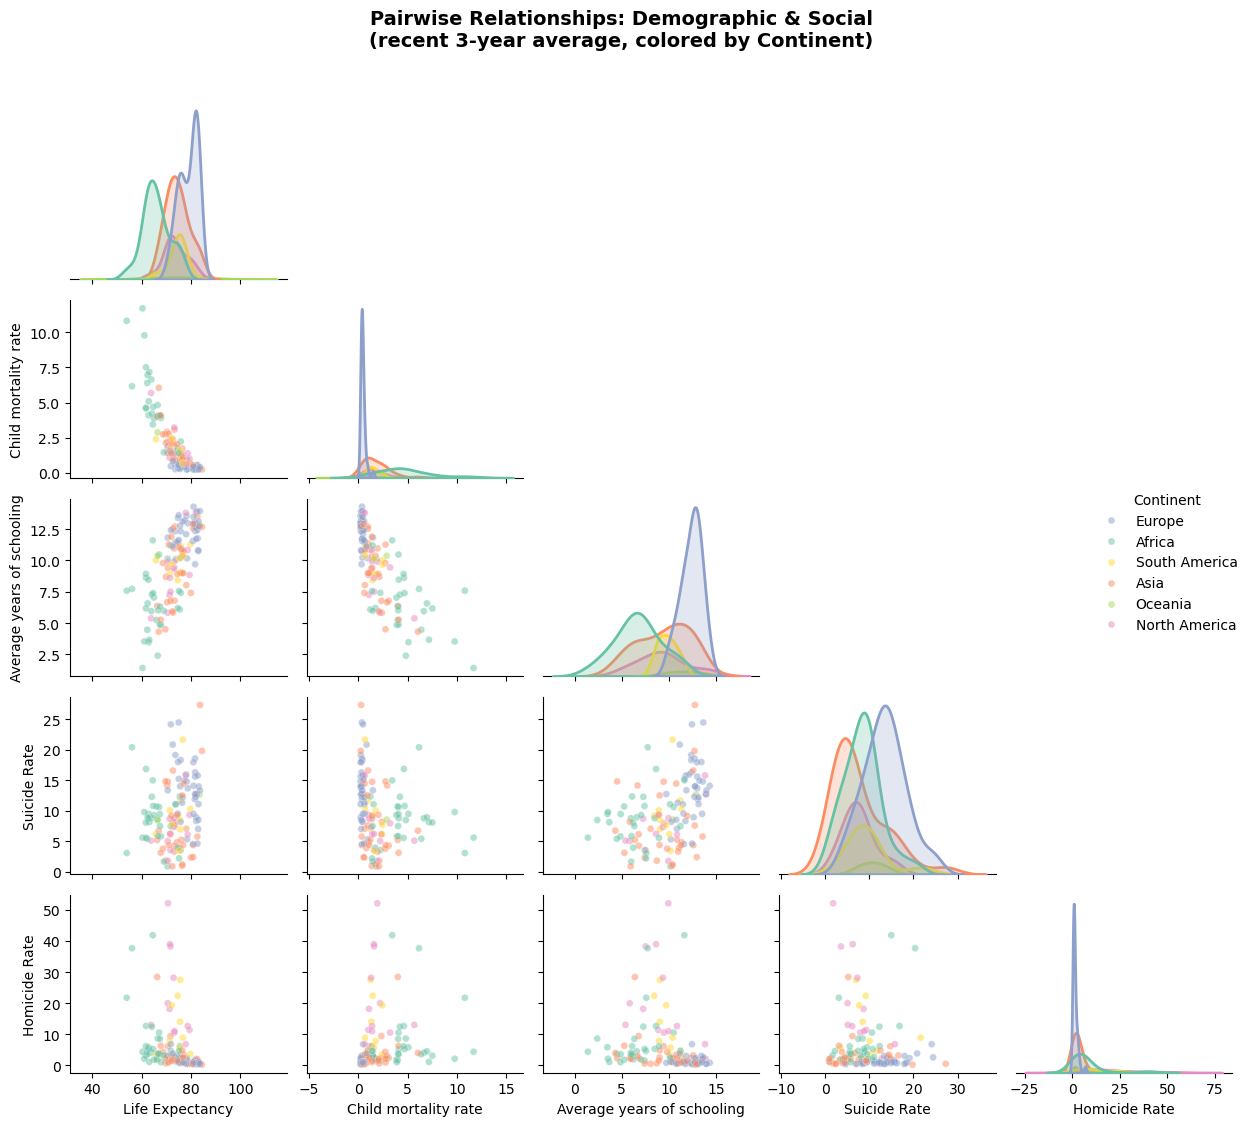

  ✅ 5 variables, 10 pairs plotted

📊 Economic & Inequality
  Countries: 119 | Variables: 6


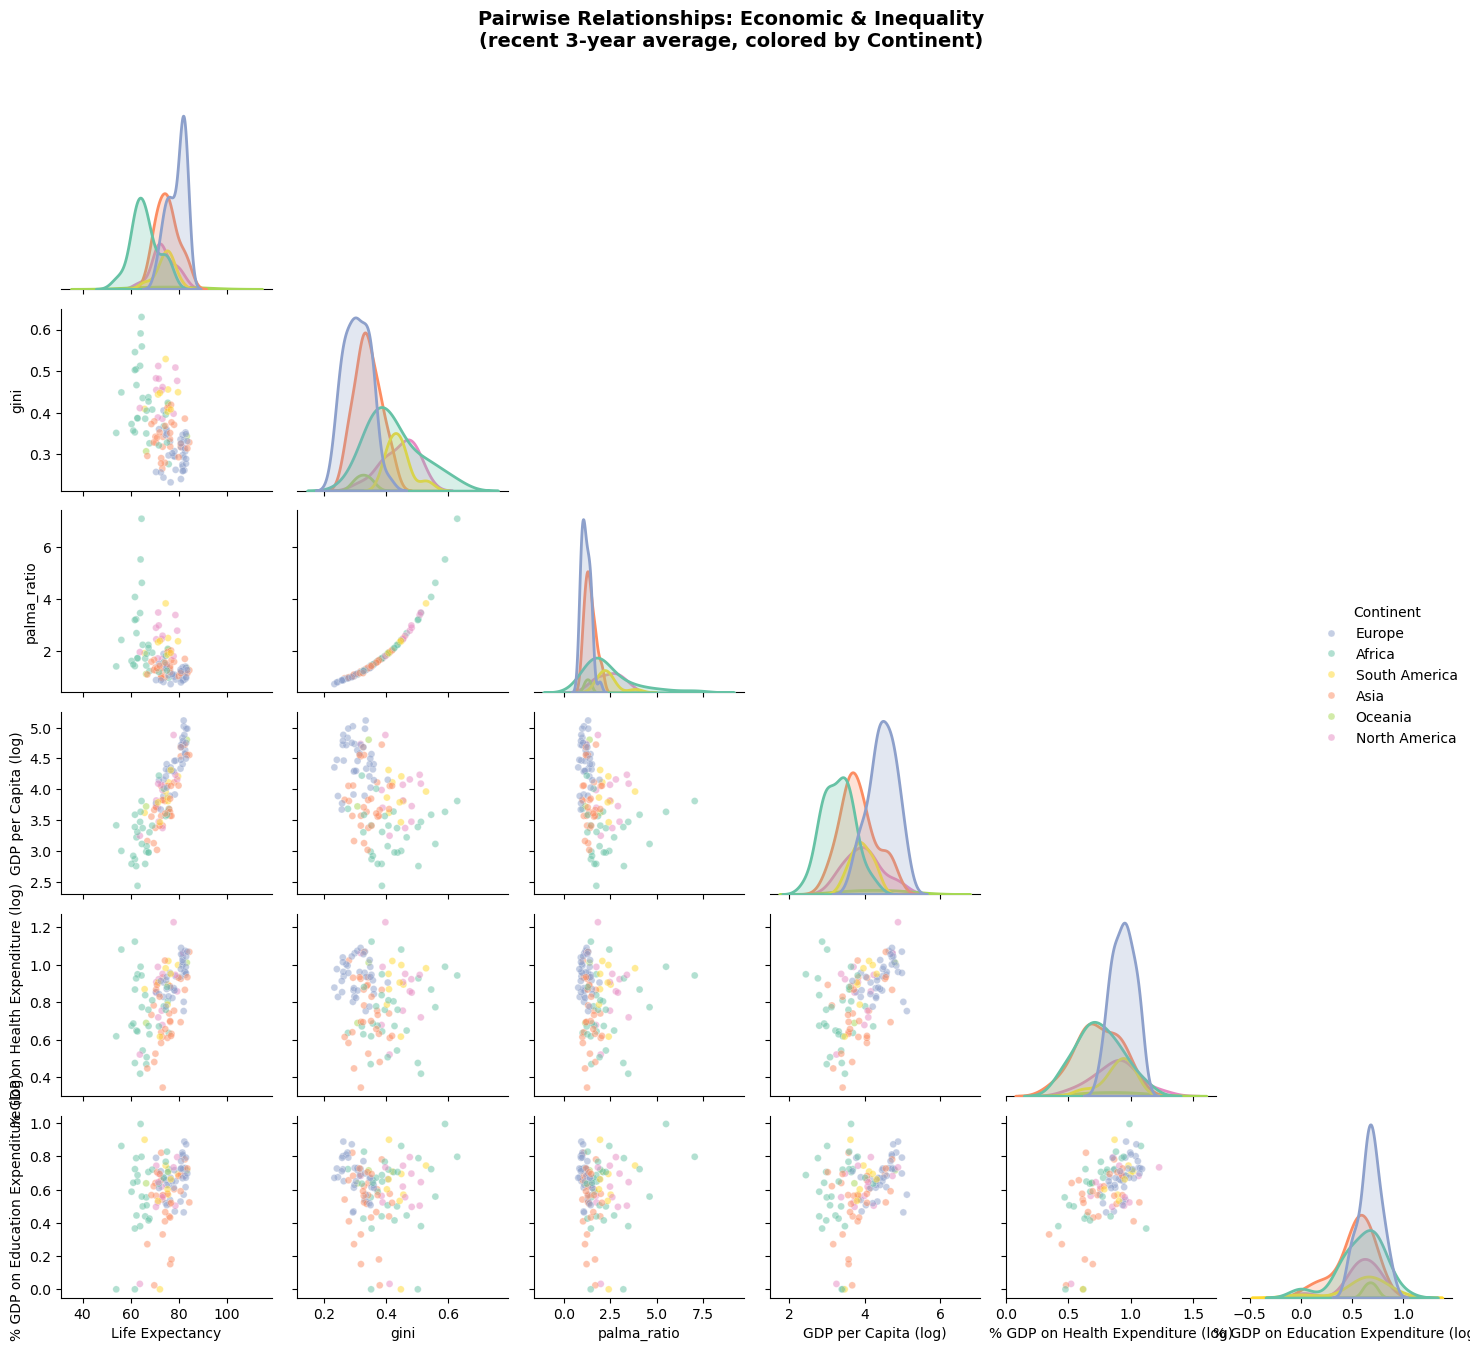

  ✅ 6 variables, 15 pairs plotted

📊 Poverty & Income
  Countries: 129 | Variables: 6


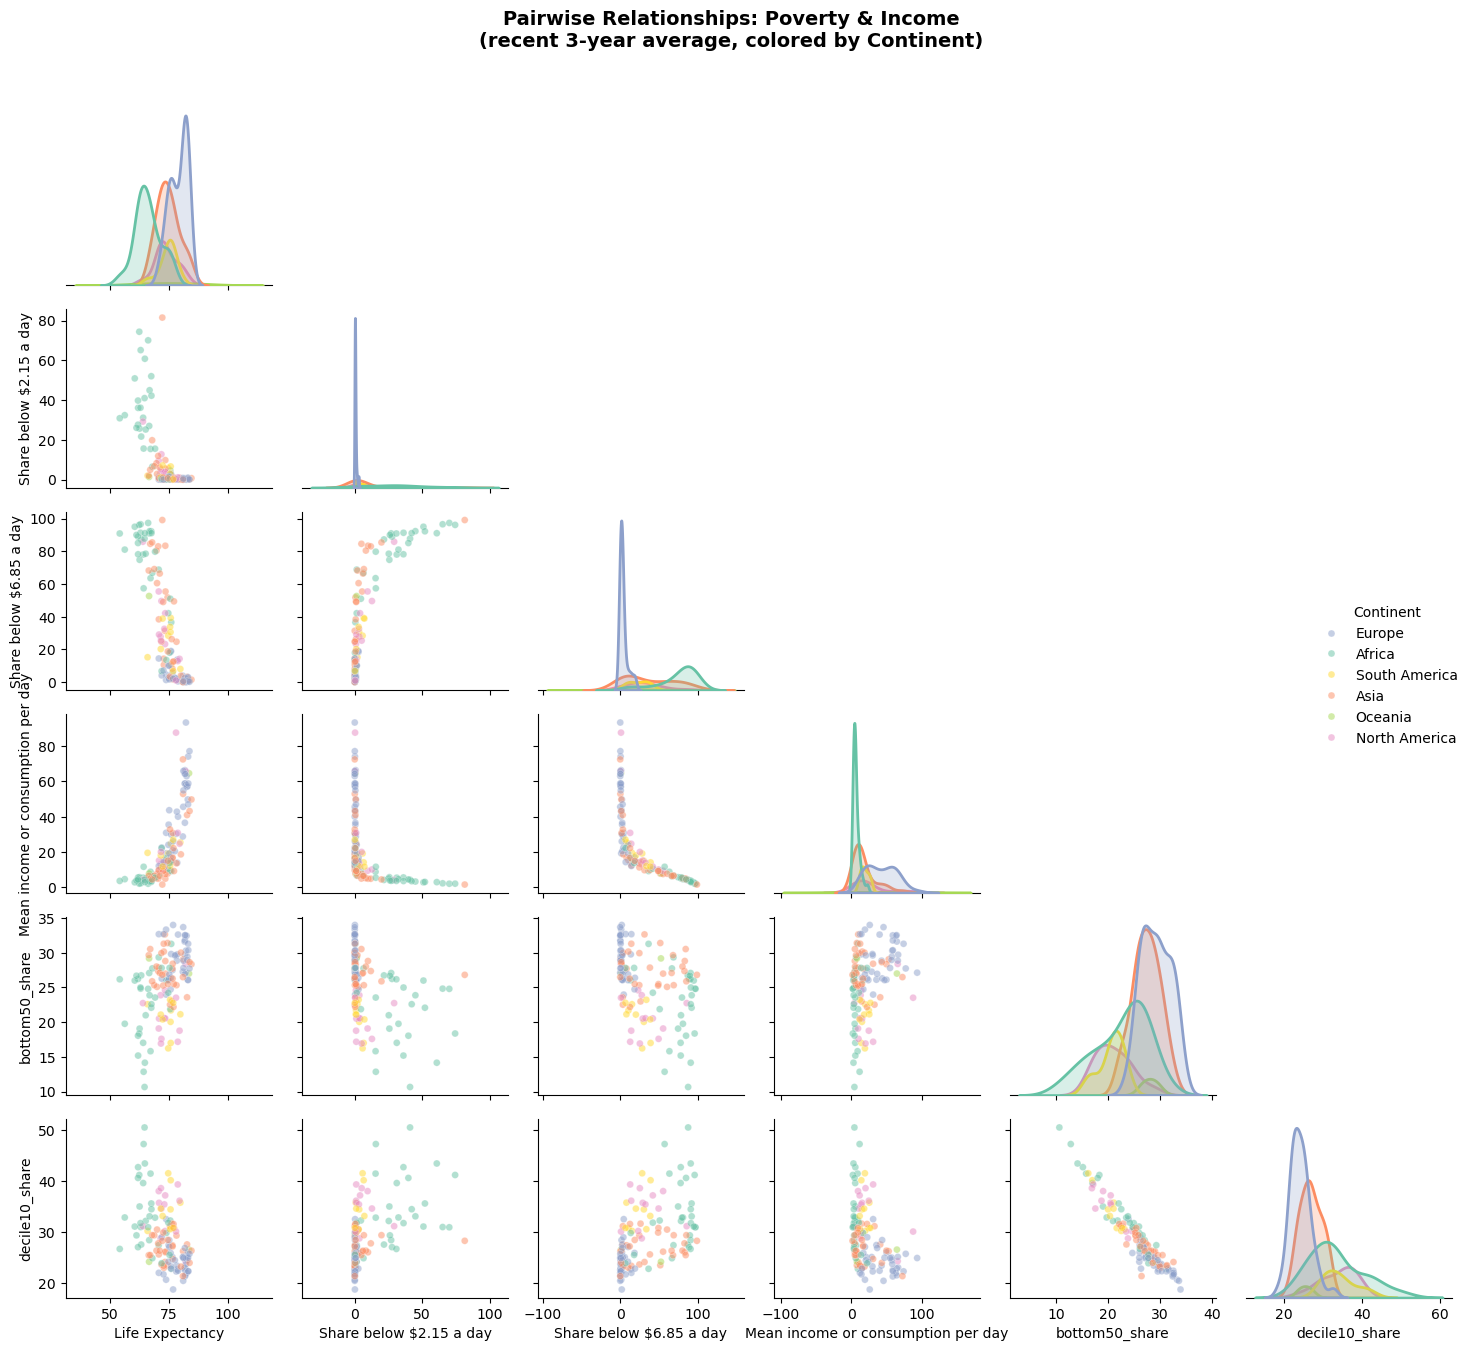

  ✅ 6 variables, 15 pairs plotted

📊 Health System Performance
  Countries: 119 | Variables: 6


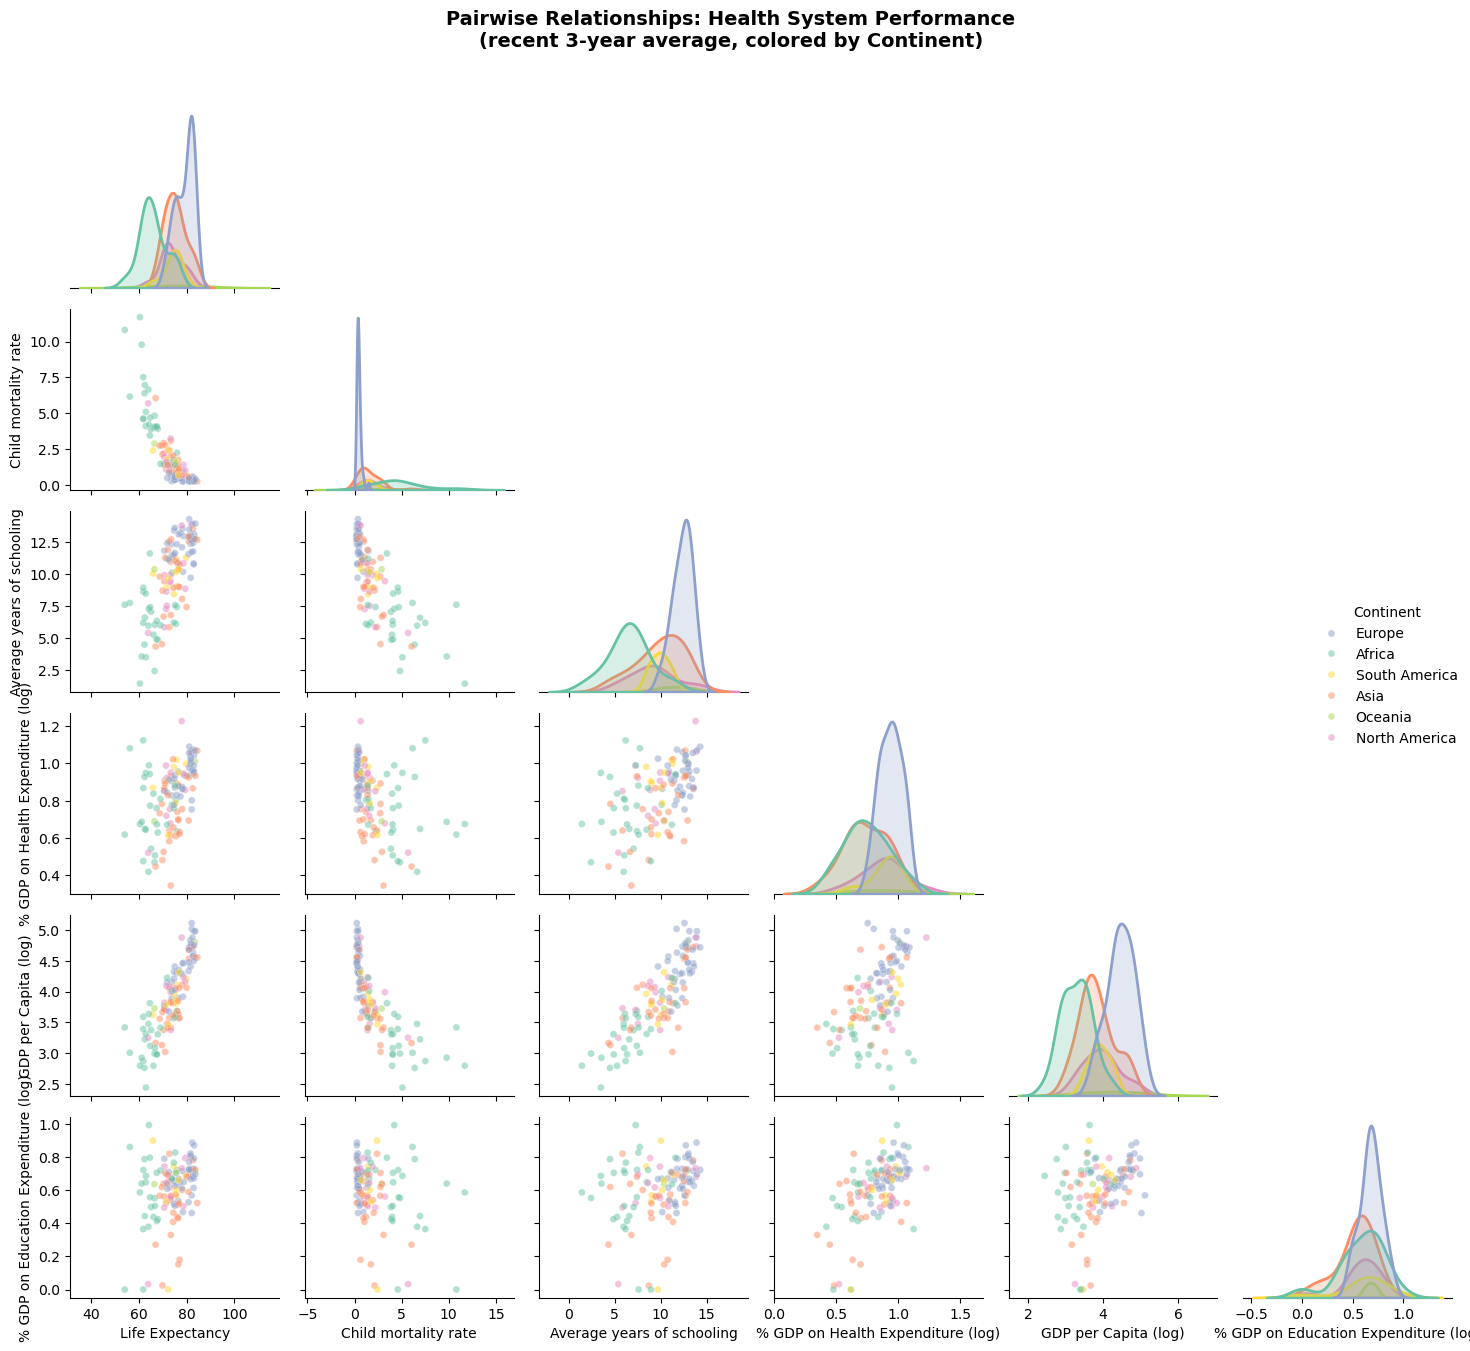

  ✅ 6 variables, 15 pairs plotted

📊 Deaths: Communicable
  Countries: 129 | Variables: 7


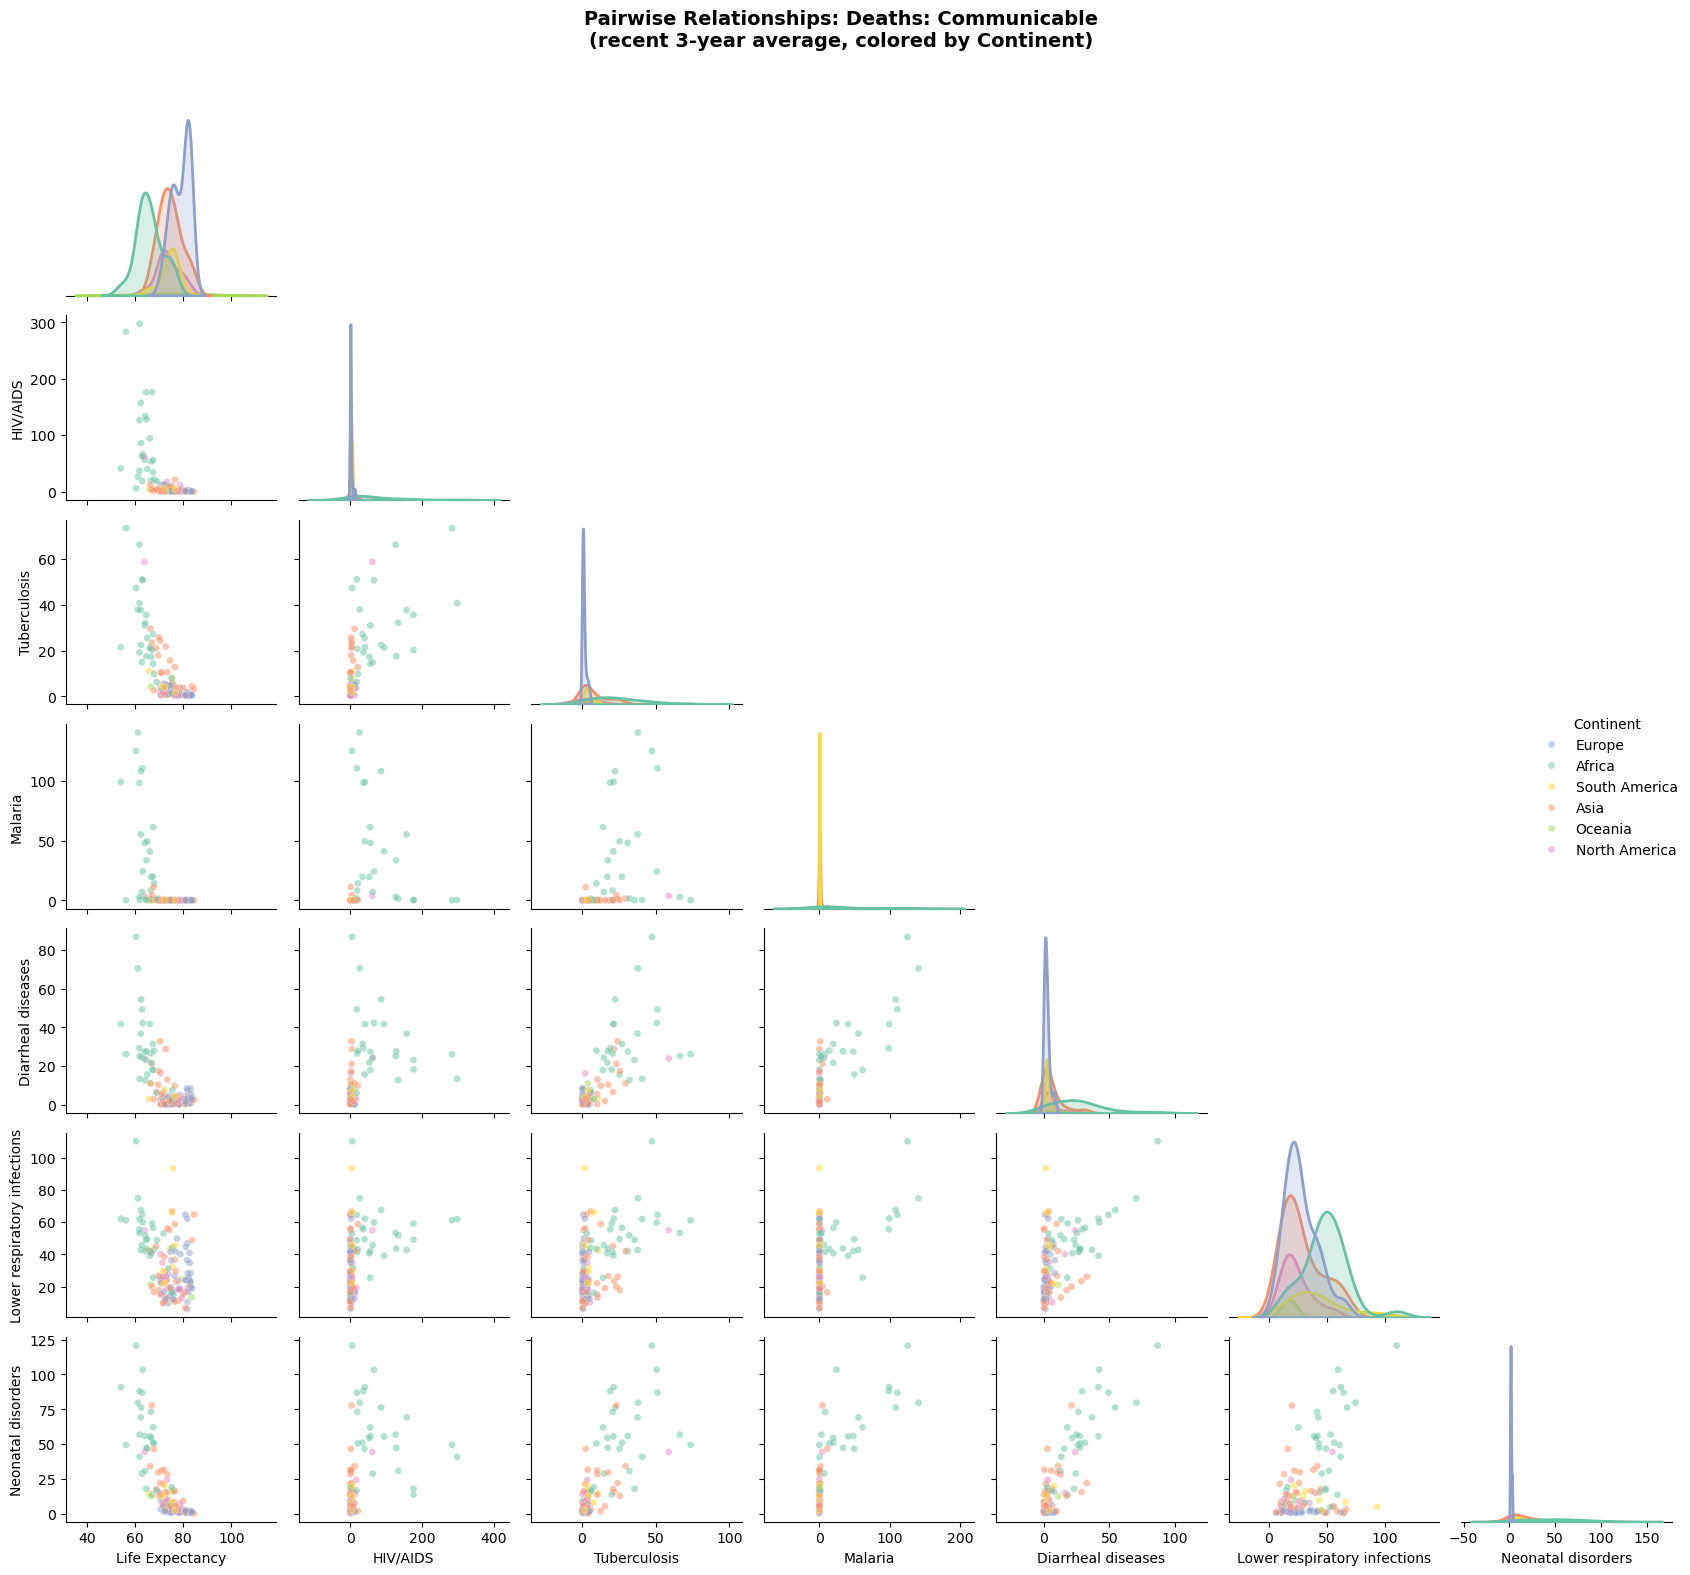

  ✅ 7 variables, 21 pairs plotted

📊 Deaths: Non-Communicable
  Countries: 129 | Variables: 6


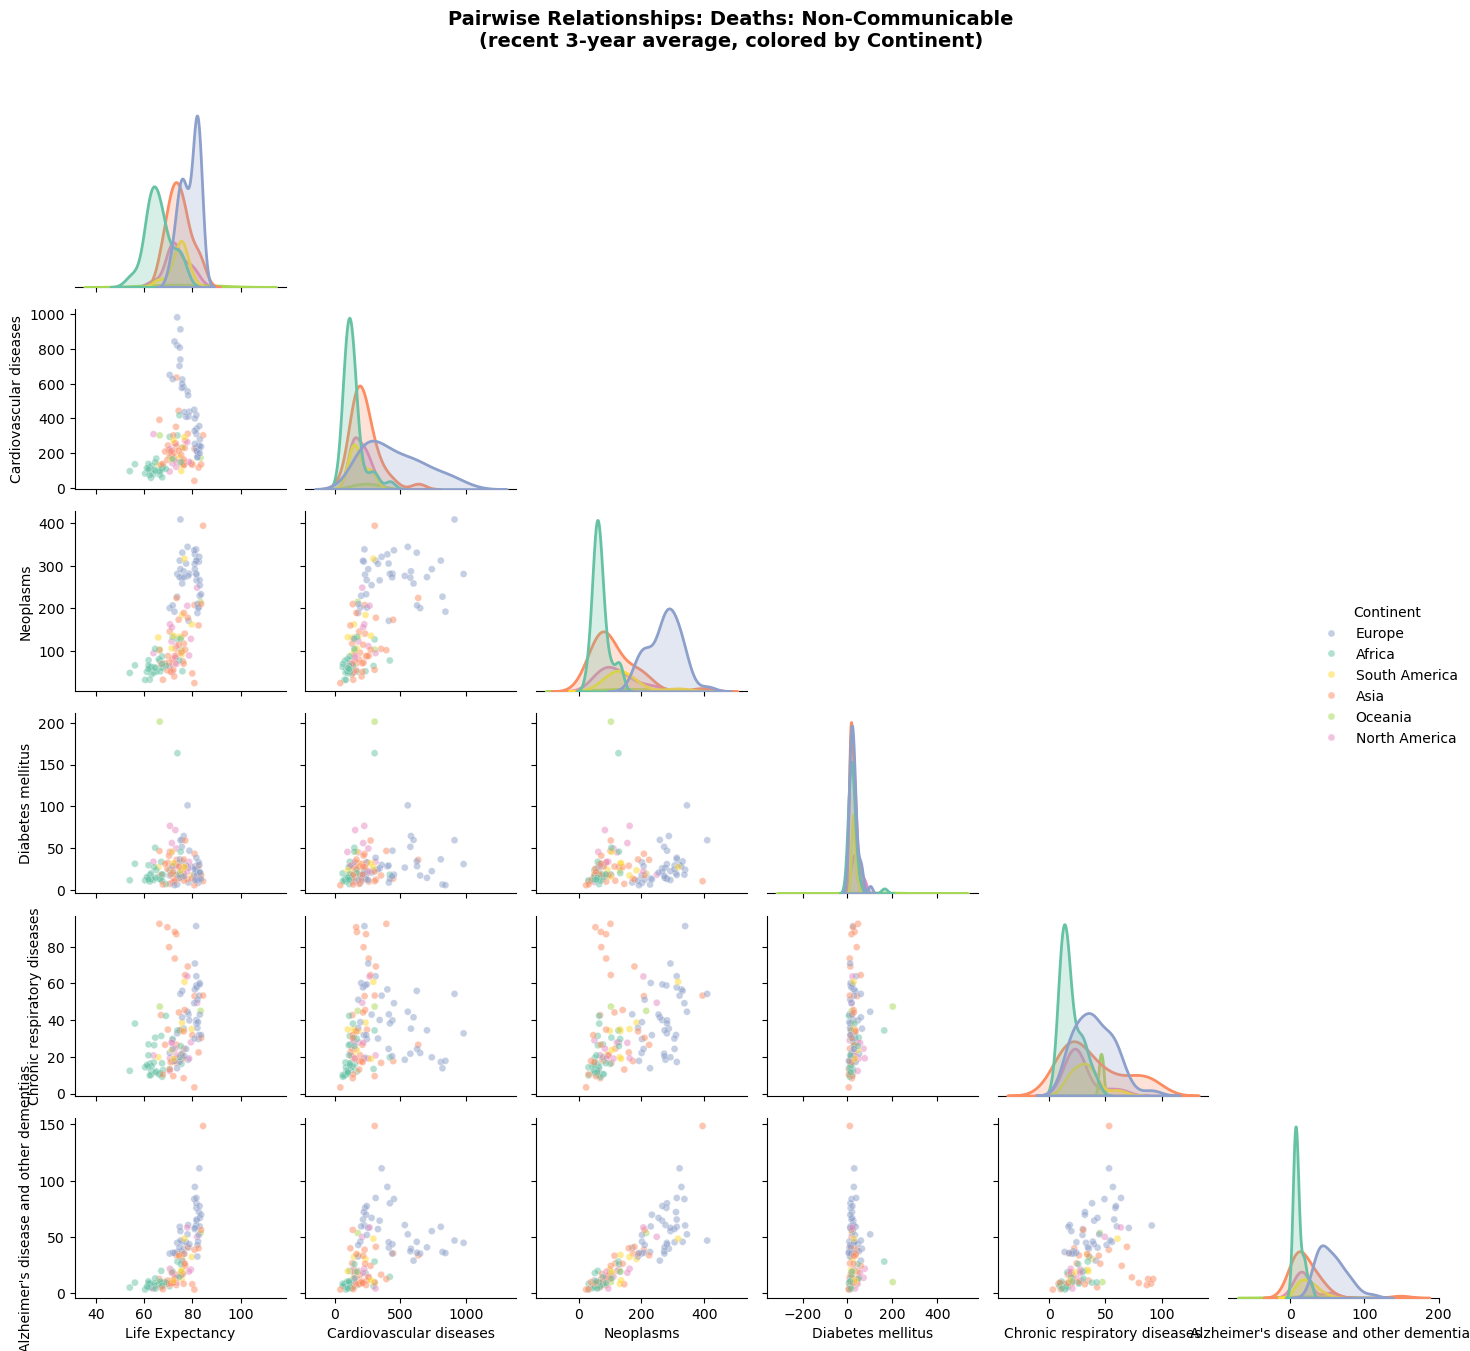

  ✅ 6 variables, 15 pairs plotted

📊 Deaths: Injuries & External
  Countries: 129 | Variables: 6


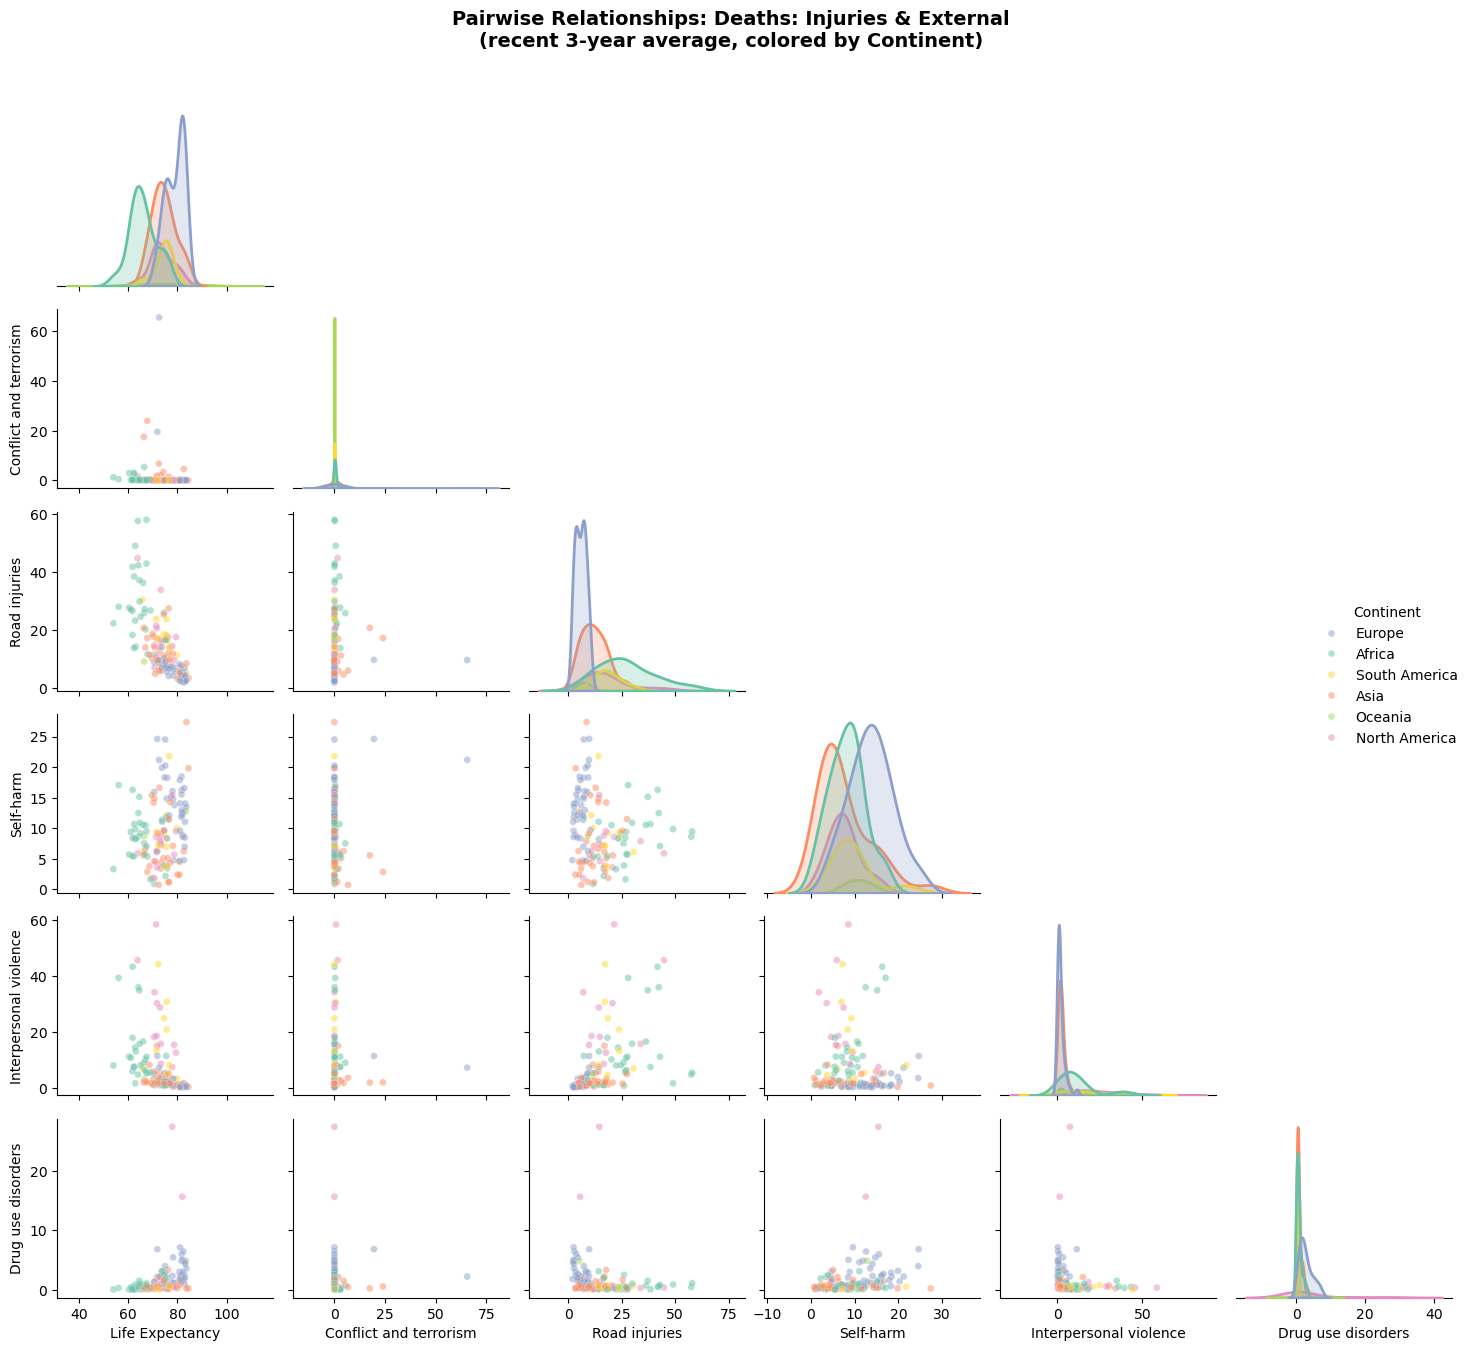

  ✅ 6 variables, 15 pairs plotted


In [65]:
def build_scatter_df(config_list, df_imputed, recent_years):
    """
    Build a wide DataFrame with one column per variable in config_list,
    averaged over recent_years, drawn from the already-merged dataset.

    Parameters
    ----------
    config_list  : list of (dataset_key, col_name) tuples
                   dataset_key is ignored — all columns come from df_merged
    df_imputed    : pd.DataFrame   the fully merged/imputed dataset
    recent_years : range or list of years to average over
    """
    scatter_df = None

    for _, col_name in config_list:
        if col_name not in df_imputed.columns:
            print(f"  ⚠️ Column '{col_name}' not found in df_merged, skipping.")
            continue

        df_avg = (df_imputed[df_imputed['Year'].isin(recent_years)]
                  .groupby(['Country', 'Continent'])[col_name].mean().reset_index())

        if df_avg[col_name].notna().sum() < 10:
            print(f"  ⚠️ '{col_name}' sparse in recent years — using latest available")
            df_avg = (df_imputed.dropna(subset=[col_name])
                               .sort_values('Year')
                               .groupby(['Country', 'Continent'])[col_name].last().reset_index())

        if scatter_df is None:
            scatter_df = df_avg
        else:
            scatter_df = scatter_df.merge(df_avg[['Country', col_name]], on='Country', how='outer')

    return scatter_df


def plot_pairwise_scatter(pairwise_categories, df_imputed, recent_years, backend="plotly"):
    """
    Parameters
    ----------
    pairwise_categories : dict    {category_name: [(dataset_key, col_name), ...]}
    df_imputed          : pd.DataFrame   the fully merged/imputed dataset
    recent_years        : range or list
    backend             : {"plotly", "matplotlib"}
    """
    for category_name, config_list in pairwise_categories.items():
        print(f"\n{'='*80}")
        print(f"📊 {category_name}")
        print(f"{'='*80}")

        scatter_df = build_scatter_df(config_list, df_imputed, recent_years)
        if scatter_df is None:
            print("  ⚠️ No data available for this category.")
            continue

        # Log-transform any GDP columns
        gdp_cols = [c for c in scatter_df.columns if 'GDP' in c]
        for gc in gdp_cols:
            scatter_df[f'{gc} (log)'] = np.log10(scatter_df[gc].clip(lower=1))
            scatter_df = scatter_df.drop(columns=[gc])

        scatter_cols = [c for c in scatter_df.columns if c not in ['Country', 'Continent']]
        df_plot      = scatter_df.dropna(subset=scatter_cols)

        print(f"  Countries: {len(df_plot)} | Variables: {len(scatter_cols)}")
        if len(df_plot) < 5:
            print("  ⚠️ Too few countries with complete data, skipping.")
            continue

        if backend == "matplotlib":
            g = sns.pairplot(
                df_plot,
                vars=scatter_cols,
                hue='Continent',
                palette=CONTINENT_COLORS,
                diag_kind='kde',
                plot_kws={'alpha': 0.5, 's': 25, 'edgecolor': 'white', 'linewidth': 0.3},
                diag_kws={'linewidth': 2},
                height=2.2,
                corner=True
            )
            g.figure.suptitle(
                f'Pairwise Relationships: {category_name}\n(recent 3-year average, colored by Continent)',
                fontsize=14, fontweight='bold', y=1.02
            )
            plt.tight_layout()
            plt.show()

        elif backend == "plotly":
            fig = px.scatter_matrix(
                df_plot,
                dimensions=scatter_cols,
                color='Continent',
                color_discrete_map=CONTINENT_COLORS,
                hover_data=['Country'],
                title=f'Pairwise Relationships: {category_name}<br>'
                      f'<sub>Recent 3-year average, colored by Continent</sub>',
                opacity=0.6,
            )
            fig.update_traces(
                diagonal_visible=False,
                showupperhalf=False,
                marker=dict(size=5, line=dict(width=0.3, color='white'))
            )
            fig.update_layout(
                height=200 * len(scatter_cols),
                template='plotly_white',
            )
            fig.show()

        else:
            raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")

        print(f"  ✅ {len(scatter_cols)} variables, "
              f"{len(scatter_cols) * (len(scatter_cols) - 1) // 2} pairs plotted")


# Usage
#plot_pairwise_scatter(pairwise_categories, df_imputed, recent_years, backend="plotly")
plot_pairwise_scatter(pairwise_categories, df_imputed, recent_years, backend="matplotlib")



In [66]:
# Check missing values in the profile dataset
missing_pct = (df_imputed.isnull().sum() / len(df_imputed) * 100).sort_values(ascending=False)
print("Missing % per column (top 30):")
print(missing_pct.head(30).to_string())

Missing % per column (top 30):
% GDP on Education Expenditure          26.970284
DTP1                                     1.550388
Country                                  0.000000
Life Expectancy                          0.000000
GDP per Capita                           0.000000
BCG                                      0.000000
DTP3                                     0.000000
HepB3                                    0.000000
Hib3                                     0.000000
MCV1                                     0.000000
MCV2                                     0.000000
PCV3                                     0.000000
Pol3                                     0.000000
RCV1                                     0.000000
RotaC                                    0.000000
Homicide Rate                            0.000000
Population                               0.000000
Child mortality rate                     0.000000
Share below $2.15 a day                  0.000000
Share below $3.65 a